# BRCA1 ClinProtGym ESM-C SAE downstream analysis

This notebook is for the `MV_BRCA1_Findlay_2018` rerun using the pooled/synonymous-corrected data and sequence-deduplicated SAE training. It keeps job submission, label swapping, AUC refreshes, LLR baseline generation, benchmark comparisons, gamma=1 SAE ensemble collection, and plotting in one place.

The job-submission cells default to dry-run-style behavior. Flip the `SUBMIT_*` or `RUN_*` switches in the setup cell before running them.

In [1]:
from pathlib import Path

In [ ]:
import json
import os
import pickle
import subprocess
import sys
import time

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "esmDMS.py").exists():
    for parent in Path.cwd().parents:
        if (parent / "esmDMS.py").exists():
            REPO_ROOT = parent
            break
sys.path.insert(0, str(REPO_ROOT))

os.environ.setdefault("MPLBACKEND", "Agg")
os.environ.setdefault("MPLCONFIGDIR", str(REPO_ROOT / ".matplotlib_cache"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
from IPython.display import Markdown, display

def ensure_plotting():
    import matplotlib.pyplot as plt
    import seaborn as sns
    sns.set_theme(style="whitegrid", context="notebook")
    return plt, sns

PYTHON = str(Path(sys.executable).resolve())
PIPELINE = REPO_ROOT / "scripts" / "clinprotgym_esmc_sae_pipeline.py"
REFRESH_AUC = REPO_ROOT / "scripts" / "refresh_clinprotgym_clinvar_auc.py"
OUTPUT_ROOT = REPO_ROOT / "data" / "clinprotgym_esmc_sae"
DATASET = "MV_BRCA1_Findlay_2018"
RUN_LABEL = "DeltaEmbSAE_max_pool_batchtopk_k64_nf12800_seed42_seqdedup_v2"
DATASET_ROOT = OUTPUT_ROOT / "datasets" / DATASET
TABLE_DIR = DATASET_ROOT / "tables"
JOB_DIR = DATASET_ROOT / "jobs"
FIGURE_DIR = DATASET_ROOT / "figures" / "brca1_sae_downstream"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# Label controls. Use "pipeline" for the labels in the prepared dataset state,
# "hgvs" for exact-HGVS labels via refresh_clinprotgym_clinvar_auc.py outputs,
# or "custom_csv" for a CSV with SequenceIndex, annotation, and optional stars columns.
CLINICAL_LABEL_MODE = "pipeline"  # "pipeline", "hgvs", or "custom_csv"
CUSTOM_CLINICAL_LABELS_CSV = None
ANNOTATION_SCHEME_FOR_REFRESH = "auto"  # "auto", "hgvs", or "protein"
FORCE_REBUILD_HGVS_CACHE = False

# Job controls. Keep submit/run switches False until you actually want to launch work.
SUBMIT_LLR_JOBS = False
RUN_LLR_LOCALLY = False
SUBMIT_BENCHMARK_JOBS = False
SUBMIT_ENSEMBLE_JOBS = False
RUN_COLLECT_SAE = False
RUN_COLLECT_BENCHMARKS = False
RUN_COLLECT_ENSEMBLES = False
RUN_REFRESH_AUC = False
RUN_SUMMARIZE = True

LLR_MEM = "64G"
LLR_TIME = "12:00:00"
LLR_MAX_ACTIVE = 2
BENCHMARK_MEM = "24G"
BENCHMARK_TIME = "00:30:00"
BENCHMARK_MAX_ACTIVE = 12
BENCHMARK_FORCE_RECOMPUTE = False
ENSEMBLE_MEM = "96G"
ENSEMBLE_TIME = "18:00:00"
ENSEMBLE_TOP_N = 12
ENSEMBLE_GAMMA = 1.0

REVIEW_STAR_CUTOFFS = [0, 1, 2, 3, 4]
DOWNSTREAM_PATCH_VERSION = "review-star-label-fix-v5-llr-prior-popdms"
PATHOGENICITY_LABELS = {"benign", "pathogenic"}
METHOD_ORDER = [
    "Enrichment ratio baseline",
    "popDMS baseline",
    "LLR baseline",
    "Raw embeddings",
    "Raw SAE",
    "Ensemble SAE model",
]
REFERENCE_METHODS = ["DMS functional score"]
METHOD_LABELS = {
    "DMS functional score": "DMS score",
    "Enrichment ratio baseline": "Enrichment ratio",
    "popDMS baseline": "popDMS",
    "LLR baseline": "LLR",
    "Raw embeddings": "Raw ESM-C",
    "Raw SAE": "DeltaEmbSAE single layer",
    "Ensemble SAE model": "DeltaEmbSAE ensemble",
}

def sh(cmd, *, run=True, check=True, capture=False):
    cmd = [str(x) for x in cmd]
    print(" ".join(cmd))
    if not run:
        return None
    completed = subprocess.run(cmd, check=check, text=True, capture_output=capture)
    if capture and completed.stdout:
        print(completed.stdout)
    if capture and completed.stderr:
        print(completed.stderr)
    return completed

def read_csv(path, **kwargs):
    path = Path(path)
    return pd.read_csv(path, **kwargs) if path.is_file() else pd.DataFrame()

def safe_numeric(series):
    return pd.to_numeric(series, errors="coerce")

def clean_annotation_series(series):
    return series.astype(str).str.lower().replace({"nan": np.nan, "none": np.nan, "": np.nan})

def coalesce_first_present(df, candidate_columns, default=np.nan):
    # Seed with NaN, not `default`: combine_first only fills nulls, so a non-null default
    # (e.g. stars=0) would win over every real value and silently zero the column.
    out = pd.Series(np.nan, index=df.index, dtype=object)
    for column in candidate_columns:
        if column in df.columns:
            values = df[column]
            if isinstance(values, pd.DataFrame):
                values = values.iloc[:, 0]
            out = out.combine_first(values)
    return out.fillna(default)

def normalize_label_columns(df):
    df = df.copy()
    annotation_candidates = [
        "annotation_label", "annotation_active_label", "annotation_y",
        "clinvar_annotation", "annotation", "annotation_x", "annotation_fitness",
    ]
    star_candidates = [
        "stars_label", "stars_active_label", "stars_y", "clinvar_review_stars",
        "review_stars", "stars", "stars_x", "stars_fitness",
    ]
    df["annotation"] = clean_annotation_series(coalesce_first_present(df, annotation_candidates))
    df["stars"] = safe_numeric(coalesce_first_present(df, star_candidates, default=0)).fillna(0).astype(int)
    return df

print(f"Notebook patch: {DOWNSTREAM_PATCH_VERSION}")
print(f"Repo: {REPO_ROOT}")
print(f"Python: {PYTHON}")
print(f"Dataset root: {DATASET_ROOT}")
print(f"Figures: {FIGURE_DIR}")


Notebook patch: review-star-label-fix-v5-llr-prior-popdms
Repo: /net/dali/home/barton/dhw28/popDMS/esmDMS
Python: /net/dali/home/barton/dhw28/.conda/envs/py312/bin/python3.12
Dataset root: /net/dali/home/barton/dhw28/popDMS/esmDMS/data/clinprotgym_esmc_sae/datasets/MV_BRCA1_Findlay_2018
Figures: /net/dali/home/barton/dhw28/popDMS/esmDMS/data/clinprotgym_esmc_sae/datasets/MV_BRCA1_Findlay_2018/figures/brca1_sae_downstream


## Local popDMS With ESM-C LLR Priors

Run regular substitution-level popDMS directly in this notebook, but replace the zero-centered ridge prior with the ESM-C masked-marginal log-likelihood ratio (LLR) for each assayed mutation. Following the regular popDMS implementation in `paperPop.py`, each posterior solve is `(C + gamma I) s = dx + gamma * prior`; the joint fit uses the corresponding summed-replicate prior precision.

For both ESM-C 300M and 600M, the gamma sweep yields two benchmark selections: **ClinVar AUC optimized** (selected separately for each plotted review-star cutoff) and **cross-replicate consistency optimized** (the original popDMS regularization rule applied to mean pairwise replicate Pearson correlation). The resulting four points per panel are calculated before the 2x2 AUC-versus-Spearman plot below.


In [3]:
from scipy.sparse.linalg import LinearOperator, cg
from scipy.stats import pearsonr, spearmanr
from paperPop import get_best_regularization as paper_popdms_gamma

LLR_PRIOR_POPDMS_GAMMAS = np.logspace(-8, 4, num=52)
LLR_PRIOR_POPDMS_MODELS = {
    "ESM-C 300M": TABLE_DIR / f"{DATASET}_biohub__ESMC-300M_llr_fitness.csv",
    "ESM-C 600M": TABLE_DIR / f"{DATASET}_biohub__ESMC-600M_llr_fitness.csv",
}
LLR_PRIOR_POPDMS_STAR_CUTOFFS = [0, 1, 2, 3]

def llr_prior_popdms_feature_index(metadata_df):
    seq_to_feature = {}
    feature_rows = []
    for _, row in metadata_df.iterrows():
        if bool(row.get("is_synonymous", False)) or str(row.get("mutant_aa")) == "*":
            seq_to_feature[str(row["SequenceIndex"])] = None
            continue
        seq_to_feature[str(row["SequenceIndex"])] = len(feature_rows)
        feature_rows.append({
            "SequenceIndex": str(row["SequenceIndex"]),
            "feature": f"{int(row['position'])}:{row['mutant_aa']}",
        })
    return seq_to_feature, pd.DataFrame(feature_rows)

def llr_prior_popdms_replicate_payload(rep_df, seq_to_feature, n_features):
    generations = np.sort(rep_df["Generation"].dropna().unique())
    if len(generations) < 2:
        raise ValueError("Each popDMS replicate needs at least two generations.")
    trap_weights = np.zeros(len(generations), dtype=float)
    trap_weights[0] = (generations[1] - generations[0]) / 2
    trap_weights[-1] = (generations[-1] - generations[-2]) / 2
    for idx in range(1, len(generations) - 1):
        trap_weights[idx] = (generations[idx + 1] - generations[idx - 1]) / 2

    means = []
    diag = np.zeros(n_features, dtype=float)
    weighted_means = []
    for generation, weight in zip(generations, trap_weights):
        time_df = rep_df[rep_df["Generation"].eq(generation)]
        total = float(time_df["Frequency"].sum())
        mean = np.zeros(n_features, dtype=float)
        if total > 0:
            for seq_id, value in zip(time_df["SequenceIndex"].astype(str), time_df["Frequency"].astype(float)):
                feature_idx = seq_to_feature.get(seq_id)
                if feature_idx is not None:
                    mean[feature_idx] += float(value) / total
        means.append(mean)
        diag += float(weight) * mean
        if weight > 0:
            weighted_means.append((np.sqrt(float(weight)), mean))
    return {"diag": diag, "weighted_means": weighted_means, "dx": means[-1] - means[0]}

def solve_llr_prior_popdms(payload, gamma, prior):
    gamma = float(gamma)
    diag = payload["diag"]
    weighted_means = payload["weighted_means"]
    def matvec(vector):
        out = (diag + gamma) * vector
        for sqrt_weight, mean in weighted_means:
            out -= sqrt_weight * mean * (sqrt_weight * float(mean @ vector))
        return out
    operator = LinearOperator((len(diag), len(diag)), matvec=matvec, dtype=float)
    rhs = payload["dx"] + gamma * prior
    try:
        selection, info = cg(operator, rhs, rtol=1e-7, atol=0.0, maxiter=2000)
    except TypeError:
        selection, info = cg(operator, rhs, tol=1e-7, maxiter=2000)
    if info != 0:
        raise RuntimeError(f"LLR-prior popDMS solve did not converge (gamma={gamma:g}, info={info}).")
    return selection

def llr_prior_popdms_fitness(feature_table, selection):
    out = feature_table[["SequenceIndex"]].copy()
    out["fitness"] = 1.0 + np.asarray(selection, dtype=float)
    return out

def llr_prior_popdms_auc(fitness_df, min_stars):
    labels = normalize_label_columns(active_labels.copy())
    labels = labels[labels["stars"].ge(min_stars) & labels["annotation"].isin(PATHOGENICITY_LABELS)]
    labeled = fitness_df.merge(labels[["SequenceIndex", "annotation", "stars"]], on="SequenceIndex", how="left")
    return auc_from_labeled_fitness(labeled)

def llr_prior_popdms_spearman(fitness_df, scores_df):
    merged = fitness_df.merge(scores_df[["SequenceIndex", "score"]], on="SequenceIndex", how="inner")
    x = safe_numeric(merged["fitness"]).to_numpy(dtype=float)
    y = safe_numeric(merged["score"]).to_numpy(dtype=float)
    finite = np.isfinite(x) & np.isfinite(y)
    return float(spearmanr(x[finite], y[finite]).statistic) if finite.sum() >= 3 else np.nan

def run_llr_prior_popdms(model_label, llr_path, gamma_values=LLR_PRIOR_POPDMS_GAMMAS):
    state = load_dataset_state()
    sequence_df = state["sequence_dataframe"].copy()
    metadata_df = state["sequence_metadata"].copy()
    scores_df = state["scores_dataframe"].copy()
    scores_df["SequenceIndex"] = scores_df["SequenceIndex"].astype(str)
    seq_to_feature, feature_table = llr_prior_popdms_feature_index(metadata_df)
    payloads = [
        llr_prior_popdms_replicate_payload(rep_df, seq_to_feature, len(feature_table))
        for _, rep_df in sequence_df.groupby("Replicate")
        if rep_df["Generation"].nunique() >= 2
    ]
    if not payloads:
        raise ValueError("No usable replicate trajectories for LLR-prior popDMS.")

    llr = pd.read_csv(llr_path, usecols=["SequenceIndex", "fitness"])
    llr["SequenceIndex"] = llr["SequenceIndex"].astype(str)
    prior = feature_table[["SequenceIndex"]].merge(llr, on="SequenceIndex", how="left")["fitness"].to_numpy(dtype=float)
    if not np.isfinite(prior).all():
        missing = feature_table.loc[~np.isfinite(prior), "SequenceIndex"].tolist()
        raise ValueError(f"{model_label} LLR prior is missing {len(missing)} assayed mutations; examples: {missing[:5]}")

    joint_payload = {
        "diag": np.sum([payload["diag"] for payload in payloads], axis=0),
        "weighted_means": [item for payload in payloads for item in payload["weighted_means"]],
        "dx": np.sum([payload["dx"] for payload in payloads], axis=0),
    }
    sweep_rows = []
    fitness_by_gamma = {}
    for gamma in np.asarray(gamma_values, dtype=float):
        replicate_selection = np.asarray([solve_llr_prior_popdms(payload, gamma, prior) for payload in payloads])
        pair_r = [
            pearsonr(replicate_selection[i], replicate_selection[j]).statistic
            for i in range(len(payloads)) for j in range(i + 1, len(payloads))
        ]
        consistency = float(np.nanmean(pair_r)) if pair_r else np.nan
        # Independent replicate priors multiply their precision in the joint posterior.
        joint_selection = solve_llr_prior_popdms(joint_payload, gamma * len(payloads), prior)
        fitness = llr_prior_popdms_fitness(feature_table, joint_selection)
        fitness_by_gamma[float(gamma)] = fitness
        row = {
            "prior_model": model_label, "gamma": float(gamma),
            "cross_replicate_consistency": consistency,
            "spearman_rho": llr_prior_popdms_spearman(fitness, scores_df),
        }
        for min_stars in LLR_PRIOR_POPDMS_STAR_CUTOFFS:
            stats = llr_prior_popdms_auc(fitness, min_stars)
            row[f"auc_discrimination_stars_{min_stars}"] = stats["auc_discrimination"]
            row[f"auc_stars_{min_stars}"] = stats["auc"]
            row[f"n_benign_stars_{min_stars}"] = stats["n_benign"]
            row[f"n_pathogenic_stars_{min_stars}"] = stats["n_pathogenic"]
        sweep_rows.append(row)

    sweep = pd.DataFrame(sweep_rows).sort_values("gamma").reset_index(drop=True)
    consistency_gamma = float(paper_popdms_gamma(
        sweep["cross_replicate_consistency"].to_list(), sweep["gamma"].to_numpy(), corr_cutoff_pct=0.5
    ))
    metric_rows = []
    for min_stars in LLR_PRIOR_POPDMS_STAR_CUTOFFS:
        auc_column = f"auc_discrimination_stars_{min_stars}"
        auc_gamma = float(sweep.sort_values([auc_column, "gamma"], ascending=[False, True]).iloc[0]["gamma"])
        for optimization, selected_gamma in [
            ("ClinVar AUC", auc_gamma),
            ("cross-replicate consistency", consistency_gamma),
        ]:
            selected = sweep[np.isclose(sweep["gamma"], selected_gamma)].iloc[0]
            metric_rows.append({
                "benchmark": "LLR-prior popDMS",
                "prior_model": model_label,
                "optimization": optimization,
                "min_review_stars": min_stars,
                "gamma": selected_gamma,
                "spearman_rho": selected["spearman_rho"],
                "auc": selected[f"auc_stars_{min_stars}"],
                "auc_discrimination": selected[auc_column],
                "cross_replicate_consistency": selected["cross_replicate_consistency"],
                "n_benign": int(selected[f"n_benign_stars_{min_stars}"]),
                "n_pathogenic": int(selected[f"n_pathogenic_stars_{min_stars}"]),
            })
    return sweep, fitness_by_gamma, pd.DataFrame(metric_rows)


## SAE Job Completion Audit

This checks the BRCA1 SAE task result files for the new sequence-deduplicated run label, verifies required artifacts exist, and scans the replacement Slurm logs for obvious failures.

In [ ]:
def audit_sae_results(dataset=DATASET, run_label=RUN_LABEL, slurm_job_id="56869892"):
    root = OUTPUT_ROOT / "datasets" / dataset / "jobs" / "fixed_sae_model_layer_array"
    rows = []
    for path in sorted(root.glob("*/Layer_*/task_result.json")):
        result = json.loads(path.read_text())
        model = path.parent.parent.name
        layer = int(path.parent.name.replace("Layer_", ""))
        required_paths = ["feature_path", "model_path", "viz_path"]
        if result.get("inference_path"):
            required_paths.append("inference_path")
        rows.append({
            "model": model,
            "layer": layer,
            "status": result.get("status"),
            "run_label": result.get("run_label"),
            "all_artifacts_exist": all(Path(result.get(key, "")).is_file() for key in required_paths),
            "feature_path": result.get("feature_path", ""),
            "model_path": result.get("model_path", ""),
            "viz_path": result.get("viz_path", ""),
            "inference_path": result.get("inference_path", ""),
            "error": result.get("error", ""),
        })
    result_df = pd.DataFrame(rows).sort_values(["model", "layer"]).reset_index(drop=True)
    current_df = result_df[result_df["run_label"].eq(run_label)].copy()

    log_dir = OUTPUT_ROOT / "jobs" / "fixed_deltaembsae_layer_array" / "logs"
    error_rows = []
    failure_tokens = ["Traceback", "ModuleNotFoundError", "No module named", "No space", "MemoryError", "Killed", "RuntimeError", "CANCELLED", "FAILED", "TIMEOUT"]
    for err_path in sorted(log_dir.glob(f"slurm-{slurm_job_id}_*.err")):
        text = err_path.read_text(errors="replace")
        hits = [token for token in failure_tokens if token in text]
        if hits or text.strip():
            error_rows.append({"log": str(err_path), "bytes": err_path.stat().st_size, "hits": ", ".join(hits), "preview": text[:500]})
    error_df = pd.DataFrame(error_rows)

    summary = pd.DataFrame([{
        "dataset": dataset,
        "expected_run_label": run_label,
        "result_files_all_labels": len(result_df),
        "result_files_current_label": len(current_df),
        "ok_current_label": int((current_df["status"].eq("ok") & current_df["all_artifacts_exist"]).sum()) if not current_df.empty else 0,
        "bad_current_label": int((~(current_df["status"].eq("ok") & current_df["all_artifacts_exist"])).sum()) if not current_df.empty else 0,
        "stderr_files_with_content_or_fail_tokens": len(error_df),
    }])
    return summary, current_df, error_df

sae_audit_summary, sae_result_df, sae_error_logs = audit_sae_results()
display(sae_audit_summary)
display(sae_result_df.groupby("model").agg(n_layers=("layer", "count"), min_layer=("layer", "min"), max_layer=("layer", "max"), ok=("status", lambda s: int(s.eq("ok").sum()))).reset_index())
if sae_error_logs.empty:
    print("No stderr failures found for the replacement SAE array logs.")
else:
    display(sae_error_logs)


,dataset,expected_run_label,result_files_all_labels,result_files_current_label,ok_current_label,bad_current_label,stderr_files_with_content_or_fail_tokens
0,MV_BRCA1_Findlay_2018,DeltaEmbSAE_max_pool_batchtopk_k64_nf12800_see...,68,68,68,0,2


,model,n_layers,min_layer,max_layer,ok
0,biohub__ESMC-300M,31,0,30,31
1,biohub__ESMC-600M,37,0,36,37


,log,bytes,hits,preview
0,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,194,,/net/dali/home/barton/dhw28/popDMS/esmDMS/popD...
1,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,194,,/net/dali/home/barton/dhw28/popDMS/esmDMS/popD...


## Collect SAE Metrics

Run this after the SAE array finishes. This writes the BRCA1 per-layer SAE metrics table and refreshes the global fixed-SAE metrics table from collected task outputs.

In [5]:
collect_sae_cmd = [PYTHON, PIPELINE, "collect-sae", "--datasets", DATASET]
sh(collect_sae_cmd, run=RUN_COLLECT_SAE)

sae_metrics = read_csv(TABLE_DIR / f"{DATASET}_fixed_deltaembsae_layer_metrics.csv")
print(f"SAE metrics rows: {len(sae_metrics)}")
if not sae_metrics.empty:
    display(
        sae_metrics[["dataset", "model_short", "layer_index", "status", "run_label", "reconstruction_r2", "feature_path", "inference_path"]]
        .sort_values(["model_short", "layer_index"])
        .head(10)
    )


/net/dali/home/barton/dhw28/.conda/envs/py312/bin/python3.12 /net/dali/home/barton/dhw28/popDMS/esmDMS/scripts/clinprotgym_esmc_sae_pipeline.py collect-sae --datasets MV_BRCA1_Findlay_2018
SAE metrics rows: 68


,dataset,model_short,layer_index,status,run_label,reconstruction_r2,feature_path,inference_path
0,MV_BRCA1_Findlay_2018,ESMC-300M,0,ok,DeltaEmbSAE_max_pool_batchtopk_k64_nf12800_see...,NaN,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
1,MV_BRCA1_Findlay_2018,ESMC-300M,1,ok,DeltaEmbSAE_max_pool_batchtopk_k64_nf12800_see...,0.553715,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
12,MV_BRCA1_Findlay_2018,ESMC-300M,2,ok,DeltaEmbSAE_max_pool_batchtopk_k64_nf12800_see...,0.692207,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
23,MV_BRCA1_Findlay_2018,ESMC-300M,3,ok,DeltaEmbSAE_max_pool_batchtopk_k64_nf12800_see...,-1.644001,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
25,MV_BRCA1_Findlay_2018,ESMC-300M,4,ok,DeltaEmbSAE_max_pool_batchtopk_k64_nf12800_see...,-0.249773,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
26,MV_BRCA1_Findlay_2018,ESMC-300M,5,ok,DeltaEmbSAE_max_pool_batchtopk_k64_nf12800_see...,0.892378,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
27,MV_BRCA1_Findlay_2018,ESMC-300M,6,ok,DeltaEmbSAE_max_pool_batchtopk_k64_nf12800_see...,0.933425,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
28,MV_BRCA1_Findlay_2018,ESMC-300M,7,ok,DeltaEmbSAE_max_pool_batchtopk_k64_nf12800_see...,0.925345,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
29,MV_BRCA1_Findlay_2018,ESMC-300M,8,ok,DeltaEmbSAE_max_pool_batchtopk_k64_nf12800_see...,0.927334,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
30,MV_BRCA1_Findlay_2018,ESMC-300M,9,ok,DeltaEmbSAE_max_pool_batchtopk_k64_nf12800_see...,0.912520,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...


## Clinical Label Swapping And AUC Refresh

Use this section when only ClinVar/clinical labels changed. It does not rerun embeddings, SAE training, LLR, benchmarks, or ensembles. The first cell can call the pipeline refresh script for `auto`, `hgvs`, or `protein` annotation schemes. The second cell loads whichever labels you want to use for notebook-side AUC recalculation.

In [6]:
refresh_auc_cmd = [PYTHON, REFRESH_AUC, "--datasets", DATASET, "--annotation-scheme", ANNOTATION_SCHEME_FOR_REFRESH, "--skip-prepare"]
if FORCE_REBUILD_HGVS_CACHE:
    refresh_auc_cmd.append("--force-rebuild-hgvs-cache")
sh(refresh_auc_cmd, run=RUN_REFRESH_AUC)


/net/dali/home/barton/dhw28/.conda/envs/py312/bin/python3.12 /net/dali/home/barton/dhw28/popDMS/esmDMS/scripts/refresh_clinprotgym_clinvar_auc.py --datasets MV_BRCA1_Findlay_2018 --annotation-scheme auto --skip-prepare


In [7]:
def load_dataset_state(dataset=DATASET):
    state_path = OUTPUT_ROOT / "datasets" / dataset / "sequence_data" / f"{dataset}_processed_state.pkl"
    if not state_path.is_file():
        candidates = sorted((OUTPUT_ROOT / "datasets" / dataset).glob("**/*state*.pkl"))
        if candidates:
            state_path = candidates[0]
        else:
            raise FileNotFoundError(f"Missing processed state pickle for {dataset} under {OUTPUT_ROOT / 'datasets' / dataset}")
    with state_path.open("rb") as handle:
        return pickle.load(handle)

def load_pipeline_labels(dataset=DATASET):
    state = load_dataset_state(dataset)
    labels = state["annotations_dataframe"].copy()
    labels["SequenceIndex"] = labels["SequenceIndex"].astype(str)
    labels["annotation"] = clean_annotation_series(labels["annotation"])
    if "stars" not in labels.columns:
        labels["stars"] = 0
    labels["stars"] = safe_numeric(labels["stars"]).fillna(0).astype(int)
    return labels[["SequenceIndex", "annotation", "stars"]].drop_duplicates("SequenceIndex", keep="first")

def load_hgvs_labels(dataset=DATASET):
    paths = [
        OUTPUT_ROOT / "tables" / "hgvs_clinvar_annotations" / f"{dataset}_hgvs_clinvar_annotations.csv",
        TABLE_DIR / f"{dataset}_hgvs_clinvar_annotations.csv",
    ]
    path = next((p for p in paths if p.is_file()), None)
    if path is None:
        raise FileNotFoundError("No HGVS label cache found. Run the refresh AUC cell with ANNOTATION_SCHEME_FOR_REFRESH='hgvs' or 'auto'.")
    labels = pd.read_csv(path, dtype={"hgvs_nt": str})
    labels = labels.rename(columns={"hgvs_nt": "SequenceIndex", "clinvar_review_stars": "stars"})
    if "stars" not in labels.columns:
        labels["stars"] = 0
    labels["annotation"] = clean_annotation_series(labels["annotation"])
    labels["stars"] = safe_numeric(labels["stars"]).fillna(0).astype(int)
    return labels[["SequenceIndex", "annotation", "stars"]].drop_duplicates("SequenceIndex", keep="first")

def load_custom_labels(path):
    labels = pd.read_csv(path)
    if "SequenceIndex" not in labels.columns:
        for candidate in ["hgvs_nt", "mutant", "protein_sequence_index"]:
            if candidate in labels.columns:
                labels = labels.rename(columns={candidate: "SequenceIndex"})
                break
    if "SequenceIndex" not in labels.columns or "annotation" not in labels.columns:
        raise ValueError("Custom labels need SequenceIndex (or hgvs_nt/mutant/protein_sequence_index) and annotation columns.")
    if "stars" not in labels.columns:
        star_col = next((c for c in ["clinvar_review_stars", "review_stars", "star"] if c in labels.columns), None)
        labels["stars"] = labels[star_col] if star_col else 0
    labels["SequenceIndex"] = labels["SequenceIndex"].astype(str)
    labels["annotation"] = clean_annotation_series(labels["annotation"])
    labels["stars"] = safe_numeric(labels["stars"]).fillna(0).astype(int)
    return labels[["SequenceIndex", "annotation", "stars"]].drop_duplicates("SequenceIndex", keep="first")

def load_active_labels(mode=CLINICAL_LABEL_MODE):
    if mode == "pipeline":
        return load_pipeline_labels()
    if mode == "hgvs":
        return load_hgvs_labels()
    if mode == "custom_csv":
        if not CUSTOM_CLINICAL_LABELS_CSV:
            raise ValueError("Set CUSTOM_CLINICAL_LABELS_CSV before using custom_csv mode.")
        return load_custom_labels(CUSTOM_CLINICAL_LABELS_CSV)
    raise ValueError(f"Unknown CLINICAL_LABEL_MODE: {mode}")

active_labels = load_active_labels()
print(f"Loaded {len(active_labels)} labels from mode={CLINICAL_LABEL_MODE!r}")
active_labels = normalize_label_columns(active_labels)
display(active_labels["annotation"].value_counts(dropna=False).rename_axis("annotation").reset_index(name="n"))
display(active_labels.groupby("stars")["annotation"].value_counts().rename("n").reset_index().sort_values(["stars", "annotation"]))


Loaded 1837 labels from mode='pipeline'


,annotation,n
0,NaN,1534
1,pathogenic,196
2,benign,107


,stars,annotation,n
1,0,benign,1
0,0,pathogenic,4
2,1,benign,87
3,1,pathogenic,51
5,2,benign,4
4,2,pathogenic,78
7,3,benign,15
6,3,pathogenic,63


## LLR Baseline Jobs

This creates masked-marginal ESM-C LLR jobs for BRCA1. If `RUN_LLR_LOCALLY=True`, it runs the payload tasks directly in the notebook kernel one at a time. Otherwise it writes a Slurm array and submits only if `SUBMIT_LLR_JOBS=True`.

The benchmark job creation cell below automatically includes LLR rows once the `*_llr_fitness.csv` files exist.

In [8]:
if SUBMIT_LLR_JOBS or RUN_LLR_LOCALLY:
    llr_cmd = [
        PYTHON, PIPELINE, "create-llr-jobs",
        "--datasets", DATASET,
        "--python-executable", PYTHON,
        "--llr-mem", LLR_MEM,
        "--llr-time", LLR_TIME,
        "--max-active-llr-tasks", str(LLR_MAX_ACTIVE),
    ]
    if SUBMIT_LLR_JOBS and not RUN_LLR_LOCALLY:
        llr_cmd.append("--submit")
    sh(llr_cmd, run=True)

    llr_payload = OUTPUT_ROOT / "jobs" / "llr" / "clinprotgym_llr_payload.pkl"
    llr_task_table = read_csv(OUTPUT_ROOT / "tables" / "clinprotgym_llr_tasks.csv")
    if not llr_task_table.empty:
        display(llr_task_table[llr_task_table["dataset"].eq(DATASET)])

    if RUN_LLR_LOCALLY:
        with llr_payload.open("rb") as handle:
            payload = pickle.load(handle)
        for task_idx, task in enumerate(payload["tasks"]):
            if task["dataset"] != DATASET:
                continue
            sh([PYTHON, PIPELINE, "run-llr-task", llr_payload, str(task_idx)], run=True)
else:
    print("Skipping LLR job payload generation; submit and local-run flags are false.")


Skipping LLR job payload generation; submit and local-run flags are false.


## Inspect LLR Outputs

Run this after the LLR Slurm jobs finish. It does not create or submit jobs.

In [9]:
llr_task_table = read_csv(OUTPUT_ROOT / "tables" / "clinprotgym_llr_tasks.csv")
llr_status_dir = OUTPUT_ROOT / "jobs" / "llr" / "status"
llr_status_rows = []
for status_path in sorted(llr_status_dir.glob("*.json")):
    try:
        row = json.loads(status_path.read_text())
    except Exception as exc:
        row = {"status_path": str(status_path), "status": "unreadable", "error": repr(exc)}
    row["status_path"] = str(status_path)
    llr_status_rows.append(row)
llr_status = pd.DataFrame(llr_status_rows)
if not llr_status.empty:
    llr_status = llr_status[llr_status["dataset"].astype(str).eq(DATASET)].copy()
    display(llr_status)
else:
    print("No LLR status files found yet.")

llr_outputs = sorted(TABLE_DIR.glob(f"{DATASET}_*_llr_fitness.csv"))
print("LLR fitness outputs:")
for output_path in llr_outputs:
    print(output_path)


,task_idx,status,dataset,model,llr_sites_path,llr_fitness_path,n_sites,n_variants,status_path
0,0,ok,MV_BRCA1_Findlay_2018,biohub/ESMC-300M,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,326,1837,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
1,1,ok,MV_BRCA1_Findlay_2018,biohub/ESMC-600M,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,326,1837,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...


LLR fitness outputs:
/net/dali/home/barton/dhw28/popDMS/esmDMS/data/clinprotgym_esmc_sae/datasets/MV_BRCA1_Findlay_2018/tables/MV_BRCA1_Findlay_2018_biohub__ESMC-300M_600M_mean_llr_fitness.csv
/net/dali/home/barton/dhw28/popDMS/esmDMS/data/clinprotgym_esmc_sae/datasets/MV_BRCA1_Findlay_2018/tables/MV_BRCA1_Findlay_2018_biohub__ESMC-300M_llr_fitness.csv
/net/dali/home/barton/dhw28/popDMS/esmDMS/data/clinprotgym_esmc_sae/datasets/MV_BRCA1_Findlay_2018/tables/MV_BRCA1_Findlay_2018_biohub__ESMC-600M_llr_fitness.csv
/net/dali/home/barton/dhw28/popDMS/esmDMS/data/clinprotgym_esmc_sae/datasets/MV_BRCA1_Findlay_2018/tables/MV_BRCA1_Findlay_2018_raw_max_300M_600M_llr_fitness.csv
/net/dali/home/barton/dhw28/popDMS/esmDMS/data/clinprotgym_esmc_sae/datasets/MV_BRCA1_Findlay_2018/tables/MV_BRCA1_Findlay_2018_raw_min_300M_600M_llr_fitness.csv
/net/dali/home/barton/dhw28/popDMS/esmDMS/data/clinprotgym_esmc_sae/datasets/MV_BRCA1_Findlay_2018/tables/MV_BRCA1_Findlay_2018_zscore_max_300M_600M_llr_fitnes

## Benchmark Baseline Comparison Jobs

This writes/submits the baseline comparison array for DMS score, enrichment ratio, popDMS, optional LLR, raw ESM-C layer features, and fixed SAE layer features. Run `collect-benchmarks` after the jobs finish.

In [10]:
if SUBMIT_BENCHMARK_JOBS or RUN_COLLECT_BENCHMARKS:
    benchmark_cmd = [
        PYTHON, PIPELINE, "create-benchmark-jobs",
        "--datasets", DATASET,
        "--python-executable", PYTHON,
        "--benchmark-mem", BENCHMARK_MEM,
        "--benchmark-time", BENCHMARK_TIME,
        "--max-active-benchmark-tasks", str(BENCHMARK_MAX_ACTIVE),
    ]
    if BENCHMARK_FORCE_RECOMPUTE:
        benchmark_cmd.append("--force-recompute")
    if SUBMIT_BENCHMARK_JOBS:
        benchmark_cmd.append("--submit")
    sh(benchmark_cmd, run=True)

    benchmark_task_table = read_csv(OUTPUT_ROOT / "tables" / "clinprotgym_benchmark_tasks.csv")
    if not benchmark_task_table.empty:
        brca1_tasks = benchmark_task_table[benchmark_task_table["dataset"].eq(DATASET)].copy()
        display(brca1_tasks["task_type"].value_counts().rename_axis("task_type").reset_index(name="n"))
        display(brca1_tasks.head())
else:
    print("Skipping benchmark job payload generation; submit and collect flags are false.")


Skipping benchmark job payload generation; submit and collect flags are false.


In [11]:
#sh(["sbatch", "--array=71-138%12", OUTPUT_ROOT / "jobs" / "benchmark_row_analysis" / "submit_clinprotgym_benchmark_row_analysis_array.sh"], run=True)

In [12]:
#benchmark_metrics = read_csv(TABLE_DIR / f"{DATASET}_method_metrics.csv")
#benchmark_metrics["benchmark"].value_counts()

## Collect Benchmark Metrics

Run this after the benchmark Slurm array finishes. This only reads finished result CSVs and writes the collected metrics tables; it does not submit or recompute benchmark jobs.

In [13]:
collect_benchmarks_cmd = [PYTHON, PIPELINE, "collect-benchmarks", "--datasets", DATASET]
sh(collect_benchmarks_cmd, run=RUN_COLLECT_BENCHMARKS)

benchmark_metrics = read_csv(TABLE_DIR / f"{DATASET}_method_metrics.csv")
print(f"Benchmark metric rows: {len(benchmark_metrics)}")
if not benchmark_metrics.empty:
    display(
        benchmark_metrics[[c for c in ["method_family", "benchmark", "model_label", "model_short", "layer", "spearman_rho", "auc", "fitness_path"] if c in benchmark_metrics.columns]]
        .head(12)
    )


/net/dali/home/barton/dhw28/.conda/envs/py312/bin/python3.12 /net/dali/home/barton/dhw28/popDMS/esmDMS/scripts/clinprotgym_esmc_sae_pipeline.py collect-benchmarks --datasets MV_BRCA1_Findlay_2018
Benchmark metric rows: 3


,method_family,benchmark,model_label,model_short,layer,spearman_rho,auc,fitness_path
0,DMS functional score,DMS functional score,DMS functional score,NaN,NaN,1.000000,0.989319,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
1,Enrichment ratio baseline,Enrichment ratio,Enrichment ratio,NaN,NaN,0.616361,0.894049,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
2,popDMS baseline,Regular popDMS,Regular popDMS substitution,NaN,NaN,0.564651,0.836019,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...


## Gamma=1 SAE Ensemble Jobs

This uses the collected benchmark table to select the top fixed-SAE rows by Spearman/AUC and submit the rank-worst SAE ensemble at `gamma=1.0`. The output becomes another method family in the downstream plots.

In [14]:
if SUBMIT_ENSEMBLE_JOBS or RUN_COLLECT_ENSEMBLES:
    ensemble_cmd = [
        PYTHON, PIPELINE, "create-ensemble-jobs",
        "--datasets", DATASET,
        "--python-executable", PYTHON,
        "--ensemble-top-n", str(ENSEMBLE_TOP_N),
        "--ensemble-gamma", str(ENSEMBLE_GAMMA),
        "--ensemble-mem", ENSEMBLE_MEM,
        "--ensemble-time", ENSEMBLE_TIME,
    ]
    if SUBMIT_ENSEMBLE_JOBS:
        ensemble_cmd.append("--submit")
    sh(ensemble_cmd, run=True)

    ensemble_task_table = read_csv(OUTPUT_ROOT / "tables" / "clinprotgym_sae_ensemble_tasks.csv")
    if not ensemble_task_table.empty:
        display(ensemble_task_table[ensemble_task_table["dataset"].eq(DATASET)])
else:
    print("Skipping ensemble job payload generation; submit and collect flags are false.")


Skipping ensemble job payload generation; submit and collect flags are false.


## Collect SAE Ensemble Metrics

Run this after the ensemble Slurm job finishes. This only collects existing ensemble metrics; it does not create or submit ensemble jobs.

In [15]:
collect_ensembles_cmd = [PYTHON, PIPELINE, "collect-ensembles", "--datasets", DATASET]
sh(collect_ensembles_cmd, run=RUN_COLLECT_ENSEMBLES)

ensemble_metrics = read_csv(TABLE_DIR / f"{DATASET}_sae_ensemble_metrics.csv")
print(f"Ensemble metric rows: {len(ensemble_metrics)}")
if not ensemble_metrics.empty:
    display(
        ensemble_metrics[[c for c in ["method_family", "benchmark", "model_label", "spearman_rho", "auc", "gamma", "fitness_path"] if c in ensemble_metrics.columns]]
    )


/net/dali/home/barton/dhw28/.conda/envs/py312/bin/python3.12 /net/dali/home/barton/dhw28/popDMS/esmDMS/scripts/clinprotgym_esmc_sae_pipeline.py collect-ensembles --datasets MV_BRCA1_Findlay_2018
Ensemble metric rows: 1


,method_family,benchmark,model_label,spearman_rho,auc,gamma,fitness_path
0,Ensemble SAE model,ESMC Fixed DeltaEmbSAE rank ensemble,Top12 SAE rank_worst gamma=1,0.528501,0.898436,1.0,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...


## Redraw Pipeline Summary Plots

Run this after collecting benchmarks/ensembles or after refreshing labels. It redraws the pipeline-level summary figures for the active dataset selection.

In [16]:
summarize_cmd = [PYTHON, PIPELINE, "summarize", "--datasets", DATASET]
sh(summarize_cmd, run=RUN_SUMMARIZE)


/net/dali/home/barton/dhw28/.conda/envs/py312/bin/python3.12 /net/dali/home/barton/dhw28/popDMS/esmDMS/scripts/clinprotgym_esmc_sae_pipeline.py summarize --datasets MV_BRCA1_Findlay_2018


[clinprotgym] summarize: resolving active datasets
[clinprotgym] summarize: reading method and ensemble metric tables
[clinprotgym] summarize: loaded 4 metric rows for 1 active datasets
[clinprotgym] summarize: selecting best row per dataset and method family
[clinprotgym] summarize: writing summary plots
[clinprotgym] summarize: plotting clinprotgym_best_method_spearman_by_dataset.png
[clinprotgym] summarize: plotting clinprotgym_best_method_auc_by_dataset.png
[clinprotgym] summarize: plotting clinprotgym_best_method_spearman_vs_auc.png
[clinprotgym] summarize: plotting clinprotgym_best_method_spearman_heatmap.png
[clinprotgym] summarize: plotting clinprotgym_average_spearman_by_method.png
[clinprotgym] summarize: plotting MV_BRCA1_Findlay_2018_best_method_auc_by_clinvar_review_stars.png
[clinprotgym] summarize: plotting clinprotgym_best_method_fitness_distributions_by_clinvar.png


Wrote selected rows: /net/dali/home/barton/dhw28/popDMS/esmDMS/data/clinprotgym_esmc_sae/tables/clinprotgym_best_method_rows_by_dataset.csv
Wrote average Spearman/AUC summary: /net/dali/home/barton/dhw28/popDMS/esmDMS/data/clinprotgym_esmc_sae/tables/clinprotgym_average_spearman_auc_summary.csv
Wrote summary figure: /net/dali/home/barton/dhw28/popDMS/esmDMS/data/clinprotgym_esmc_sae/figures/clinprotgym_best_method_spearman_by_dataset.png
Wrote summary figure: /net/dali/home/barton/dhw28/popDMS/esmDMS/data/clinprotgym_esmc_sae/figures/clinprotgym_best_method_auc_by_dataset.png
Wrote summary figure: /net/dali/home/barton/dhw28/popDMS/esmDMS/data/clinprotgym_esmc_sae/figures/clinprotgym_best_method_spearman_vs_auc.png
Wrote summary figure: /net/dali/home/barton/dhw28/popDMS/esmDMS/data/clinprotgym_esmc_sae/figures/clinprotgym_best_method_spearman_heatmap.png
Wrote summary figure: /net/dali/home/barton/dhw28/popDMS/esmDMS/data/clinprotgym_esmc_sae/figures/clinprotgym_average_spearman_by_me

CompletedProcess(args=['/net/dali/home/barton/dhw28/.conda/envs/py312/bin/python3.12', '/net/dali/home/barton/dhw28/popDMS/esmDMS/scripts/clinprotgym_esmc_sae_pipeline.py', 'summarize', '--datasets', 'MV_BRCA1_Findlay_2018'], returncode=0)

## Load Metrics And Recompute AUC With Active Labels

This section lets you swap clinical labels without rerunning models. It reads each method's `fitness_path`, joins the currently active labels, and recalculates ClinVar AUC at each review-star cutoff.

In [17]:
def load_metric_tables(dataset=DATASET):
    frames = []

    summary_paths = [
        OUTPUT_ROOT / "tables" / "clinprotgym_method_metrics.csv",
        OUTPUT_ROOT / "tables" / "clinprotgym_sae_ensemble_metrics.csv",
        TABLE_DIR / f"{dataset}_method_metrics.csv",
        TABLE_DIR / f"{dataset}_sae_ensemble_metrics.csv",
    ]
    for path in summary_paths:
        df = read_csv(path)
        if not df.empty:
            df["source_table"] = str(path)
            df["source_priority"] = 10
            frames.append(df)

    result_dir = OUTPUT_ROOT / "datasets" / dataset / "jobs" / "benchmark_row_analysis" / "results"
    if result_dir.is_dir():
        for path in sorted(result_dir.glob("*.csv")):
            df = read_csv(path)
            if not df.empty:
                df["source_table"] = str(path)
                df["source_priority"] = 20
                frames.append(df)

    if not frames:
        return pd.DataFrame()

    metrics = pd.concat(frames, ignore_index=True, sort=False)
    if "dataset" in metrics.columns:
        metrics = metrics[metrics["dataset"].astype(str).eq(dataset)].copy()

    # Keep the current sequence-deduplicated DeltaEmbSAE run, not older same-index SAE result files.
    if "method_family" in metrics.columns:
        is_single_sae = metrics["method_family"].astype(str).eq("Raw SAE")
        run_text = pd.Series("", index=metrics.index, dtype=object)
        for col in ["model_label", "feature_path", "inference_path", "fitness_path", "source_table"]:
            if col in metrics.columns:
                run_text = run_text.str.cat(metrics[col].astype(str), sep=" ")
        active_single_sae = run_text.str.contains(RUN_LABEL, regex=False, na=False)
        metrics = metrics[~is_single_sae | active_single_sae].copy()

    for col in ["spearman_rho", "auc", "n_variants", "n_benign", "n_pathogenic", "layer", "gamma"]:
        if col in metrics.columns:
            metrics[col] = safe_numeric(metrics[col])

    dedupe_cols = [c for c in ["method_family", "benchmark", "model_label", "model", "layer", "fitness_path"] if c in metrics.columns]
    if dedupe_cols:
        metrics = metrics.sort_values("source_priority").drop_duplicates(dedupe_cols, keep="last")
    return metrics.reset_index(drop=True)

def auc_from_labeled_fitness(df):
    df = normalize_label_columns(df)
    if "fitness" not in df.columns:
        return {"auc": np.nan, "auc_discrimination": np.nan, "n_benign": 0, "n_pathogenic": 0, "n_variants": 0}
    df = df[df["annotation"].isin(PATHOGENICITY_LABELS)].dropna(subset=["fitness"]).copy()
    if df.empty:
        return {"auc": np.nan, "auc_discrimination": np.nan, "n_benign": 0, "n_pathogenic": 0, "n_variants": 0}
    scores = -safe_numeric(df["fitness"]).to_numpy(dtype=float)
    labels = df["annotation"].eq("pathogenic").to_numpy()
    finite = np.isfinite(scores)
    scores = scores[finite]
    labels = labels[finite]
    n_pos = int(labels.sum())
    n_neg = int((~labels).sum())
    if n_pos == 0 or n_neg == 0:
        auc = np.nan
    else:
        ranks = pd.Series(scores).rank(method="average").to_numpy()
        auc = float((ranks[labels].sum() - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg))
    return {
        "auc": auc,
        "auc_discrimination": max(auc, 1 - auc) if np.isfinite(auc) else np.nan,
        "n_benign": n_neg,
        "n_pathogenic": n_pos,
        "n_variants": int(len(labels)),
    }

def fitness_with_active_labels(fitness_path, min_stars=0, labels=active_labels):
    fitness_path = Path(str(fitness_path))
    if not fitness_path.is_file():
        return pd.DataFrame()
    fitness = pd.read_csv(fitness_path)
    if "SequenceIndex" not in fitness.columns or "fitness" not in fitness.columns:
        return pd.DataFrame()
    # The active label table is authoritative. A fitness CSV carries its own baked-in annotation
    # column, and leaving it in place lets normalize_label_columns fall back to it for variants the
    # star cutoff just dropped, which makes every cutoff a no-op.
    fitness = fitness.drop(columns=[c for c in ["annotation", "stars"] if c in fitness.columns])
    label_df = normalize_label_columns(labels.copy())
    label_df = label_df[label_df["stars"].ge(min_stars)].copy()
    label_df = label_df[label_df["annotation"].isin(PATHOGENICITY_LABELS)].copy()
    fitness["SequenceIndex"] = fitness["SequenceIndex"].astype(str)
    joined = fitness.merge(
        label_df[["SequenceIndex", "annotation", "stars"]],
        on="SequenceIndex",
        how="left",
        suffixes=("_fitness", "_label"),
    )
    joined = normalize_label_columns(joined)
    joined["fitness"] = safe_numeric(joined["fitness"])
    return joined

def recompute_auc_table(metrics, labels=active_labels, star_cutoffs=REVIEW_STAR_CUTOFFS):
    rows = []
    for idx, row in metrics.iterrows():
        fitness_path = row.get("fitness_path", "")
        if pd.isna(fitness_path) or not str(fitness_path):
            continue
        for min_stars in star_cutoffs:
            joined = fitness_with_active_labels(fitness_path, min_stars=min_stars, labels=labels)
            auc_stats = auc_from_labeled_fitness(joined)
            rows.append({
                **row.to_dict(),
                "metric_row_index": idx,
                "min_review_stars": min_stars,
                "review_cutoff": f">={min_stars} stars" if min_stars else "all binary",
                "label_mode": CLINICAL_LABEL_MODE,
                **auc_stats,
            })
    return pd.DataFrame(rows)

metrics = load_metric_tables()
auc_by_labels = recompute_auc_table(metrics)
print(f"Metric rows: {len(metrics)}")
if not metrics.empty and "method_family" in metrics.columns:
    display(metrics["method_family"].value_counts().rename_axis("method_family").reset_index(name="n"))
print(f"AUC rows with active labels: {len(auc_by_labels)}")
if not metrics.empty:
    display(metrics[[c for c in ["method_family", "benchmark", "model_label", "model_short", "layer", "spearman_rho", "auc", "fitness_path", "source_table"] if c in metrics.columns]].head(12))
if not auc_by_labels.empty:
    display(auc_by_labels[["method_family", "model_label", "min_review_stars", "auc", "auc_discrimination", "n_benign", "n_pathogenic"]].head(12))


Metric rows: 140


,method_family,n
0,Raw embeddings,68
1,Raw SAE,68
2,Ensemble SAE model,1
3,DMS functional score,1
4,Enrichment ratio baseline,1
5,popDMS baseline,1


AUC rows with active labels: 700


,method_family,benchmark,model_label,model_short,layer,spearman_rho,auc,fitness_path,source_table
0,Ensemble SAE model,ESMC Fixed DeltaEmbSAE rank ensemble,Top12 SAE rank_worst gamma=1,NaN,NaN,0.528501,0.898436,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
1,DMS functional score,DMS functional score,DMS functional score,NaN,NaN,1.000000,0.989319,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
2,Enrichment ratio baseline,Enrichment ratio,Enrichment ratio,NaN,NaN,0.616361,0.894049,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
3,popDMS baseline,Regular popDMS,Regular popDMS substitution,NaN,NaN,0.564651,0.836019,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
4,Raw embeddings,Raw embeddings,ESMC-300M Layer_0 raw max_pool,ESMC-300M,0.0,NaN,0.500000,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
5,Raw embeddings,Raw embeddings,ESMC-300M Layer_1 raw max_pool,ESMC-300M,1.0,0.246415,0.759489,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
6,Raw embeddings,Raw embeddings,ESMC-300M Layer_2 raw max_pool,ESMC-300M,2.0,0.148610,0.670895,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
7,Raw embeddings,Raw embeddings,ESMC-300M Layer_3 raw max_pool,ESMC-300M,3.0,0.194596,0.655255,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
8,Raw embeddings,Raw embeddings,ESMC-300M Layer_4 raw max_pool,ESMC-300M,4.0,0.211133,0.676235,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
9,Raw embeddings,Raw embeddings,ESMC-300M Layer_5 raw max_pool,ESMC-300M,5.0,0.243218,0.696214,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...


,method_family,model_label,min_review_stars,auc,auc_discrimination,n_benign,n_pathogenic
0,Ensemble SAE model,Top12 SAE rank_worst gamma=1,0,0.898436,0.898436,107,196
1,Ensemble SAE model,Top12 SAE rank_worst gamma=1,1,0.908019,0.908019,106,192
2,Ensemble SAE model,Top12 SAE rank_worst gamma=1,2,0.925345,0.925345,19,141
3,Ensemble SAE model,Top12 SAE rank_worst gamma=1,3,0.901587,0.901587,15,63
4,Ensemble SAE model,Top12 SAE rank_worst gamma=1,4,NaN,NaN,0,0
5,DMS functional score,DMS functional score,0,0.989319,0.989319,107,196
6,DMS functional score,DMS functional score,1,0.993121,0.993121,106,192
7,DMS functional score,DMS functional score,2,0.980590,0.980590,19,141
8,DMS functional score,DMS functional score,3,0.978836,0.978836,15,63
9,DMS functional score,DMS functional score,4,NaN,NaN,0,0


## Best Rows By Method Family

For AUC-based clinical plots, the best row is selected by direction-normalized AUC (`max(AUC, 1-AUC)`) rather than Spearman.

In [18]:
def method_label(value):
    return METHOD_LABELS.get(str(value), str(value))

def method_color(value):
    return {
        "DMS functional score": "#7F3C8D",
        "Enrichment ratio baseline": "#9D755D",
        "popDMS baseline": "#F58518",
        "LLR baseline": "#72B7B2",
        "Raw embeddings": "#4C78A8",
        "Raw SAE": "#54A24B",
        "Ensemble SAE model": "#E45756",
    }.get(str(value), "0.4")

def method_marker(value):
    return {
        "DMS functional score": "s",
        "Enrichment ratio baseline": "P",
        "popDMS baseline": "D",
        "LLR baseline": "v",
        "Raw embeddings": "o",
        "Raw SAE": "^",
        "Ensemble SAE model": "X",
    }.get(str(value), "o")

def row_key_tuple(row, key_cols):
    return tuple("" if pd.isna(row.get(col)) else str(row.get(col)) for col in key_cols)

def mark_best_rows(rows, best_rows, key_cols=("method_family", "model_label", "fitness_path")):
    if rows.empty or best_rows.empty:
        return pd.Series(False, index=rows.index)
    key_cols = [c for c in key_cols if c in rows.columns and c in best_rows.columns]
    if not key_cols:
        return pd.Series(False, index=rows.index)
    best_keys = {row_key_tuple(row, key_cols) for _, row in best_rows.iterrows()}
    return rows.apply(lambda row: row_key_tuple(row, key_cols) in best_keys, axis=1)

def best_rows_by_family(metrics, auc_table, min_stars=0):
    auc0 = auc_table[auc_table["min_review_stars"].eq(min_stars)].copy()
    if auc0.empty:
        return pd.DataFrame()
    auc0["spearman_rho"] = safe_numeric(auc0.get("spearman_rho", np.nan))
    auc0["auc_discrimination"] = safe_numeric(auc0["auc_discrimination"])
    rows = []
    for family in METHOD_ORDER:
        group = auc0[auc0["method_family"].eq(family)].copy()
        if group.empty:
            continue
        rows.append(group.sort_values(["auc_discrimination", "spearman_rho"], ascending=[False, False]).iloc[0])
    return pd.DataFrame(rows)

best_auc_rows = best_rows_by_family(metrics, auc_by_labels, min_stars=0)
if best_auc_rows.empty:
    print("No best rows yet. Collect benchmarks/ensembles first, or check that fitness_path files exist.")
else:
    best_auc_rows["method_plot_label"] = best_auc_rows["method_family"].map(method_label)
    display(best_auc_rows[["method_plot_label", "model_label", "spearman_rho", "auc", "auc_discrimination", "n_benign", "n_pathogenic", "fitness_path"]])


,method_plot_label,model_label,spearman_rho,auc,auc_discrimination,n_benign,n_pathogenic,fitness_path
10,Enrichment ratio,Enrichment ratio,0.616361,0.894049,0.894049,107,196,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
15,popDMS,Regular popDMS substitution,0.564651,0.836019,0.836019,107,196,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
170,Raw ESM-C,ESMC-300M Layer_30 raw max_pool,0.497372,0.912645,0.912645,107,196,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
480,DeltaEmbSAE single layer,ESMC-300M Layer_30 DeltaEmbSAE_max_pool_batcht...,0.502812,0.918415,0.918415,107,196,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...
0,DeltaEmbSAE ensemble,Top12 SAE rank_worst gamma=1,0.528501,0.898436,0.898436,107,196,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...


## Plot: Method Bars For BRCA1

Bar charts by method family for BRCA1, with Spearman rho and active-label ClinVar AUC side by side.

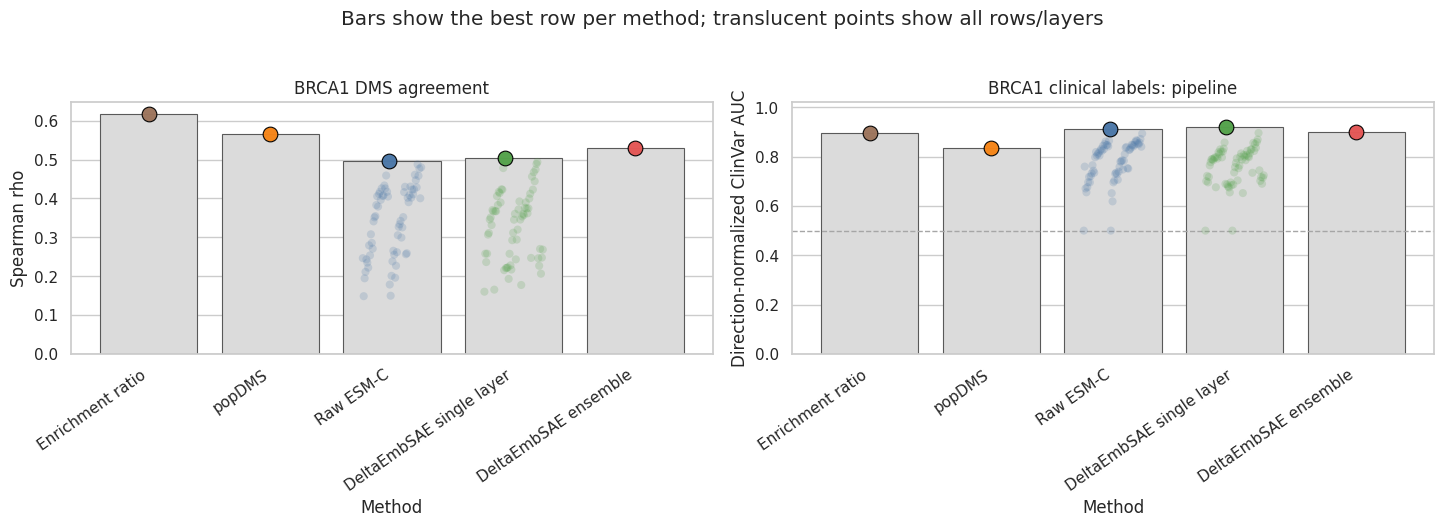

/net/dali/home/barton/dhw28/popDMS/esmDMS/data/clinprotgym_esmc_sae/datasets/MV_BRCA1_Findlay_2018/figures/brca1_sae_downstream/MV_BRCA1_Findlay_2018_best_method_spearman_auc_bars_pipeline.png


In [19]:
plt, sns = ensure_plotting()
BAR_REVIEW_STAR_CUTOFF = 0

if auc_by_labels.empty or best_auc_rows.empty:
    print("No rows to plot. Run the metrics/AUC recompute cells first.")
else:
    all_rows = auc_by_labels[auc_by_labels["min_review_stars"].eq(BAR_REVIEW_STAR_CUTOFF)].copy()
    all_rows["spearman_rho"] = safe_numeric(all_rows.get("spearman_rho", np.nan))
    all_rows["auc_discrimination"] = safe_numeric(all_rows["auc_discrimination"])
    all_rows["method_plot_label"] = all_rows["method_family"].map(method_label)
    all_rows["is_best"] = mark_best_rows(all_rows, best_auc_rows)

    plot_df = best_auc_rows.copy()
    order = [method_label(m) for m in METHOD_ORDER if method_label(m) in set(all_rows["method_plot_label"])]
    x_lookup = {label: idx for idx, label in enumerate(order)}

    fig, axes = plt.subplots(1, 2, figsize=(14.6, 5.1), sharex=False)
    metric_specs = [
        ("spearman_rho", "Spearman rho", "BRCA1 DMS agreement", 0, None),
        ("auc_discrimination", "Direction-normalized ClinVar AUC", f"BRCA1 clinical labels: {CLINICAL_LABEL_MODE}", 0.5, (0, 1.02)),
    ]

    for ax, (metric, ylabel, title, refline, ylim) in zip(axes, metric_specs):
        sns.barplot(
            data=plot_df,
            x="method_plot_label",
            y=metric,
            order=order,
            ax=ax,
            color="0.86",
            edgecolor="0.35",
            linewidth=0.8,
        )
        for label in order:
            sub = all_rows[all_rows["method_plot_label"].eq(label)].copy()
            sub = sub[np.isfinite(sub[metric])]
            if sub.empty:
                continue
            xs = np.full(len(sub), x_lookup[label], dtype=float)
            if len(sub) > 1:
                xs += np.linspace(-0.24, 0.24, len(sub))
            colors = [method_color(v) for v in sub["method_family"]]
            nonbest = ~sub["is_best"].to_numpy(dtype=bool)
            ax.scatter(xs[nonbest], sub.loc[nonbest, metric], s=34, c=np.asarray(colors, dtype=object)[nonbest], alpha=0.20, edgecolors="none", zorder=3)
            best = sub["is_best"].to_numpy(dtype=bool)
            ax.scatter(xs[best], sub.loc[best, metric], s=112, c=np.asarray(colors, dtype=object)[best], alpha=0.98, edgecolors="black", linewidths=0.8, zorder=5)
        ax.axhline(refline, color="0.65", linewidth=1, linestyle="--" if metric == "auc_discrimination" else "-")
        if ylim is not None:
            ax.set_ylim(*ylim)
        ax.set_xlabel("Method")
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.set_xticks(range(len(order)))
        ax.set_xticklabels(order, rotation=35, ha="right")

    fig.suptitle("Bars show the best row per method; translucent points show all rows/layers", y=1.03)
    fig.tight_layout()
    out = FIGURE_DIR / f"{DATASET}_best_method_spearman_auc_bars_{CLINICAL_LABEL_MODE}.png"
    fig.savefig(out, dpi=300, bbox_inches="tight")
    plt.show()
    print(out)


## Plot: AUC By ClinVar Review-Star Cutoff

This mirrors the review-star cutoff plots from the ensemble notebook, but uses the active clinical label table and selects best models by AUC.

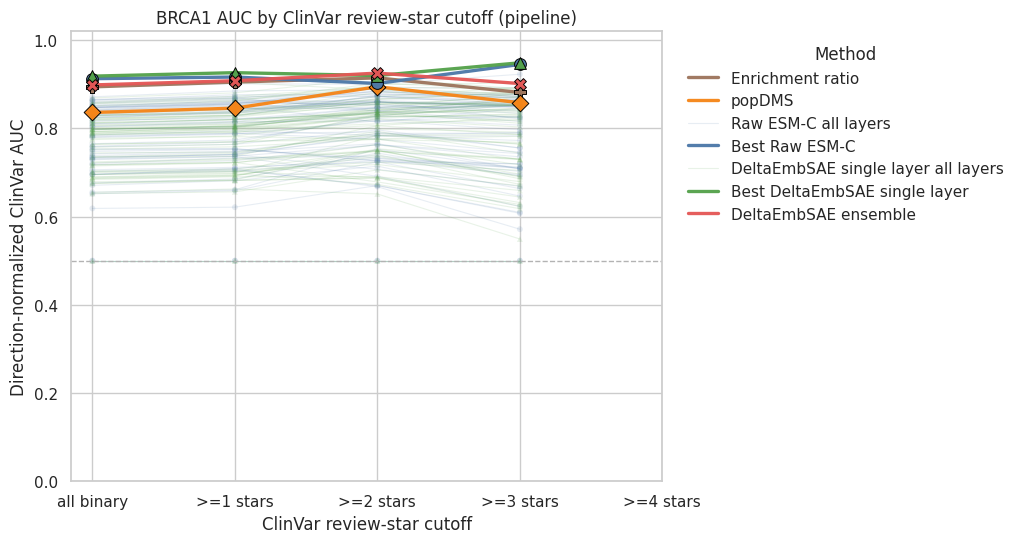

/net/dali/home/barton/dhw28/popDMS/esmDMS/data/clinprotgym_esmc_sae/datasets/MV_BRCA1_Findlay_2018/figures/brca1_sae_downstream/MV_BRCA1_Findlay_2018_auc_by_review_star_cutoff_pipeline.png


,method_plot_label,model_label,review_cutoff,auc,auc_discrimination,n_benign,n_pathogenic
0,DeltaEmbSAE ensemble,Top12 SAE rank_worst gamma=1,all binary,0.898436,0.898436,107,196
1,DeltaEmbSAE ensemble,Top12 SAE rank_worst gamma=1,>=1 stars,0.908019,0.908019,106,192
2,DeltaEmbSAE ensemble,Top12 SAE rank_worst gamma=1,>=2 stars,0.925345,0.925345,19,141
3,DeltaEmbSAE ensemble,Top12 SAE rank_worst gamma=1,>=3 stars,0.901587,0.901587,15,63
10,Enrichment ratio,Enrichment ratio,all binary,0.894049,0.894049,107,196
11,Enrichment ratio,Enrichment ratio,>=1 stars,0.904923,0.904923,106,192
12,Enrichment ratio,Enrichment ratio,>=2 stars,0.914520,0.914520,19,141
13,Enrichment ratio,Enrichment ratio,>=3 stars,0.881481,0.881481,15,63
15,popDMS,Regular popDMS substitution,all binary,0.836019,0.836019,107,196
16,popDMS,Regular popDMS substitution,>=1 stars,0.845863,0.845863,106,192


In [20]:
plt, sns = ensure_plotting()
if auc_by_labels.empty:
    print("No AUC rows to plot.")
else:
    plot_df = auc_by_labels.copy()
    plot_df["auc_discrimination"] = safe_numeric(plot_df["auc_discrimination"])
    plot_df["method_plot_label"] = plot_df["method_family"].map(method_label)
    plot_df["is_best"] = mark_best_rows(plot_df, best_auc_rows)
    plot_df = plot_df[np.isfinite(plot_df["auc_discrimination"])].copy()

    if plot_df.empty:
        print("No finite AUC cutoff rows to plot.")
    else:
        fig, ax = plt.subplots(figsize=(10.4, 5.6))
        seen_labels = set()
        for family in METHOD_ORDER:
            family_df = plot_df[plot_df["method_family"].eq(family)].copy()
            if family_df.empty:
                continue
            color = method_color(family)
            marker = method_marker(family)
            label_base = method_label(family)
            is_layer_family = family in {"Raw embeddings", "Raw SAE"}
            for _, group in family_df.groupby(["model_label", "fitness_path"], dropna=False):
                group = group.sort_values("min_review_stars")
                is_best = bool(group["is_best"].any())
                if is_layer_family and not is_best:
                    label = f"{label_base} all layers" if f"{label_base} all layers" not in seen_labels else "_nolegend_"
                    seen_labels.add(f"{label_base} all layers")
                    ax.plot(group["min_review_stars"], group["auc_discrimination"], color=color, alpha=0.13, linewidth=0.8, label=label, zorder=1)
                    ax.scatter(group["min_review_stars"], group["auc_discrimination"], color=color, alpha=0.13, s=18, marker=marker, edgecolors="none", zorder=1)
                else:
                    if is_best and is_layer_family:
                        label = f"Best {label_base}" if f"Best {label_base}" not in seen_labels else "_nolegend_"
                        seen_labels.add(f"Best {label_base}")
                    else:
                        label = label_base if label_base not in seen_labels else "_nolegend_"
                        seen_labels.add(label_base)
                    ax.plot(group["min_review_stars"], group["auc_discrimination"], color=color, alpha=0.96, linewidth=2.4 if is_best else 1.8, label=label, zorder=4 if is_best else 3)
                    ax.scatter(group["min_review_stars"], group["auc_discrimination"], color=color, alpha=0.98, s=72 if is_best else 48, marker=marker, edgecolors="black" if is_best else "white", linewidths=0.7 if is_best else 0.3, zorder=5 if is_best else 3)
        ax.axhline(0.5, color="0.7", linewidth=1, linestyle="--")
        ax.set_ylim(0, 1.02)
        ax.set_xticks(REVIEW_STAR_CUTOFFS)
        ax.set_xticklabels([f">={s} stars" if s else "all binary" for s in REVIEW_STAR_CUTOFFS])
        ax.set_xlabel("ClinVar review-star cutoff")
        ax.set_ylabel("Direction-normalized ClinVar AUC")
        ax.set_title(f"BRCA1 AUC by ClinVar review-star cutoff ({CLINICAL_LABEL_MODE})")
        ax.legend(title="Method", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
        fig.tight_layout()
        out = FIGURE_DIR / f"{DATASET}_auc_by_review_star_cutoff_{CLINICAL_LABEL_MODE}.png"
        fig.savefig(out, dpi=300, bbox_inches="tight")
        plt.show()
        print(out)
        display(plot_df[plot_df["is_best"]][["method_plot_label", "model_label", "review_cutoff", "auc", "auc_discrimination", "n_benign", "n_pathogenic"]])


## Plot: Spearman Versus AUC

Scatter plot of Spearman rho vs active-label ClinVar AUC for every raw ESM-C layer and every DeltaEmbSAE layer. All layer points are transparent; the best raw ESM-C and best DeltaEmbSAE points are overlaid opaque. Ensemble and non-layer baselines are shown when available, with dotted AUC guide lines for LLR and DMS functional-score baselines.

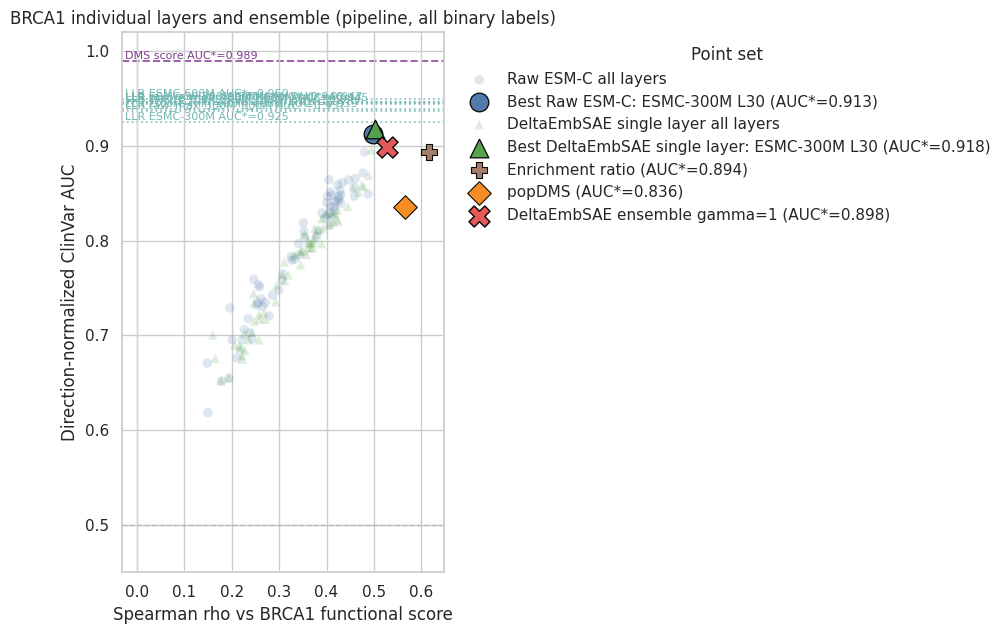

/net/dali/home/barton/dhw28/popDMS/esmDMS/data/clinprotgym_esmc_sae/datasets/MV_BRCA1_Findlay_2018/figures/brca1_sae_downstream/MV_BRCA1_Findlay_2018_all_layers_spearman_vs_auc_pipeline.png


,method_plot_label,n_points
0,DeltaEmbSAE ensemble,1
1,DeltaEmbSAE single layer,66
2,Enrichment ratio,1
3,Raw ESM-C,66
4,popDMS,1


In [21]:
plt, sns = ensure_plotting()
SCATTER_REVIEW_STAR_CUTOFF = 0

if auc_by_labels.empty:
    print("No AUC rows to plot. Run the metrics/AUC recompute cells first.")
else:
    scatter_df = auc_by_labels[auc_by_labels["min_review_stars"].eq(SCATTER_REVIEW_STAR_CUTOFF)].copy()
    scatter_df["spearman_rho"] = safe_numeric(scatter_df.get("spearman_rho", np.nan))
    scatter_df["auc_discrimination"] = safe_numeric(scatter_df["auc_discrimination"])
    scatter_df["layer"] = safe_numeric(scatter_df.get("layer", np.nan))
    scatter_df["method_plot_label"] = scatter_df["method_family"].map(method_label)
    scatter_df["is_best"] = mark_best_rows(scatter_df, best_auc_rows)
    scatter_df = scatter_df[scatter_df["method_family"].isin(METHOD_ORDER)].copy()
    scatter_df = scatter_df[np.isfinite(scatter_df["spearman_rho"]) & np.isfinite(scatter_df["auc_discrimination"])].copy()

    layer_df = scatter_df[scatter_df["method_family"].isin(["Raw embeddings", "Raw SAE"])].copy()
    baseline_df = scatter_df[scatter_df["method_family"].isin(["Enrichment ratio baseline", "popDMS baseline", "LLR baseline"])].copy()
    ensemble_df = scatter_df[scatter_df["method_family"].eq("Ensemble SAE model")].copy()

    fig, ax = plt.subplots(figsize=(9.8, 6.5))

    for family, group in layer_df.groupby("method_family", sort=False):
        color = method_color(family)
        marker = method_marker(family)
        label_base = method_label(family)
        nonbest = group[~group["is_best"]].copy()
        if not nonbest.empty:
            ax.scatter(
                nonbest["spearman_rho"],
                nonbest["auc_discrimination"],
                s=46,
                marker=marker,
                color=color,
                alpha=0.18,
                edgecolor="none",
                label=f"{label_base} all layers",
                zorder=2,
            )
        # Points are identified in the legend rather than annotated in place; the best raw and best SAE
        # points land almost on top of each other, so on-plot labels overlapped.
        for _, row in group[group["is_best"]].iterrows():
            layer_text = "" if pd.isna(row.get("layer")) else f" L{int(row['layer'])}"
            model_text = str(row.get("model_short", "")).replace("nan", "")
            ax.scatter(
                row["spearman_rho"],
                row["auc_discrimination"],
                s=180,
                marker=marker,
                color=color,
                alpha=0.98,
                edgecolor="black",
                linewidth=0.9,
                label=f"Best {label_base}: {model_text}{layer_text} (AUC*={row['auc_discrimination']:.3f})",
                zorder=6,
            )

    for _, row in baseline_df.iterrows():
        family = row["method_family"]
        ax.scatter(
            row["spearman_rho"],
            row["auc_discrimination"],
            s=145,
            marker=method_marker(family),
            color=method_color(family),
            alpha=0.94,
            edgecolor="black",
            linewidth=0.8,
            label=f"{method_label(family)} (AUC*={row['auc_discrimination']:.3f})",
            zorder=5,
        )

    for _, row in ensemble_df.iterrows():
        family = row["method_family"]
        ax.scatter(
            row["spearman_rho"],
            row["auc_discrimination"],
            s=230,
            marker=method_marker(family),
            color=method_color(family),
            alpha=0.98,
            edgecolor="black",
            linewidth=1.0,
            label=f"{method_label(family)} gamma=1 (AUC*={row['auc_discrimination']:.3f})",
            zorder=8,
        )

    # LLR guide lines. The benchmark array does not always emit "LLR baseline" rows, so fall back to
    # scoring the masked-marginal LLR fitness tables directly against the active labels.
    def llr_guide_lines(min_stars=SCATTER_REVIEW_STAR_CUTOFF):
        rows = scatter_df[scatter_df["method_family"].eq("LLR baseline")].copy()
        if not rows.empty:
            return [
                (str(row.get("model_label") or row.get("model_short") or method_label("LLR baseline")), float(row["auc_discrimination"]))
                for _, row in rows.iterrows()
            ]
        guides = []
        for path in sorted(TABLE_DIR.glob(f"{DATASET}_*_llr_fitness.csv")):
            stats = auc_from_labeled_fitness(fitness_with_active_labels(path, min_stars=min_stars))
            if not np.isfinite(stats["auc_discrimination"]):
                continue
            model_tag = path.stem.replace(f"{DATASET}_", "").replace("_llr_fitness", "").split("__")[-1]
            guides.append((f"{method_label('LLR baseline')} {model_tag}", stats["auc_discrimination"]))
        return guides

    for label, y in llr_guide_lines():
        color = method_color("LLR baseline")
        ax.axhline(y, color=color, linestyle=":", linewidth=1.3, alpha=0.8, zorder=0)
        ax.text(0.01, y, f"{label} AUC*={y:.3f}", transform=ax.get_yaxis_transform(), va="bottom", ha="left", fontsize=8, color=color)

    # DMS functional score is a reference method, not a point in METHOD_ORDER, so it only appears as a guide line.
    reference_df = auc_by_labels[
        auc_by_labels["min_review_stars"].eq(SCATTER_REVIEW_STAR_CUTOFF)
        & auc_by_labels["method_family"].isin(REFERENCE_METHODS)
    ].copy()
    reference_df["auc_discrimination"] = safe_numeric(reference_df["auc_discrimination"])
    reference_df = (
        reference_df[np.isfinite(reference_df["auc_discrimination"])]
        .sort_values("auc_discrimination", ascending=False)
        .drop_duplicates("method_family")
    )
    for _, row in reference_df.iterrows():
        family = row["method_family"]
        y = row["auc_discrimination"]
        color = method_color(family)
        ax.axhline(y, color=color, linestyle="--", linewidth=1.4, alpha=0.8, zorder=0)
        ax.text(0.01, y, f"{method_label(family)} AUC*={y:.3f}", transform=ax.get_yaxis_transform(), va="bottom", ha="left", fontsize=8, color=color)

    ax.axvline(0, color="0.84", linewidth=1)
    ax.axhline(0.5, color="0.72", linewidth=1, linestyle="--")
    ax.set_ylim(0.45, 1.02)
    ax.set_xlabel("Spearman rho vs BRCA1 functional score")
    ax.set_ylabel("Direction-normalized ClinVar AUC")
    cutoff_label = "all binary labels" if SCATTER_REVIEW_STAR_CUTOFF == 0 else f">={SCATTER_REVIEW_STAR_CUTOFF} review stars"
    ax.set_title(f"BRCA1 individual layers and ensemble ({CLINICAL_LABEL_MODE}, {cutoff_label})")

    handles, labels = ax.get_legend_handles_labels()
    seen = set()
    dedup_handles, dedup_labels = [], []
    for handle, label in zip(handles, labels):
        if label in seen or label == "":
            continue
        seen.add(label)
        dedup_handles.append(handle)
        dedup_labels.append(label)
    ax.legend(dedup_handles, dedup_labels, title="Point set", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)

    fig.tight_layout()
    out = FIGURE_DIR / f"{DATASET}_all_layers_spearman_vs_auc_{CLINICAL_LABEL_MODE}.png"
    fig.savefig(out, dpi=300, bbox_inches="tight")
    plt.show()
    print(out)
    display(scatter_df.groupby("method_plot_label").size().rename("n_points").reset_index())


## Plot: Layer-Wise Raw ESM-C And SAE Performance

This shows whether the new sequence-deduplicated SAE run changes the layer profile relative to raw max-pooled ESM-C embeddings.

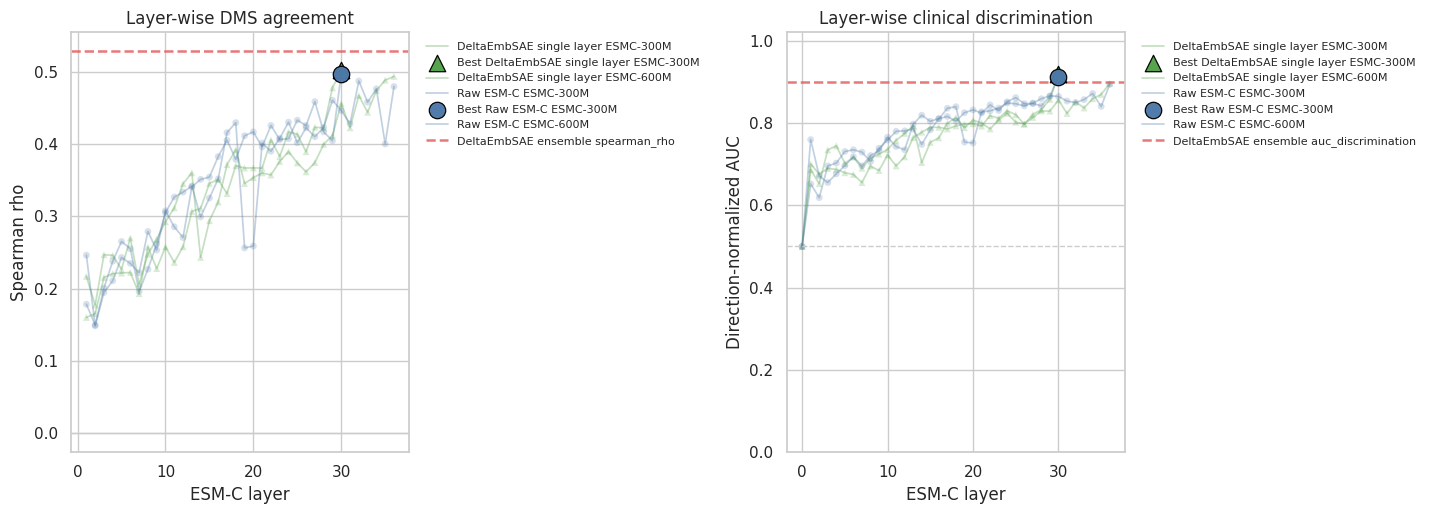

/net/dali/home/barton/dhw28/popDMS/esmDMS/data/clinprotgym_esmc_sae/datasets/MV_BRCA1_Findlay_2018/figures/brca1_sae_downstream/MV_BRCA1_Findlay_2018_layerwise_raw_vs_sae_pipeline.png


In [22]:
plt, sns = ensure_plotting()
LAYERWISE_REVIEW_STAR_CUTOFF = 0

if auc_by_labels.empty:
    print("No metrics loaded.")
else:
    layer_df = auc_by_labels[
        auc_by_labels["min_review_stars"].eq(LAYERWISE_REVIEW_STAR_CUTOFF)
        & auc_by_labels["method_family"].isin(["Raw embeddings", "Raw SAE"])
    ].copy()
    if layer_df.empty:
        print("No layer-wise raw embedding/DeltaEmbSAE rows. Run and collect benchmark jobs first.")
    else:
        layer_df["layer"] = safe_numeric(layer_df["layer"])
        layer_df["spearman_rho"] = safe_numeric(layer_df["spearman_rho"])
        layer_df["auc_discrimination"] = safe_numeric(layer_df["auc_discrimination"])
        layer_df["method_plot_label"] = layer_df["method_family"].map(method_label)
        layer_df["is_best"] = mark_best_rows(layer_df, best_auc_rows)

        ensemble_df = auc_by_labels[
            auc_by_labels["min_review_stars"].eq(LAYERWISE_REVIEW_STAR_CUTOFF)
            & auc_by_labels["method_family"].eq("Ensemble SAE model")
        ].copy()
        if not ensemble_df.empty:
            ensemble_df["spearman_rho"] = safe_numeric(ensemble_df["spearman_rho"])
            ensemble_df["auc_discrimination"] = safe_numeric(ensemble_df["auc_discrimination"])

        fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.3), sharex=False)
        metric_specs = [
            ("spearman_rho", "Spearman rho", "Layer-wise DMS agreement", 0),
            ("auc_discrimination", "Direction-normalized AUC", "Layer-wise clinical discrimination", 0.5),
        ]

        for ax, (metric, ylabel, title, refline) in zip(axes, metric_specs):
            for (family, model_short), group in layer_df.groupby(["method_family", "model_short"], dropna=False):
                group = group.sort_values("layer")
                color = method_color(family)
                marker = method_marker(family)
                label_base = f"{method_label(family)} {model_short}"
                ax.plot(group["layer"], group[metric], color=color, alpha=0.34, linewidth=1.25, label=label_base)
                ax.scatter(group["layer"], group[metric], color=color, alpha=0.22, s=24, marker=marker, edgecolors="none")

                best = group[group["is_best"]].copy()
                if not best.empty:
                    ax.scatter(best["layer"], best[metric], color=color, alpha=0.98, s=140, marker=marker, edgecolors="black", linewidths=0.9, label=f"Best {method_label(family)} {model_short}", zorder=6)

            if not ensemble_df.empty and metric in ensemble_df.columns:
                for _, row in ensemble_df.iterrows():
                    y = row.get(metric)
                    if pd.notna(y) and np.isfinite(y):
                        ax.axhline(y, color=method_color("Ensemble SAE model"), linestyle="--", linewidth=1.8, alpha=0.80, label=f"{method_label('Ensemble SAE model')} {metric}")
            ax.axhline(refline, color="0.8", linewidth=1, linestyle="--" if metric == "auc_discrimination" else "-")
            if metric == "auc_discrimination":
                ax.set_ylim(0, 1.02)
            ax.set_xlabel("ESM-C layer")
            ax.set_ylabel(ylabel)
            ax.set_title(title)
            handles, labels = ax.get_legend_handles_labels()
            seen = set()
            keep_h, keep_l = [], []
            for h, l in zip(handles, labels):
                if l in seen:
                    continue
                seen.add(l)
                keep_h.append(h)
                keep_l.append(l)
            ax.legend(keep_h, keep_l, bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False, fontsize=8)

        fig.tight_layout()
        out = FIGURE_DIR / f"{DATASET}_layerwise_raw_vs_sae_{CLINICAL_LABEL_MODE}.png"
        fig.savefig(out, dpi=300, bbox_inches="tight")
        plt.show()
        print(out)


## Plot: Best Method Fitness Distribution By Clinical Annotation

The best method is selected by active-label AUC, then its fitness values are split by benign/pathogenic labels across review-star cutoffs.

Best by AUC: DeltaEmbSAE single layer | ESMC-300M Layer_30 DeltaEmbSAE_max_pool_batchtopk_k64_nf12800_seed42_seqdedup_v2 | /net/dali/home/barton/dhw28/popDMS/esmDMS/data/clinprotgym_esmc_sae/datasets/MV_BRCA1_Findlay_2018/jobs/benchmark_row_analysis/fitness/00095_MV_BRCA1_Findlay_2018_ESMC-300M_Layer_30_DeltaEmbSAE_max_pool_batchtopk_k64_nf12800_seed42_seqdedup_v2_fitness.csv


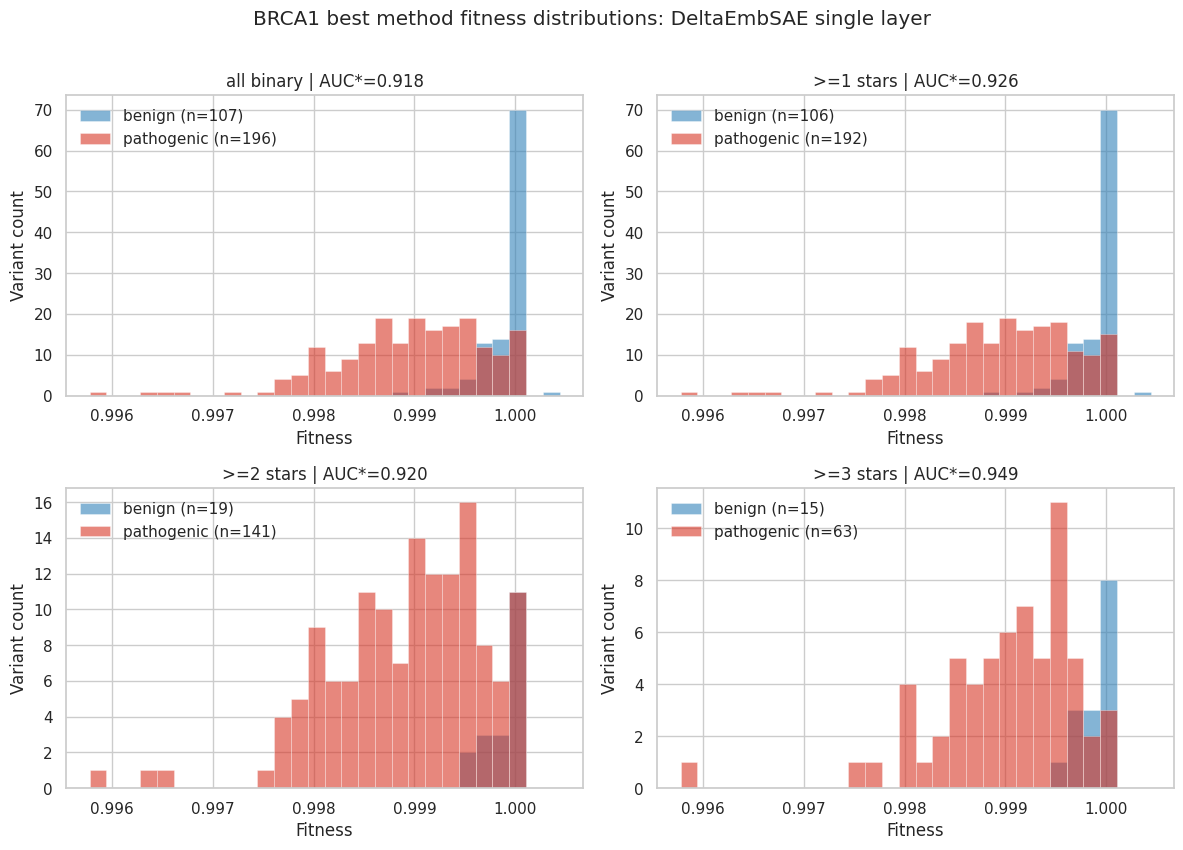

/net/dali/home/barton/dhw28/popDMS/esmDMS/data/clinprotgym_esmc_sae/datasets/MV_BRCA1_Findlay_2018/figures/brca1_sae_downstream/MV_BRCA1_Findlay_2018_best_auc_method_fitness_distribution_pipeline.png


In [23]:
plt, sns = ensure_plotting()
if best_auc_rows.empty:
    print("No best AUC row available.")
else:
    best_row = best_auc_rows.sort_values(["auc_discrimination", "spearman_rho"], ascending=[False, False]).iloc[0]
    best_fitness_path = Path(str(best_row["fitness_path"]))
    print(f"Best by AUC: {method_label(best_row['method_family'])} | {best_row['model_label']} | {best_fitness_path}")
    panels = []
    for min_stars in REVIEW_STAR_CUTOFFS:
        panel = fitness_with_active_labels(best_fitness_path, min_stars=min_stars)
        panel = normalize_label_columns(panel)
        panel = panel[panel["annotation"].isin(PATHOGENICITY_LABELS) & np.isfinite(panel["fitness"])].copy()
        if panel.empty:
            continue
        stats = auc_from_labeled_fitness(panel)
        panels.append((min_stars, panel, stats))
    if not panels:
        print("No labeled variants overlap this fitness table.")
    else:
        finite = pd.concat([p[1] for p in panels], ignore_index=True)["fitness"].to_numpy(dtype=float)
        bins = np.histogram_bin_edges(finite, bins=min(30, max(8, int(np.sqrt(len(finite))))))
        ncols = 2
        nrows = int(np.ceil(len(panels) / ncols))
        fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4.2 * nrows), squeeze=False)
        palette = {"benign": "#2C7FB8", "pathogenic": "#D7301F"}
        for ax, (min_stars, panel, stats) in zip(axes.ravel(), panels):
            for annotation in ["benign", "pathogenic"]:
                values = panel.loc[panel["annotation"].eq(annotation), "fitness"].to_numpy(dtype=float)
                ax.hist(values, bins=bins, alpha=0.58, color=palette[annotation], label=f"{annotation} (n={len(values)})", edgecolor="white", linewidth=0.4)
            ax.set_title(f"{'>=' + str(min_stars) + ' stars' if min_stars else 'all binary'} | AUC*={stats['auc_discrimination']:.3f}")
            ax.set_xlabel("Fitness")
            ax.set_ylabel("Variant count")
            ax.legend(frameon=False)
        for ax in axes.ravel()[len(panels):]:
            ax.axis("off")
        fig.suptitle(f"BRCA1 best method fitness distributions: {method_label(best_row['method_family'])}", y=1.01)
        fig.tight_layout()
        out = FIGURE_DIR / f"{DATASET}_best_auc_method_fitness_distribution_{CLINICAL_LABEL_MODE}.png"
        fig.savefig(out, dpi=300, bbox_inches="tight")
        plt.show()
        print(out)


## SAE Ensemble Component Contributions

For the gamma=1 rank-worst ensemble, this counts which source SAE component supplies the selected worst rank for each variant. This mirrors the component-contribution analysis in the old ensemble notebook.

,component,fraction_selected,n_selected,spearman_rho,auc,model_label
0,ESMC-300M_L30,0.228089,419,0.502812,0.918415,ESMC-300M Layer_30 DeltaEmbSAE_max_pool_batcht...
1,ESMC-600M_L36,0.211214,388,0.493864,0.895909,ESMC-600M Layer_36 DeltaEmbSAE_max_pool_batcht...
2,ESMC-300M_L24,0.104518,192,0.416950,0.829392,ESMC-300M Layer_24 DeltaEmbSAE_max_pool_batcht...
3,ESMC-600M_L35,0.070768,130,0.488710,0.869064,ESMC-600M Layer_35 DeltaEmbSAE_max_pool_batcht...
4,ESMC-600M_L30,0.059880,110,0.456288,0.855665,ESMC-600M Layer_30 DeltaEmbSAE_max_pool_batcht...
5,ESMC-300M_L28,0.053348,98,0.422453,0.832348,ESMC-300M Layer_28 DeltaEmbSAE_max_pool_batcht...
6,ESMC-300M_L27,0.052259,96,0.423549,0.820475,ESMC-300M Layer_27 DeltaEmbSAE_max_pool_batcht...
7,ESMC-600M_L31,0.051715,95,0.422706,0.822954,ESMC-600M Layer_31 DeltaEmbSAE_max_pool_batcht...
8,ESMC-600M_L34,0.044638,82,0.474282,0.858907,ESMC-600M Layer_34 DeltaEmbSAE_max_pool_batcht...
9,ESMC-600M_L33,0.043005,79,0.444224,0.836306,ESMC-600M Layer_33 DeltaEmbSAE_max_pool_batcht...


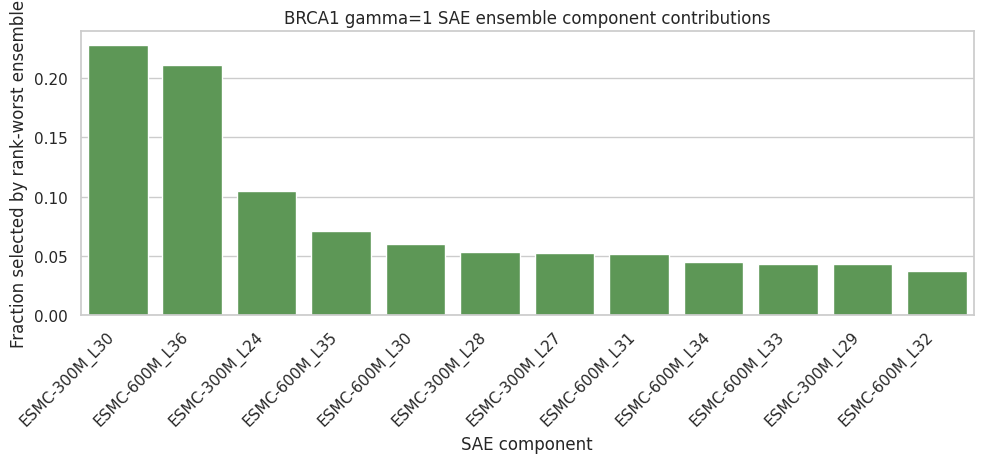

/net/dali/home/barton/dhw28/popDMS/esmDMS/data/clinprotgym_esmc_sae/datasets/MV_BRCA1_Findlay_2018/figures/brca1_sae_downstream/MV_BRCA1_Findlay_2018_sae_ensemble_component_contributions.png


In [24]:
plt, sns = ensure_plotting()
component_paths_table = TABLE_DIR / "sae_ensemble_gamma1" / f"{DATASET}_ensemble_component_fitness_paths.csv"
source_table = TABLE_DIR / "sae_ensemble_gamma1" / f"{DATASET}_ensemble_sources.csv"
components = read_csv(component_paths_table)
sources = read_csv(source_table)
if components.empty:
    print(f"No ensemble component table found yet: {component_paths_table}")
else:
    series = []
    for _, row in components.iterrows():
        path = Path(str(row["fitness_path"]))
        if not path.is_file():
            continue
        fitness = pd.read_csv(path)[["SequenceIndex", "fitness"]].copy()
        fitness["SequenceIndex"] = fitness["SequenceIndex"].astype(str)
        name = f"{row.get('model_short', row.get('model', 'model'))}_L{int(float(row['layer']))}"
        series.append(pd.Series(safe_numeric(fitness["fitness"]).to_numpy(dtype=float), index=fitness["SequenceIndex"], name=name))
    if not series:
        print("No component fitness files were readable.")
    else:
        score_matrix = pd.concat(series, axis=1)
        rank_matrix = score_matrix.rank(method="average", ascending=True)
        selected_component = rank_matrix.idxmin(axis=1)
        contribution = selected_component.value_counts(normalize=True).rename_axis("component").reset_index(name="fraction_selected")
        contribution["n_selected"] = selected_component.value_counts().reindex(contribution["component"]).to_numpy()
        if not sources.empty:
            sources = sources.copy()
            sources["component"] = sources.apply(lambda r: f"{r.get('model_short', r.get('model', 'model'))}_L{int(float(r['layer']))}", axis=1)
            contribution = contribution.merge(sources[["component", "spearman_rho", "auc", "model_label"]], on="component", how="left")
        display(contribution)
        fig, ax = plt.subplots(figsize=(10, 4.8))
        sns.barplot(data=contribution, x="component", y="fraction_selected", color="#54A24B", ax=ax)
        ax.set_xlabel("SAE component")
        ax.set_ylabel("Fraction selected by rank-worst ensemble")
        ax.set_title("BRCA1 gamma=1 SAE ensemble component contributions")
        ax.tick_params(axis="x", rotation=45)
        for tick in ax.get_xticklabels():
            tick.set_horizontalalignment("right")
        fig.tight_layout()
        out = FIGURE_DIR / f"{DATASET}_sae_ensemble_component_contributions.png"
        fig.savefig(out, dpi=300, bbox_inches="tight")
        plt.show()
        print(out)


## UMAP/PCA Of SAE Ensemble Component Ranks

This uses the component-rank matrix from the gamma=1 ensemble. If `umap-learn` is not installed, it falls back to PCA so the cell still produces an embedding plot.

/net/dali/home/barton/dhw28/.conda/envs/py312/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


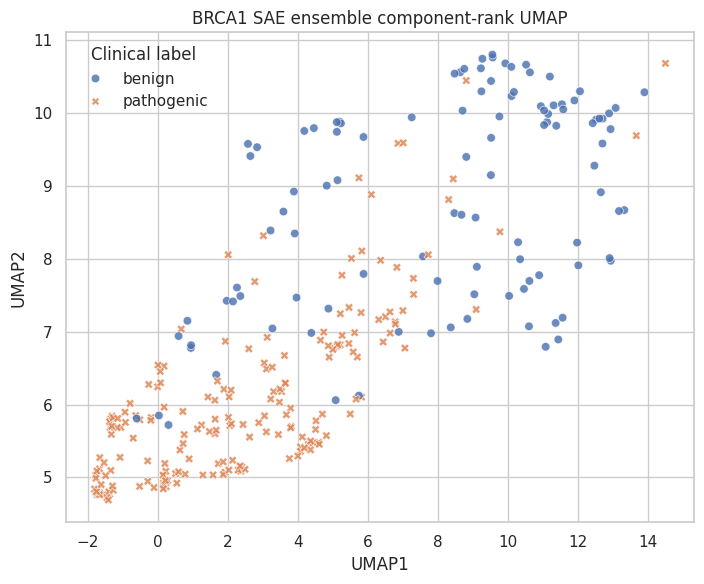

/net/dali/home/barton/dhw28/popDMS/esmDMS/data/clinprotgym_esmc_sae/datasets/MV_BRCA1_Findlay_2018/figures/brca1_sae_downstream/MV_BRCA1_Findlay_2018_sae_ensemble_component_rank_umap_pipeline.png


In [25]:
plt, sns = ensure_plotting()
if "score_matrix" not in globals() or score_matrix.empty:
    print("Run the component contribution cell first, after ensemble outputs exist.")
else:
    rank_matrix = score_matrix.rank(method="average", ascending=True).dropna(how="any")
    if len(rank_matrix) < 3:
        print("Not enough complete variants for embedding.")
    else:
        try:
            import umap
            reducer = umap.UMAP(n_components=2, n_neighbors=min(30, len(rank_matrix) - 1), min_dist=0.12, random_state=42)
            coords = reducer.fit_transform(rank_matrix.to_numpy(dtype=float))
            coord_name = "UMAP"
        except Exception as exc:
            from sklearn.decomposition import PCA
            print(f"UMAP unavailable; falling back to PCA: {exc}")
            coords = PCA(n_components=2, random_state=42).fit_transform(rank_matrix.to_numpy(dtype=float))
            coord_name = "PCA"
        emb = pd.DataFrame({"SequenceIndex": rank_matrix.index.astype(str), f"{coord_name}1": coords[:, 0], f"{coord_name}2": coords[:, 1]})
        label_df = normalize_label_columns(active_labels)
        label_df = label_df[label_df["annotation"].isin(PATHOGENICITY_LABELS)].copy()
        emb = emb.merge(label_df[["SequenceIndex", "annotation", "stars"]], on="SequenceIndex", how="left", suffixes=("", "_label"))
        emb = normalize_label_columns(emb)
        fig, ax = plt.subplots(figsize=(7.2, 6.0))
        sns.scatterplot(data=emb, x=f"{coord_name}1", y=f"{coord_name}2", hue="annotation", style="annotation", alpha=0.82, s=38, ax=ax)
        ax.set_title(f"BRCA1 SAE ensemble component-rank {coord_name}")
        ax.legend(title="Clinical label", frameon=False)
        fig.tight_layout()
        out = FIGURE_DIR / f"{DATASET}_sae_ensemble_component_rank_{coord_name.lower()}_{CLINICAL_LABEL_MODE}.png"
        fig.savefig(out, dpi=300, bbox_inches="tight")
        plt.show()
        print(out)


## Output Checklist

Useful files after running the notebook:

- SAE metrics: `data/clinprotgym_esmc_sae/datasets/MV_BRCA1_Findlay_2018/tables/MV_BRCA1_Findlay_2018_fixed_deltaembsae_layer_metrics.csv`
- LLR fitness tables: `data/clinprotgym_esmc_sae/datasets/MV_BRCA1_Findlay_2018/tables/*_llr_fitness.csv`
- Benchmark metrics: `data/clinprotgym_esmc_sae/datasets/MV_BRCA1_Findlay_2018/tables/MV_BRCA1_Findlay_2018_method_metrics.csv`
- Ensemble metrics: `data/clinprotgym_esmc_sae/datasets/MV_BRCA1_Findlay_2018/tables/MV_BRCA1_Findlay_2018_sae_ensemble_metrics.csv`
- Notebook-specific figures: `data/clinprotgym_esmc_sae/datasets/MV_BRCA1_Findlay_2018/figures/brca1_sae_downstream/`

## Reconstruction And Cross-Replicate Diagnostics

This builds one row per raw ESM-C layer and per DeltaEmbSAE layer with:

- `cross_replicate_consistency`: mean pairwise Pearson r between the per-replicate popDMS selection vectors (`InferenceResult.s`) each model produces. SAE rows read the pickle named in `inference_path`; raw ESM-C rows leave that column blank in the benchmark tables, so the cell resolves their cached inference pickle under `sequence_data/`.
- `mean_cosine_similarity`: mean per-sequence cosine similarity between the original and SAE-reconstructed embeddings (held-out split when available), from the SAE `viz_path`.
- `fraction_variance_explained`: `1 - SSE/SST` on the same split, i.e. the fraction of embedding variance the SAE reconstruction retains.

Raw ESM-C rows have no reconstruction (they are the reconstruction target), so their cosine/variance columns stay `NaN`.

The pickle reads are slow, so results are cached per `inference_path`. Set `REBUILD_MODEL_DIAGNOSTICS = True` to recompute from scratch.


In [26]:
from scipy.stats import pearsonr, spearmanr

DIAGNOSTIC_REVIEW_STAR_CUTOFF = 0
REBUILD_MODEL_DIAGNOSTICS = False
MODEL_DIAGNOSTICS_CACHE = TABLE_DIR / f"{DATASET}_model_reconstruction_consistency_diagnostics.csv"
DIAGNOSTIC_COLUMNS = [
    "cross_replicate_consistency",
    "n_replicate_pairs",
    "mean_cosine_similarity",
    "fraction_variance_explained",
]

def load_pickle(path):
    with Path(path).open("rb") as handle:
        return pickle.load(handle)

def existing_path(value):
    if value is None or (isinstance(value, float) and np.isnan(value)) or pd.isna(value) or not str(value):
        return None
    path = Path(str(value))
    return path if path.is_file() else None

def resolve_inference_path(row):
    """Raw-embedding benchmark rows leave inference_path blank, but popDMS caches their inference pickle under sequence_data."""
    path = existing_path(row.get("inference_path"))
    if path is not None:
        return str(path)
    layer = safe_numeric(pd.Series([row.get("layer")])).iloc[0]
    model = str(row.get("model", ""))
    if not model or not np.isfinite(layer):
        return ""
    pattern = f"{DATASET}_{model.replace('/', '__')}_*_none_Layer_{int(layer)}_none_inference_results.pkl"
    matches = sorted((DATASET_ROOT / "sequence_data").glob(pattern))
    return str(matches[0]) if matches else ""

def mean_pairwise_pearson(matrix):
    arr = np.asarray(matrix, dtype=float)
    if arr.ndim != 2 or arr.shape[0] < 2:
        return np.nan, 0
    pair_corrs = []
    for i in range(arr.shape[0]):
        for j in range(i + 1, arr.shape[0]):
            finite = np.isfinite(arr[i]) & np.isfinite(arr[j])
            x, y = arr[i][finite], arr[j][finite]
            if len(x) < 3 or np.std(x) == 0 or np.std(y) == 0:
                continue
            pair_corrs.append(float(pearsonr(x, y).statistic))
    if not pair_corrs:
        return np.nan, 0
    return float(np.mean(pair_corrs)), len(pair_corrs)

def inference_consistency(inference_path):
    """Mean pairwise Pearson r across the per-replicate popDMS selection vectors."""
    path = existing_path(inference_path)
    if path is None:
        return np.nan, 0
    s_replicates = getattr(load_pickle(path), "s", None)
    if s_replicates is None:
        return np.nan, 0
    return mean_pairwise_pearson(s_replicates)

def sae_reconstruction_quality(viz_path):
    """Cosine similarity and fraction of variance explained between original and SAE-reconstructed embeddings."""
    path = existing_path(viz_path)
    if path is None:
        return {"mean_cosine_similarity": np.nan, "fraction_variance_explained": np.nan}
    viz = load_pickle(path)
    x = np.asarray(viz["X_original"], dtype=float)
    x_recon = np.asarray(viz["X_reconstructed"], dtype=float)
    test_idx = np.asarray(viz.get("test_idx") or [], dtype=int)
    eval_idx = test_idx if len(test_idx) else np.arange(x.shape[0])
    x, x_recon = x[eval_idx], x_recon[eval_idx]
    norms = np.linalg.norm(x, axis=1) * np.linalg.norm(x_recon, axis=1)
    cosine = np.divide(np.einsum("ij,ij->i", x, x_recon), norms, out=np.full(len(x), np.nan), where=norms > 0)
    residual_ss = float(np.sum((x - x_recon) ** 2))
    total_ss = float(np.sum((x - x.mean(axis=0, keepdims=True)) ** 2))
    return {
        "mean_cosine_similarity": float(np.nanmean(cosine)) if np.isfinite(cosine).any() else np.nan,
        "fraction_variance_explained": 1.0 - residual_ss / total_ss if total_ss > 0 else np.nan,
    }

def build_model_diagnostics(auc_table, sae_layer_metrics, min_stars=DIAGNOSTIC_REVIEW_STAR_CUTOFF, rebuild=REBUILD_MODEL_DIAGNOSTICS):
    if auc_table.empty:
        return pd.DataFrame()
    rows = auc_table[
        auc_table["min_review_stars"].eq(min_stars)
        & auc_table["method_family"].isin(["Raw embeddings", "Raw SAE"])
    ].copy()
    if rows.empty:
        return pd.DataFrame()
    keep = [c for c in [
        "method_family", "benchmark", "model", "model_short", "layer", "model_label",
        "spearman_rho", "auc", "auc_discrimination", "n_benign", "n_pathogenic",
        "inference_path", "fitness_path",
    ] if c in rows.columns]
    rows = rows[keep].copy()
    rows["layer"] = safe_numeric(rows["layer"])
    rows["spearman_rho"] = safe_numeric(rows["spearman_rho"])
    rows["auc_discrimination"] = safe_numeric(rows["auc_discrimination"])
    rows["inference_path"] = rows.apply(resolve_inference_path, axis=1)

    # SAE viz pickles hold the reconstruction; join them onto the benchmark rows by inference_path.
    viz_lookup = {}
    if not sae_layer_metrics.empty and {"inference_path", "viz_path", "run_label"} <= set(sae_layer_metrics.columns):
        current = sae_layer_metrics[sae_layer_metrics["run_label"].astype(str).eq(RUN_LABEL)]
        viz_lookup = dict(zip(current["inference_path"].astype(str), current["viz_path"].astype(str)))
    rows["viz_path"] = rows["inference_path"].map(viz_lookup).fillna("")

    cache = {}
    cached = pd.DataFrame() if rebuild else read_csv(MODEL_DIAGNOSTICS_CACHE)
    if not cached.empty and "inference_path" in cached.columns:
        for _, cached_row in cached.iterrows():
            cache[str(cached_row["inference_path"])] = {col: cached_row.get(col, np.nan) for col in DIAGNOSTIC_COLUMNS}

    records = []
    n_computed = 0
    for _, row in rows.iterrows():
        key = row["inference_path"]
        values = cache.get(key)
        if values is None:
            rho, n_pairs = inference_consistency(key)
            values = {
                "cross_replicate_consistency": rho,
                "n_replicate_pairs": n_pairs,
                **sae_reconstruction_quality(row["viz_path"]),
            }
            cache[key] = values
            n_computed += 1
        records.append({**row.to_dict(), **values})

    diagnostics = pd.DataFrame(records)
    for col in DIAGNOSTIC_COLUMNS:
        diagnostics[col] = safe_numeric(diagnostics[col])
    diagnostics["method_plot_label"] = diagnostics["method_family"].map(method_label)
    diagnostics["is_best"] = mark_best_rows(diagnostics, best_auc_rows)
    print(f"Computed diagnostics for {n_computed} model rows; {len(diagnostics) - n_computed} came from the cache.")
    MODEL_DIAGNOSTICS_CACHE.parent.mkdir(parents=True, exist_ok=True)
    diagnostics.to_csv(MODEL_DIAGNOSTICS_CACHE, index=False)
    return diagnostics

model_diagnostics = build_model_diagnostics(auc_by_labels, sae_metrics)
if model_diagnostics.empty:
    print("No raw-embedding/SAE rows available. Run the metrics/AUC recompute cells first.")
else:
    print(f"Diagnostic rows: {len(model_diagnostics)}")
    print(MODEL_DIAGNOSTICS_CACHE)
    display(
        model_diagnostics.groupby("method_plot_label")[
            ["auc_discrimination", "cross_replicate_consistency", "mean_cosine_similarity", "fraction_variance_explained"]
        ].agg(["count", "median", "max"])
    )
    display(
        model_diagnostics.sort_values("auc_discrimination", ascending=False)[
            ["method_plot_label", "model_short", "layer", "auc_discrimination", "spearman_rho",
             "cross_replicate_consistency", "mean_cosine_similarity", "fraction_variance_explained", "is_best"]
        ].head(10)
    )


Computed diagnostics for 0 model rows; 136 came from the cache.
Diagnostic rows: 136
/net/dali/home/barton/dhw28/popDMS/esmDMS/data/clinprotgym_esmc_sae/datasets/MV_BRCA1_Findlay_2018/tables/MV_BRCA1_Findlay_2018_model_reconstruction_consistency_diagnostics.csv


auc_discrimination                      \
                                      count    median       max   
method_plot_label                                                 
DeltaEmbSAE single layer                 68  0.788671  0.918415   
Raw ESM-C                                68  0.806862  0.912645   

                         cross_replicate_consistency                      \
                                               count    median       max   
method_plot_label                                                          
DeltaEmbSAE single layer                          66  0.878112  0.955238   
Raw ESM-C                                         68  0.880566  0.958673   

                         mean_cosine_similarity                      \
                                          count    median       max   
method_plot_label                                                     
DeltaEmbSAE single layer                     66  0.831876  0.909147   
Raw ESM-C                                     0       NaN       NaN   

                         fraction_variance_explained                      
                                               count    median       max  
method_plot_label                                                         
DeltaEmbSAE single layer                          66  0.851709  0.949795  
Raw ESM-C                                          0       NaN       NaN

,method_plot_label,model_short,layer,auc_discrimination,spearman_rho,cross_replicate_consistency,mean_cosine_similarity,fraction_variance_explained,is_best
92,DeltaEmbSAE single layer,ESMC-300M,30.0,0.918415,0.502812,0.955238,0.512213,-0.400970,True
30,Raw ESM-C,ESMC-300M,30.0,0.912645,0.497372,0.958673,NaN,NaN,True
129,DeltaEmbSAE single layer,ESMC-600M,36.0,0.895909,0.493864,0.937865,0.513796,-0.196854,False
67,Raw ESM-C,ESMC-600M,36.0,0.893525,0.479928,0.950388,NaN,NaN,False
65,Raw ESM-C,ESMC-600M,34.0,0.871495,0.476696,0.847283,NaN,NaN,False
128,DeltaEmbSAE single layer,ESMC-600M,35.0,0.869064,0.488710,0.849603,0.774629,0.719897,False
60,Raw ESM-C,ESMC-600M,29.0,0.865678,0.460888,0.828464,NaN,NaN,False
29,Raw ESM-C,ESMC-300M,29.0,0.864438,0.404854,0.941213,NaN,NaN,False
61,Raw ESM-C,ESMC-600M,30.0,0.864248,0.446704,0.836529,NaN,NaN,False
25,Raw ESM-C,ESMC-300M,25.0,0.861339,0.433394,0.861537,NaN,NaN,False


## Plot: AUC Distribution For Raw ESM-C Layers Versus SAE Layers

Histogram of direction-normalized ClinVar AUC across every raw ESM-C layer and every DeltaEmbSAE layer, with each family's median and best layer marked, plus dotted guide lines for the non-model baselines.


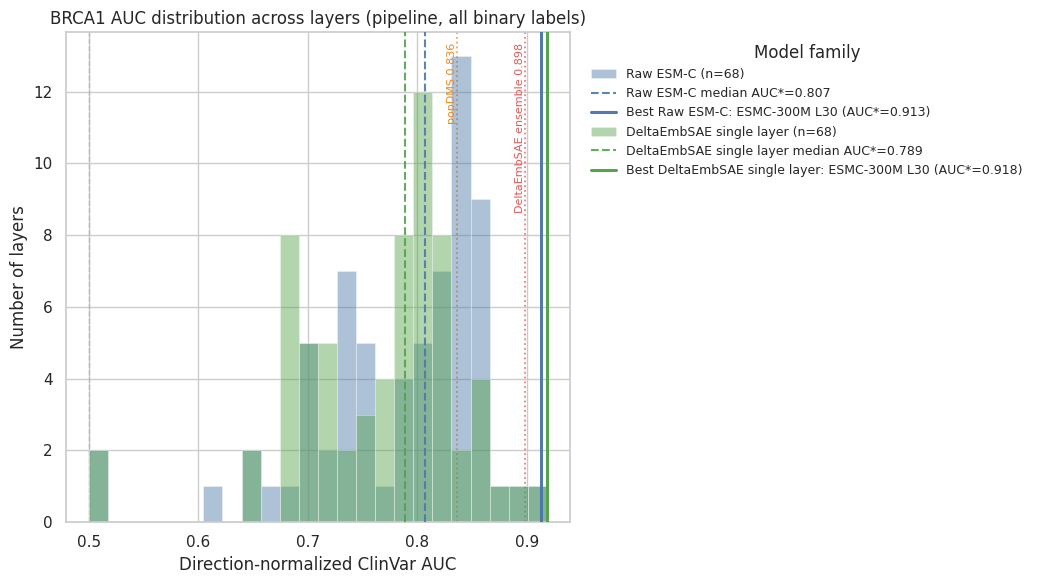

/net/dali/home/barton/dhw28/popDMS/esmDMS/data/clinprotgym_esmc_sae/datasets/MV_BRCA1_Findlay_2018/figures/brca1_sae_downstream/MV_BRCA1_Findlay_2018_auc_distribution_raw_vs_sae_pipeline.png


,count,min,median,mean,max
method_plot_label,,,,,
DeltaEmbSAE single layer,68,0.5,0.788671,0.764613,0.918415
Raw ESM-C,68,0.5,0.806862,0.781703,0.912645


In [27]:
plt, sns = ensure_plotting()

if model_diagnostics.empty:
    print("No diagnostics to plot. Run the diagnostics cell first.")
else:
    dist_df = model_diagnostics[np.isfinite(model_diagnostics["auc_discrimination"])].copy()
    if dist_df.empty:
        print("No finite AUC values to plot.")
    else:
        baselines = auc_by_labels[
            auc_by_labels["min_review_stars"].eq(DIAGNOSTIC_REVIEW_STAR_CUTOFF)
            & auc_by_labels["method_family"].isin(["popDMS baseline", "LLR baseline", "Ensemble SAE model"])
        ].copy()
        if not baselines.empty:
            baselines["auc_discrimination"] = safe_numeric(baselines["auc_discrimination"])
            baselines = (
                baselines[np.isfinite(baselines["auc_discrimination"])]
                .sort_values("auc_discrimination", ascending=False)
                .drop_duplicates("method_family")
            )

        fig, ax = plt.subplots(figsize=(10.6, 6.0))
        bins = np.histogram_bin_edges(dist_df["auc_discrimination"].to_numpy(dtype=float), bins=24)
        for family in ["Raw embeddings", "Raw SAE"]:
            values = dist_df.loc[dist_df["method_family"].eq(family), "auc_discrimination"].to_numpy(dtype=float)
            if not len(values):
                continue
            color = method_color(family)
            ax.hist(
                values,
                bins=bins,
                color=color,
                alpha=0.45,
                edgecolor="white",
                linewidth=0.5,
                label=f"{method_label(family)} (n={len(values)})",
                zorder=2,
            )
            ax.axvline(
                np.median(values), color=color, linestyle="--", linewidth=1.5, alpha=0.9, zorder=4,
                label=f"{method_label(family)} median AUC*={np.median(values):.3f}",
            )
            # Best layer per family, same selection as the other AUC plots.
            for _, row in dist_df[dist_df["method_family"].eq(family) & dist_df["is_best"]].iterrows():
                layer_text = "" if pd.isna(row.get("layer")) else f" L{int(row['layer'])}"
                ax.axvline(
                    row["auc_discrimination"], color=color, linewidth=2.2, alpha=0.98, zorder=5,
                    label=f"Best {method_label(family)}: {row.get('model_short', '')}{layer_text} (AUC*={row['auc_discrimination']:.3f})",
                )

        for _, row in baselines.iterrows():
            family = row["method_family"]
            ax.axvline(row["auc_discrimination"], color=method_color(family), linestyle=":", linewidth=1.3, alpha=0.75, zorder=1)
            ax.text(
                row["auc_discrimination"],
                0.985,
                f"{method_label(family)} {row['auc_discrimination']:.3f} ",
                transform=ax.get_xaxis_transform(),
                rotation=90,
                va="top",
                ha="right",
                fontsize=8,
                color=method_color(family),
            )

        ax.axvline(0.5, color="0.72", linewidth=1, linestyle="--", zorder=1)
        ax.set_xlabel("Direction-normalized ClinVar AUC")
        ax.set_ylabel("Number of layers")
        cutoff_label = "all binary labels" if DIAGNOSTIC_REVIEW_STAR_CUTOFF == 0 else f">={DIAGNOSTIC_REVIEW_STAR_CUTOFF} review stars"
        ax.set_title(f"BRCA1 AUC distribution across layers ({CLINICAL_LABEL_MODE}, {cutoff_label})")
        ax.legend(title="Model family", frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
        fig.tight_layout()
        out = FIGURE_DIR / f"{DATASET}_auc_distribution_raw_vs_sae_{CLINICAL_LABEL_MODE}.png"
        fig.savefig(out, dpi=300, bbox_inches="tight")
        plt.show()
        print(out)
        display(
            dist_df.groupby("method_plot_label")["auc_discrimination"]
            .agg(["count", "min", "median", "mean", "max"])
        )


## Plot: AUC Versus SAE Reconstruction Quality

Direction-normalized ClinVar AUC against two reconstruction metrics for the DeltaEmbSAE layers: mean per-sequence cosine similarity and fraction of variance explained. The best SAE layer by AUC is opaque; the remaining layers are transparent, matching the Spearman-versus-AUC plot. Each panel reports the Spearman correlation between the reconstruction metric and AUC across layers.


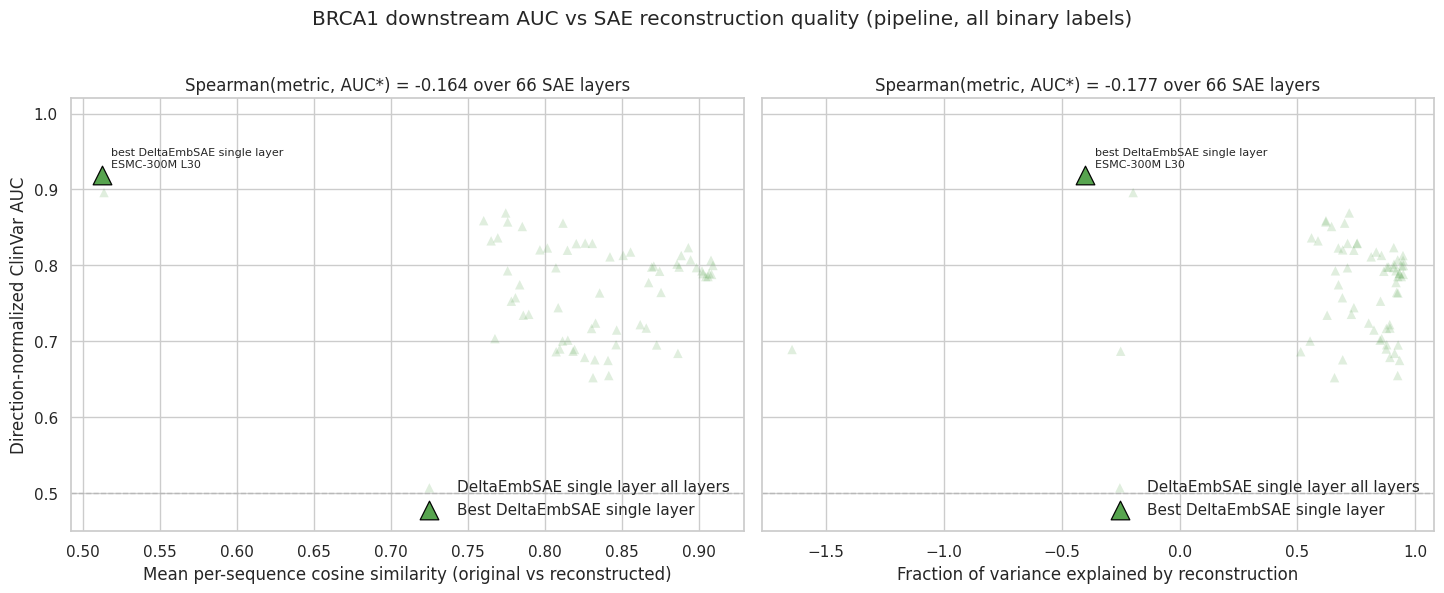

/net/dali/home/barton/dhw28/popDMS/esmDMS/data/clinprotgym_esmc_sae/datasets/MV_BRCA1_Findlay_2018/figures/brca1_sae_downstream/MV_BRCA1_Findlay_2018_auc_vs_sae_reconstruction_metrics_pipeline.png


In [28]:
plt, sns = ensure_plotting()

if model_diagnostics.empty:
    print("No diagnostics to plot. Run the diagnostics cell first.")
else:
    sae_df = model_diagnostics[model_diagnostics["method_family"].eq("Raw SAE")].copy()
    sae_df = sae_df[np.isfinite(sae_df["auc_discrimination"])].copy()
    if sae_df.empty:
        print("No SAE rows with finite AUC.")
    else:
        color = method_color("Raw SAE")
        marker = method_marker("Raw SAE")
        label_base = method_label("Raw SAE")
        metric_specs = [
            ("mean_cosine_similarity", "Mean per-sequence cosine similarity (original vs reconstructed)"),
            ("fraction_variance_explained", "Fraction of variance explained by reconstruction"),
        ]

        fig, axes = plt.subplots(1, 2, figsize=(14.6, 5.8), sharey=True)
        for ax, (metric, xlabel) in zip(axes, metric_specs):
            panel = sae_df[np.isfinite(sae_df[metric])].copy()
            if panel.empty:
                ax.text(0.5, 0.5, f"No finite {metric} values", ha="center", va="center", transform=ax.transAxes)
                ax.set_xlabel(xlabel)
                continue

            nonbest = panel[~panel["is_best"]]
            if not nonbest.empty:
                ax.scatter(
                    nonbest[metric], nonbest["auc_discrimination"],
                    s=46, marker=marker, color=color, alpha=0.18, edgecolor="none",
                    label=f"{label_base} all layers", zorder=2,
                )
            best = panel[panel["is_best"]]
            if not best.empty:
                ax.scatter(
                    best[metric], best["auc_discrimination"],
                    s=180, marker=marker, color=color, alpha=0.98, edgecolor="black", linewidth=0.9,
                    label=f"Best {label_base}", zorder=6,
                )
                for _, row in best.iterrows():
                    layer_text = "" if pd.isna(row.get("layer")) else f" L{int(row['layer'])}"
                    ax.annotate(
                        f"best {label_base}\n{row.get('model_short', '')}{layer_text}",
                        (row[metric], row["auc_discrimination"]),
                        xytext=(7, 6), textcoords="offset points", fontsize=8, color="0.15",
                    )

            rho = spearmanr(panel[metric], panel["auc_discrimination"]).statistic if len(panel) >= 3 else np.nan
            ax.axhline(0.5, color="0.72", linewidth=1, linestyle="--", zorder=1)
            ax.set_xlabel(xlabel)
            ax.set_title(f"Spearman(metric, AUC*) = {rho:.3f} over {len(panel)} SAE layers")
            ax.legend(frameon=False, loc="lower right")

        axes[0].set_ylabel("Direction-normalized ClinVar AUC")
        axes[0].set_ylim(0.45, 1.02)
        cutoff_label = "all binary labels" if DIAGNOSTIC_REVIEW_STAR_CUTOFF == 0 else f">={DIAGNOSTIC_REVIEW_STAR_CUTOFF} review stars"
        fig.suptitle(f"BRCA1 downstream AUC vs SAE reconstruction quality ({CLINICAL_LABEL_MODE}, {cutoff_label})", y=1.02)
        fig.tight_layout()
        out = FIGURE_DIR / f"{DATASET}_auc_vs_sae_reconstruction_metrics_{CLINICAL_LABEL_MODE}.png"
        fig.savefig(out, dpi=300, bbox_inches="tight")
        plt.show()
        print(out)


## Plot: AUC Versus Cross-Replicate Consistency

Cross-replicate consistency (mean pairwise Pearson r between the per-replicate popDMS selection vectors each model produces) against direction-normalized ClinVar AUC, for every raw ESM-C layer and every DeltaEmbSAE layer. Best layers per family are opaque, the rest transparent. The popDMS baseline is drawn as its own point since it reports both quantities, and the LLR baseline appears as a dotted AUC guide line.


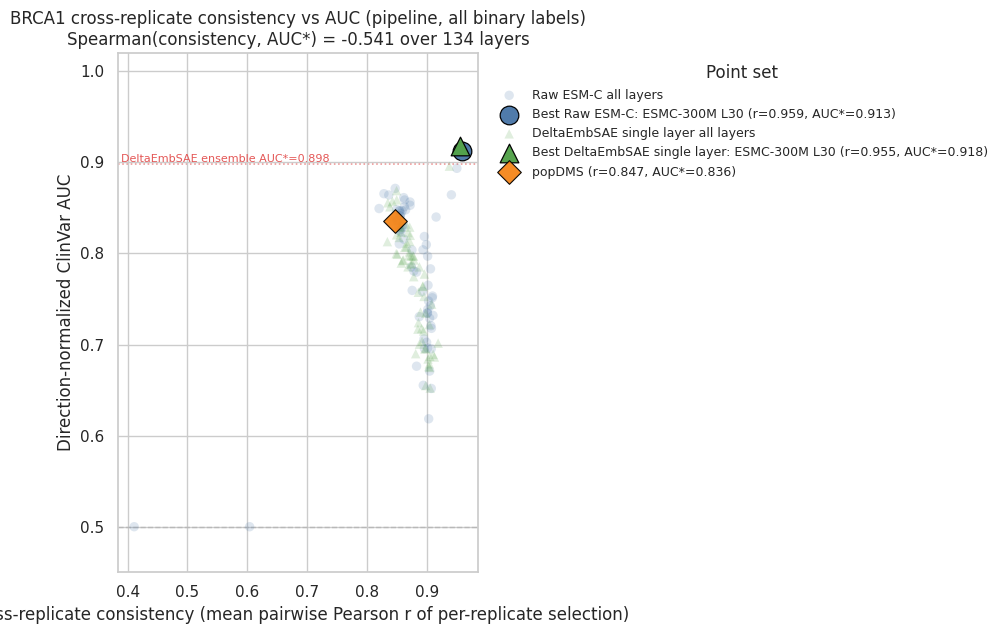

/net/dali/home/barton/dhw28/popDMS/esmDMS/data/clinprotgym_esmc_sae/datasets/MV_BRCA1_Findlay_2018/figures/brca1_sae_downstream/MV_BRCA1_Findlay_2018_auc_vs_cross_replicate_consistency_pipeline.png


cross_replicate_consistency                      \
                                               count    median       max   
method_plot_label                                                          
DeltaEmbSAE single layer                          66  0.878112  0.955238   
Raw ESM-C                                         68  0.880566  0.958673   

                         auc_discrimination                      
                                      count    median       max  
method_plot_label                                                
DeltaEmbSAE single layer                 66  0.789338  0.918415  
Raw ESM-C                                68  0.806862  0.912645

In [29]:
plt, sns = ensure_plotting()

if model_diagnostics.empty:
    print("No diagnostics to plot. Run the diagnostics cell first.")
else:
    consistency_df = model_diagnostics[
        np.isfinite(model_diagnostics["cross_replicate_consistency"])
        & np.isfinite(model_diagnostics["auc_discrimination"])
    ].copy()
    if consistency_df.empty:
        print("No models with a finite cross-replicate consistency. Check that the inference pickles exist.")
    else:
        fig, ax = plt.subplots(figsize=(9.8, 6.5))

        for family in ["Raw embeddings", "Raw SAE"]:
            group = consistency_df[consistency_df["method_family"].eq(family)]
            if group.empty:
                continue
            color = method_color(family)
            marker = method_marker(family)
            label_base = method_label(family)
            nonbest = group[~group["is_best"]]
            if not nonbest.empty:
                ax.scatter(
                    nonbest["cross_replicate_consistency"], nonbest["auc_discrimination"],
                    s=46, marker=marker, color=color, alpha=0.18, edgecolor="none",
                    label=f"{label_base} all layers", zorder=2,
                )
            # Best points of the two families sit almost on top of each other, so name them in the legend.
            for _, row in group[group["is_best"]].iterrows():
                layer_text = "" if pd.isna(row.get("layer")) else f" L{int(row['layer'])}"
                ax.scatter(
                    row["cross_replicate_consistency"], row["auc_discrimination"],
                    s=180, marker=marker, color=color, alpha=0.98, edgecolor="black", linewidth=0.9,
                    label=f"Best {label_base}: {row.get('model_short', '')}{layer_text} (r={row['cross_replicate_consistency']:.3f}, AUC*={row['auc_discrimination']:.3f})",
                    zorder=6,
                )

        cutoff_rows = auc_by_labels[auc_by_labels["min_review_stars"].eq(DIAGNOSTIC_REVIEW_STAR_CUTOFF)].copy()
        cutoff_rows["auc_discrimination"] = safe_numeric(cutoff_rows["auc_discrimination"])

        popdms = cutoff_rows[cutoff_rows["method_family"].eq("popDMS baseline")].copy()
        if not popdms.empty and "mean_pairwise_pearson_r" in popdms.columns:
            popdms["mean_pairwise_pearson_r"] = safe_numeric(popdms["mean_pairwise_pearson_r"])
            popdms = popdms[np.isfinite(popdms["mean_pairwise_pearson_r"]) & np.isfinite(popdms["auc_discrimination"])]
            for _, row in popdms.iterrows():
                ax.scatter(
                    row["mean_pairwise_pearson_r"], row["auc_discrimination"],
                    s=145, marker=method_marker("popDMS baseline"), color=method_color("popDMS baseline"),
                    alpha=0.94, edgecolor="black", linewidth=0.8, zorder=5,
                    label=f"{method_label('popDMS baseline')} (r={row['mean_pairwise_pearson_r']:.3f}, AUC*={row['auc_discrimination']:.3f})",
                )

        guide_df = cutoff_rows[cutoff_rows["method_family"].isin(["LLR baseline", "Ensemble SAE model"])].copy()
        guide_df = (
            guide_df[np.isfinite(guide_df["auc_discrimination"])]
            .sort_values("auc_discrimination", ascending=False)
            .drop_duplicates("method_family")
        )
        for _, row in guide_df.iterrows():
            family = row["method_family"]
            y = row["auc_discrimination"]
            ax.axhline(y, color=method_color(family), linestyle=":", linewidth=1.15, alpha=0.65, zorder=0)
            ax.text(
                0.01, y, f"{method_label(family)} AUC*={y:.3f}",
                transform=ax.get_yaxis_transform(), va="bottom", ha="left", fontsize=8, color=method_color(family),
            )

        rho = (
            spearmanr(consistency_df["cross_replicate_consistency"], consistency_df["auc_discrimination"]).statistic
            if len(consistency_df) >= 3 else np.nan
        )
        ax.axhline(0.5, color="0.72", linewidth=1, linestyle="--", zorder=1)
        ax.set_ylim(0.45, 1.02)
        ax.set_xlabel("Cross-replicate consistency (mean pairwise Pearson r of per-replicate selection)")
        ax.set_ylabel("Direction-normalized ClinVar AUC")
        cutoff_label = "all binary labels" if DIAGNOSTIC_REVIEW_STAR_CUTOFF == 0 else f">={DIAGNOSTIC_REVIEW_STAR_CUTOFF} review stars"
        ax.set_title(
            f"BRCA1 cross-replicate consistency vs AUC ({CLINICAL_LABEL_MODE}, {cutoff_label})\n"
            f"Spearman(consistency, AUC*) = {rho:.3f} over {len(consistency_df)} layers"
        )

        handles, labels = ax.get_legend_handles_labels()
        seen = set()
        dedup_handles, dedup_labels = [], []
        for handle, label in zip(handles, labels):
            if label in seen or label == "":
                continue
            seen.add(label)
            dedup_handles.append(handle)
            dedup_labels.append(label)
        ax.legend(dedup_handles, dedup_labels, title="Point set", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False, fontsize=9)

        fig.tight_layout()
        out = FIGURE_DIR / f"{DATASET}_auc_vs_cross_replicate_consistency_{CLINICAL_LABEL_MODE}.png"
        fig.savefig(out, dpi=300, bbox_inches="tight")
        plt.show()
        print(out)
        display(
            consistency_df.groupby("method_plot_label")[["cross_replicate_consistency", "auc_discrimination"]]
            .agg(["count", "median", "max"])
        )


## Plot: SAE Reconstruction Quality By Layer And ESM-C Model

Layer profile of the two reconstruction metrics, one line per ESM-C model. This is the control for the AUC-versus-reconstruction plots: downstream AUC tracks layer depth very strongly (Spearman ~0.94), so any pooled correlation between AUC and reconstruction quality is confounded by depth, and the two models have different layer counts. Best-by-AUC layers are marked.


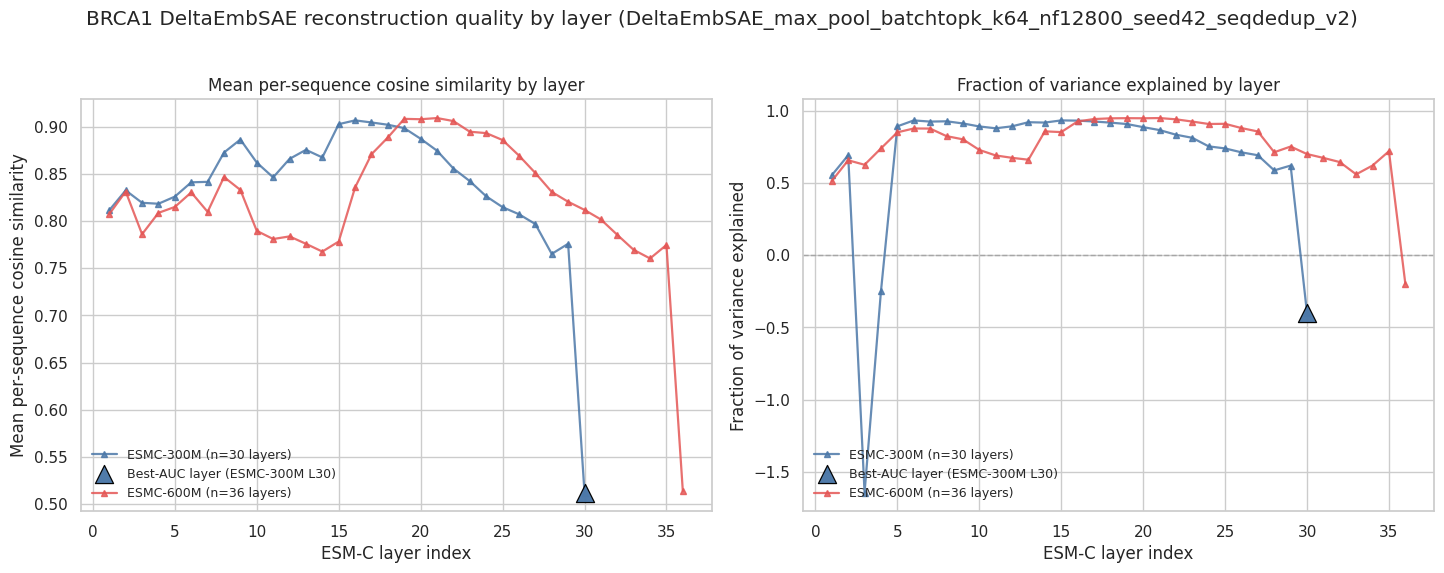

/net/dali/home/barton/dhw28/popDMS/esmDMS/data/clinprotgym_esmc_sae/datasets/MV_BRCA1_Findlay_2018/figures/brca1_sae_downstream/MV_BRCA1_Findlay_2018_sae_reconstruction_by_layer.png


mean_cosine_similarity                                \
                             count       min    median       max   
model_short                                                        
ESMC-300M                       30  0.512213  0.844286  0.906685   
ESMC-600M                       36  0.513796  0.817679  0.909147   

            fraction_variance_explained                                \
                                  count       min    median       max   
model_short                                                             
ESMC-300M                            30 -1.644001  0.882879  0.933495   
ESMC-600M                            36 -0.196854  0.813558  0.949795   

            auc_discrimination                           
                         count  min    median       max  
model_short                                              
ESMC-300M                   31  0.5  0.785285  0.918415  
ESMC-600M                   37  0.5  0.792867  0.895909

In [30]:
plt, sns = ensure_plotting()

MODEL_COLORS = {"ESMC-300M": "#4C78A8", "ESMC-600M": "#E45756"}

def model_color(value):
    return MODEL_COLORS.get(str(value), "0.4")

if model_diagnostics.empty:
    print("No diagnostics to plot. Run the diagnostics cell first.")
else:
    recon_df = model_diagnostics[model_diagnostics["method_family"].eq("Raw SAE")].copy()
    recon_df["layer"] = safe_numeric(recon_df["layer"])
    recon_df = recon_df[np.isfinite(recon_df["layer"])].copy()
    if recon_df.empty:
        print("No SAE rows with a layer index.")
    else:
        metric_specs = [
            ("mean_cosine_similarity", "Mean per-sequence cosine similarity", None),
            ("fraction_variance_explained", "Fraction of variance explained", 0.0),
        ]
        fig, axes = plt.subplots(1, 2, figsize=(14.6, 5.6), sharex=True)
        for ax, (metric, ylabel, refline) in zip(axes, metric_specs):
            for model_short, group in recon_df.groupby("model_short", sort=True):
                group = group[np.isfinite(group[metric])].sort_values("layer")
                if group.empty:
                    continue
                color = model_color(model_short)
                ax.plot(group["layer"], group[metric], color=color, alpha=0.85, linewidth=1.6, marker="^", markersize=5, label=f"{model_short} (n={len(group)} layers)")
                best = group[group["is_best"]]
                if not best.empty:
                    ax.scatter(
                        best["layer"], best[metric],
                        s=170, marker="^", color=color, alpha=0.98, edgecolor="black", linewidth=0.9, zorder=6,
                        label=f"Best-AUC layer ({model_short} L{int(best.iloc[0]['layer'])})",
                    )
            if refline is not None:
                ax.axhline(refline, color="0.65", linewidth=1, linestyle="--", zorder=1)
            ax.set_xlabel("ESM-C layer index")
            ax.set_ylabel(ylabel)
            ax.set_title(f"{ylabel} by layer")
            ax.legend(frameon=False, fontsize=9, loc="lower left")

        fig.suptitle(f"BRCA1 DeltaEmbSAE reconstruction quality by layer ({RUN_LABEL})", y=1.02)
        fig.tight_layout()
        out = FIGURE_DIR / f"{DATASET}_sae_reconstruction_by_layer.png"
        fig.savefig(out, dpi=300, bbox_inches="tight")
        plt.show()
        print(out)
        display(
            recon_df.groupby("model_short")[["mean_cosine_similarity", "fraction_variance_explained", "auc_discrimination"]]
            .agg(["count", "min", "median", "max"])
        )


## Voting Ensembles From Model-Specific Pathogenicity Calls

Each raw ESM-C or DeltaEmbSAE layer orients `-fitness` so its all-binary ClinVar AUC is at least 0.5, then chooses a binary cutoff by maximum Youden's J (sensitivity minus false-positive rate). Those fixed 0/1 calls are averaged for the top 5, 9, 13, 17, 21, and 25 models by Spearman rho. Three searches are run: SAE only, raw embeddings only, and both families together.

Five targeted combined-family variants are also evaluated: top 3; top 3 plus both ESM-C 300M/600M LLR votes; top 3 plus ESM-C 600M LLR and popDMS; top 5 plus ESM-C 600M LLR and popDMS; and top 4 plus both ESM-C 300M/600M LLR votes and popDMS. Every added baseline gets its own AUC orientation and Youden cutoff. The all-binary labels fit each model's cutoff once; review-star panels only re-evaluate the fixed calls.


In [31]:
from scipy.stats import spearmanr

VOTING_TOP_NS = [5, 9, 13, 17, 21, 25]
VOTING_POOLS = {
    "SAE only": ["Raw SAE"],
    "Raw embeddings only": ["Raw embeddings"],
    "Raw + SAE": ["Raw embeddings", "Raw SAE"],
}
TARGETED_VOTING_SPECS = [
    ("Both top 3", 3, []),
    ("Both top 3 + 300M LLR + 600M LLR", 3, ["LLR ESMC-300M", "LLR ESMC-600M"]),
    ("Both top 3 + 600M LLR + popDMS", 3, ["LLR ESMC-600M", "popDMS"]),
    ("Both top 5 + 600M LLR + popDMS", 5, ["LLR ESMC-600M", "popDMS"]),
    ("Both top 4 + 300M LLR + 600M LLR + popDMS", 4, ["LLR ESMC-300M", "LLR ESMC-600M", "popDMS"]),
]
VOTING_TABLE_DIR = TABLE_DIR / "voting_ensembles"
WRITE_VOTING_TABLES = True


def score_auc(scores, labels):
    scores = safe_numeric(pd.Series(scores)).to_numpy(dtype=float)
    labels = pd.Series(labels).astype(bool).to_numpy()
    keep = np.isfinite(scores)
    scores, labels = scores[keep], labels[keep]
    n_pos, n_neg = int(labels.sum()), int((~labels).sum())
    if not n_pos or not n_neg:
        return np.nan
    ranks = pd.Series(scores).rank(method="average").to_numpy()
    return float((ranks[labels].sum() - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg))


def youden_cutoff(scores, labels):
    table = pd.DataFrame({"score": safe_numeric(pd.Series(scores)), "positive": pd.Series(labels).astype(bool)})
    table = table[np.isfinite(table["score"])]
    n_pos, n_neg = int(table["positive"].sum()), int((~table["positive"]).sum())
    if not n_pos or not n_neg:
        return np.nan
    grouped = table.groupby("score")["positive"].agg(positive="sum", total="size").sort_index(ascending=False)
    youden = grouped["positive"].cumsum() / n_pos - (grouped["total"] - grouped["positive"]).cumsum() / n_neg
    return float(youden.idxmax())


def classify_for_voting(row):
    joined = fitness_with_active_labels(row["fitness_path"], min_stars=0)
    joined["raw_pathogenicity_score"] = -safe_numeric(joined.get("fitness", np.nan))
    train = joined[joined["annotation"].isin(PATHOGENICITY_LABELS)].dropna(subset=["raw_pathogenicity_score"])
    labels = train["annotation"].eq("pathogenic")
    raw_auc = score_auc(train["raw_pathogenicity_score"], labels)
    if not np.isfinite(raw_auc):
        return pd.DataFrame(), None
    direction = 1.0 if raw_auc >= 0.5 else -1.0
    cutoff = youden_cutoff(direction * train["raw_pathogenicity_score"], labels)
    if not np.isfinite(cutoff):
        return pd.DataFrame(), None
    calls = joined[["SequenceIndex"]].copy()
    calls["SequenceIndex"] = calls["SequenceIndex"].astype(str)
    calls["pathogenicity_score"] = direction * joined["raw_pathogenicity_score"]
    calls = calls[np.isfinite(calls["pathogenicity_score"])].copy()
    calls["pathogenic_vote"] = calls["pathogenicity_score"].ge(cutoff).astype(int)
    for column in ["voting_model_id", "method_family", "model_label", "model_short", "layer", "spearman_rho", "fitness_path"]:
        calls[column] = row.get(column, np.nan)
    calls["model_auc"] = raw_auc
    calls["auc_direction"] = direction
    calls["youden_cutoff"] = cutoff
    metadata = {column: row.get(column, np.nan) for column in ["voting_model_id", "method_family", "model_label", "model_short", "layer", "spearman_rho", "fitness_path"]}
    metadata.update(model_auc=raw_auc, auc_discrimination=max(raw_auc, 1 - raw_auc), auc_direction=direction, youden_cutoff=cutoff, n_classified_variants=len(calls))
    return calls, metadata


def voting_stats(predictions, target_scores):
    scored = predictions[["SequenceIndex", "vote_fraction"]].copy()
    scored["fitness"] = -scored["vote_fraction"]
    merged = scored.merge(target_scores, on="SequenceIndex", how="inner")
    keep = np.isfinite(merged["fitness"]) & np.isfinite(merged["score"])
    rho = spearmanr(merged.loc[keep, "fitness"], merged.loc[keep, "score"]).statistic if keep.sum() >= 3 else np.nan
    labels = normalize_label_columns(active_labels.copy())
    labels["SequenceIndex"] = labels["SequenceIndex"].astype(str)
    rows = []
    for min_stars in [0, 1, 2, 3]:
        cutoff_labels = labels[labels["stars"].ge(min_stars) & labels["annotation"].isin(PATHOGENICITY_LABELS)][["SequenceIndex", "annotation", "stars"]]
        evaluated = scored.merge(cutoff_labels, on="SequenceIndex", how="left")
        rows.append({"min_review_stars": min_stars, "spearman_rho": rho, **auc_from_labeled_fitness(evaluated)})
    return rows


voting_candidates = metrics[metrics["method_family"].isin(["Raw embeddings", "Raw SAE"])].copy()
voting_candidates["spearman_rho"] = safe_numeric(voting_candidates["spearman_rho"])
voting_candidates = voting_candidates[np.isfinite(voting_candidates["spearman_rho"])]
voting_candidates = voting_candidates[voting_candidates["fitness_path"].map(lambda path: Path(str(path)).is_file())]
voting_candidates = voting_candidates.sort_values("spearman_rho", ascending=False).drop_duplicates("fitness_path")
voting_candidates["voting_model_id"] = voting_candidates["method_family"].astype(str) + " | " + voting_candidates["model_label"].astype(str) + " | " + voting_candidates["fitness_path"].astype(str)

target_scores = load_dataset_state()["scores_dataframe"][["SequenceIndex", "score"]].copy()
target_scores["SequenceIndex"] = target_scores["SequenceIndex"].astype(str)
target_scores["score"] = safe_numeric(target_scores["score"])


def rho_for_fitness_path(fitness_path):
    fitness = read_csv(fitness_path)
    if fitness.empty or not {"SequenceIndex", "fitness"}.issubset(fitness.columns):
        return np.nan
    fitness = fitness[["SequenceIndex", "fitness"]].copy()
    fitness["SequenceIndex"] = fitness["SequenceIndex"].astype(str)
    merged = fitness.merge(target_scores, on="SequenceIndex", how="inner")
    keep = np.isfinite(safe_numeric(merged["fitness"])) & np.isfinite(merged["score"])
    return float(spearmanr(safe_numeric(merged.loc[keep, "fitness"]), merged.loc[keep, "score"]).statistic) if keep.sum() >= 3 else np.nan


external_rows = []
popdms = metrics[metrics["method_family"].eq("popDMS baseline")].sort_values("spearman_rho", ascending=False).head(1)
if not popdms.empty:
    row = popdms.iloc[0].to_dict()
    row.update(voting_model_id="external | popDMS", voting_component_label="popDMS")
    external_rows.append(row)
for llr_path in sorted(TABLE_DIR.glob(f"{DATASET}_*_llr_fitness.csv")):
    model_short = "ESMC-600M" if "600M" in llr_path.name else "ESMC-300M"
    label = f"LLR {model_short}"
    external_rows.append({
        "voting_model_id": f"external | {label}", "voting_component_label": label,
        "method_family": "LLR baseline", "model_label": label, "model_short": model_short,
        "layer": np.nan, "spearman_rho": rho_for_fitness_path(llr_path), "fitness_path": str(llr_path),
    })
external_candidates = pd.DataFrame(external_rows)

call_frames, threshold_rows = [], []
for _, candidate in pd.concat([voting_candidates, external_candidates], ignore_index=True, sort=False).iterrows():
    calls, threshold = classify_for_voting(candidate)
    if not calls.empty:
        call_frames.append(calls)
        threshold_rows.append(threshold)
voting_model_calls = pd.concat(call_frames, ignore_index=True) if call_frames else pd.DataFrame()
voting_model_thresholds = pd.DataFrame(threshold_rows)

prediction_frames, metric_rows, selection_rows = [], [], []
classifiable_ids = set(voting_model_thresholds.get("voting_model_id", []))
for pool, families in VOTING_POOLS.items():
    ranked = voting_candidates[voting_candidates["method_family"].isin(families) & voting_candidates["voting_model_id"].isin(classifiable_ids)]
    for top_n in VOTING_TOP_NS:
        selected = ranked.head(top_n)
        if len(selected) < top_n:
            print(f"Skipping {pool} top {top_n}: only {len(selected)} classifiable models")
            continue
        for rank, (_, model) in enumerate(selected.iterrows(), 1):
            selection_rows.append({"ensemble_pool": pool, "top_n": top_n, "rank": rank, **model.to_dict()})
        votes = voting_model_calls[voting_model_calls["voting_model_id"].isin(selected["voting_model_id"])]
        predictions = votes.groupby("SequenceIndex", as_index=False)["pathogenic_vote"].agg(vote_fraction="mean", n_votes="size")
        predictions = predictions[predictions["n_votes"].eq(top_n)].copy()
        predictions["ensemble_pool"], predictions["top_n"] = pool, top_n
        predictions["ensemble_label"] = f"{pool} top {top_n}"
        predictions["n_constituent_models"] = top_n
        prediction_frames.append(predictions)
        for stats in voting_stats(predictions, target_scores):
            metric_rows.append({"method_family": "Voting ensemble", "ensemble_pool": pool, "ensemble_label": f"{pool} top {top_n}", "top_n": top_n, "n_constituent_models": top_n, **stats})

combined_ranked = voting_candidates[voting_candidates["method_family"].isin(VOTING_POOLS["Raw + SAE"]) & voting_candidates["voting_model_id"].isin(classifiable_ids)]
external_by_label = {row["voting_component_label"]: row for _, row in external_candidates[external_candidates["voting_model_id"].isin(classifiable_ids)].iterrows()}
for ensemble_label, base_top_n, extra_labels in TARGETED_VOTING_SPECS:
    base = combined_ranked.head(base_top_n)
    missing = [label for label in extra_labels if label not in external_by_label]
    if len(base) < base_top_n or missing:
        print(f"Skipping {ensemble_label}: missing {missing or 'combined candidates'}")
        continue
    selected_rows = [row for _, row in base.iterrows()] + [external_by_label[label] for label in extra_labels]
    selected_ids = [row["voting_model_id"] for row in selected_rows]
    total_votes = len(selected_ids)
    for rank, model in enumerate(selected_rows, 1):
        selection_rows.append({"ensemble_pool": "Targeted combinations", "ensemble_label": ensemble_label, "top_n": base_top_n, "n_constituent_models": total_votes, "rank": rank, **model.to_dict()})
    votes = voting_model_calls[voting_model_calls["voting_model_id"].isin(selected_ids)]
    predictions = votes.groupby("SequenceIndex", as_index=False)["pathogenic_vote"].agg(vote_fraction="mean", n_votes="size")
    predictions = predictions[predictions["n_votes"].eq(total_votes)].copy()
    predictions["ensemble_pool"] = "Targeted combinations"
    predictions["ensemble_label"] = ensemble_label
    predictions["top_n"] = base_top_n
    predictions["n_constituent_models"] = total_votes
    prediction_frames.append(predictions)
    for stats in voting_stats(predictions, target_scores):
        metric_rows.append({"method_family": "Voting ensemble", "ensemble_pool": "Targeted combinations", "ensemble_label": ensemble_label, "top_n": base_top_n, "n_constituent_models": total_votes, **stats})

voting_ensemble_predictions = pd.concat(prediction_frames, ignore_index=True) if prediction_frames else pd.DataFrame()
voting_ensemble_metrics = pd.DataFrame(metric_rows)
voting_ensemble_selections = pd.DataFrame(selection_rows)

if WRITE_VOTING_TABLES and not voting_model_calls.empty:
    VOTING_TABLE_DIR.mkdir(parents=True, exist_ok=True)
    for name, table in {
        "model_pathogenicity_calls": voting_model_calls,
        "model_pathogenicity_thresholds": voting_model_thresholds,
        "voting_ensemble_selections": voting_ensemble_selections,
        "voting_ensemble_predictions": voting_ensemble_predictions,
        "voting_ensemble_metrics": voting_ensemble_metrics,
    }.items():
        table.to_csv(VOTING_TABLE_DIR / f"{DATASET}_{name}.csv", index=False)
    print(f"Voting tables: {VOTING_TABLE_DIR}")
     
print(f"Classified {len(voting_model_thresholds)} models; created {len(voting_ensemble_metrics) // 4} voting ensembles")
display(voting_model_thresholds.sort_values(["method_family", "spearman_rho"], ascending=[True, False]).head(12))
display(voting_ensemble_metrics)


Voting tables: /net/dali/home/barton/dhw28/popDMS/esmDMS/data/clinprotgym_esmc_sae/datasets/MV_BRCA1_Findlay_2018/tables/voting_ensembles
Classified 141 models; created 23 voting ensembles


,voting_model_id,method_family,model_label,model_short,layer,spearman_rho,fitness_path,model_auc,auc_discrimination,auc_direction,youden_cutoff,n_classified_variants
137,external | LLR ESMC-600M,LLR baseline,LLR ESMC-600M,ESMC-600M,NaN,0.547514,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,0.946119,0.946119,1.0,8.218160,1837
133,external | LLR ESMC-600M,LLR baseline,LLR ESMC-600M,ESMC-600M,NaN,0.546532,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,0.946500,0.946500,1.0,6.314794,1837
139,external | LLR ESMC-600M,LLR baseline,LLR ESMC-600M,ESMC-600M,NaN,0.545757,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,0.945499,0.945499,1.0,0.506781,1837
135,external | LLR ESMC-600M,LLR baseline,LLR ESMC-600M,ESMC-600M,NaN,0.544958,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,0.949647,0.949647,1.0,8.100884,1837
140,external | LLR ESMC-600M,LLR baseline,LLR ESMC-600M,ESMC-600M,NaN,0.540398,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,0.938966,0.938966,1.0,0.680083,1837
138,external | LLR ESMC-600M,LLR baseline,LLR ESMC-600M,ESMC-600M,NaN,0.538416,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,0.944021,0.944021,1.0,0.152355,1837
136,external | LLR ESMC-600M,LLR baseline,LLR ESMC-600M,ESMC-600M,NaN,0.527581,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,0.936582,0.936582,1.0,5.616465,1837
134,external | LLR ESMC-300M,LLR baseline,LLR ESMC-300M,ESMC-300M,NaN,0.516038,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,0.925234,0.925234,1.0,4.430172,1837
0,Raw SAE | ESMC-300M Layer_30 DeltaEmbSAE_max_p...,Raw SAE,ESMC-300M Layer_30 DeltaEmbSAE_max_pool_batcht...,ESMC-300M,30.0,0.502812,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,0.918415,0.918415,1.0,-0.999600,1837
2,Raw SAE | ESMC-600M Layer_36 DeltaEmbSAE_max_p...,Raw SAE,ESMC-600M Layer_36 DeltaEmbSAE_max_pool_batcht...,ESMC-600M,36.0,0.493864,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,0.895909,0.895909,1.0,-0.999763,1837


,method_family,ensemble_pool,ensemble_label,top_n,n_constituent_models,min_review_stars,spearman_rho,auc,auc_discrimination,n_benign,n_pathogenic,n_variants
0,Voting ensemble,SAE only,SAE only top 5,5,5,0,0.541250,0.925353,0.925353,107,196,303
1,Voting ensemble,SAE only,SAE only top 5,5,5,1,0.541250,0.934208,0.934208,106,192,298
2,Voting ensemble,SAE only,SAE only top 5,5,5,2,0.541250,0.950915,0.950915,19,141,160
3,Voting ensemble,SAE only,SAE only top 5,5,5,3,0.541250,0.943915,0.943915,15,63,78
4,Voting ensemble,SAE only,SAE only top 9,9,9,0,0.523763,0.919083,0.919083,107,196,303
...,...,...,...,...,...,...,...,...,...,...,...,...
87,Voting ensemble,Targeted combinations,Both top 5 + 600M LLR + popDMS,5,7,3,NaN,NaN,NaN,0,0,0
88,Voting ensemble,Targeted combinations,Both top 4 + 300M LLR + 600M LLR + popDMS,4,7,0,NaN,NaN,NaN,0,0,0
89,Voting ensemble,Targeted combinations,Both top 4 + 300M LLR + 600M LLR + popDMS,4,7,1,NaN,NaN,NaN,0,0,0
90,Voting ensemble,Targeted combinations,Both top 4 + 300M LLR + 600M LLR + popDMS,4,7,2,NaN,NaN,NaN,0,0,0


In [32]:
llr_prior_popdms_sweeps = {}
llr_prior_popdms_fitness_by_model = {}
llr_prior_popdms_metric_frames = []
for prior_model, llr_path in LLR_PRIOR_POPDMS_MODELS.items():
    sweep, fitness_by_gamma, metric_frame = run_llr_prior_popdms(prior_model, llr_path)
    llr_prior_popdms_sweeps[prior_model] = sweep
    llr_prior_popdms_fitness_by_model[prior_model] = fitness_by_gamma
    llr_prior_popdms_metric_frames.append(metric_frame)

llr_prior_popdms_metrics = pd.concat(llr_prior_popdms_metric_frames, ignore_index=True)
display(llr_prior_popdms_metrics.sort_values(["min_review_stars", "prior_model", "optimization"]))


,benchmark,prior_model,optimization,min_review_stars,gamma,spearman_rho,auc,auc_discrimination,cross_replicate_consistency,n_benign,n_pathogenic
0,LLR-prior popDMS,ESM-C 300M,ClinVar AUC,0,0.000100,0.643025,0.932720,0.932720,0.937341,107,196
1,LLR-prior popDMS,ESM-C 300M,cross-replicate consistency,0,0.000172,0.612897,0.927046,0.927046,0.957649,107,196
8,LLR-prior popDMS,ESM-C 600M,ClinVar AUC,0,2.955209,0.544974,0.949647,0.949647,1.000000,107,196
9,LLR-prior popDMS,ESM-C 600M,cross-replicate consistency,0,0.000100,0.663446,0.947788,0.947788,0.938349,107,196
2,LLR-prior popDMS,ESM-C 300M,ClinVar AUC,1,0.000100,0.643025,0.943544,0.943544,0.937341,106,192
3,LLR-prior popDMS,ESM-C 300M,cross-replicate consistency,1,0.000172,0.612897,0.936124,0.936124,0.957649,106,192
10,LLR-prior popDMS,ESM-C 600M,ClinVar AUC,1,0.000100,0.663446,0.959316,0.959316,0.938349,106,192
11,LLR-prior popDMS,ESM-C 600M,cross-replicate consistency,1,0.000100,0.663446,0.959316,0.959316,0.938349,106,192
4,LLR-prior popDMS,ESM-C 300M,ClinVar AUC,2,0.066608,0.515610,0.926838,0.926838,0.999764,19,141
5,LLR-prior popDMS,ESM-C 300M,cross-replicate consistency,2,0.000172,0.612897,0.923852,0.923852,0.957649,19,141


## Plot: Spearman Versus AUC By ClinVar Review-Star Cutoff

The Spearman-versus-AUC scatter repeated at four ClinVar review-star cutoffs (>=0, >=1, >=2, >=3 stars). Everything is recomputed per panel: the AUC of every layer, the best raw ESM-C and best DeltaEmbSAE layer, the DMS-score / LLR guide lines, and the SAE-only, raw-only, and combined voting ensembles. Spearman rho is unchanged across panels (it is scored against the DMS functional score, not the clinical labels), so the points move only along the y-axis as the label set gets stricter and smaller. Voting-ensemble points are connected within each search pool and labeled by N.

The LLR baselines are drawn as points as well as AUC guide lines. Their Spearman rho is computed here from the `*_llr_fitness.csv` tables against the DMS functional score, using the same procedure as the pipeline's collected rows, so it is comparable to every other point. The four LLR-prior popDMS points show ESM-C 300M and 600M priors with gamma selected either for the panel's ClinVar AUC or for cross-replicate consistency.


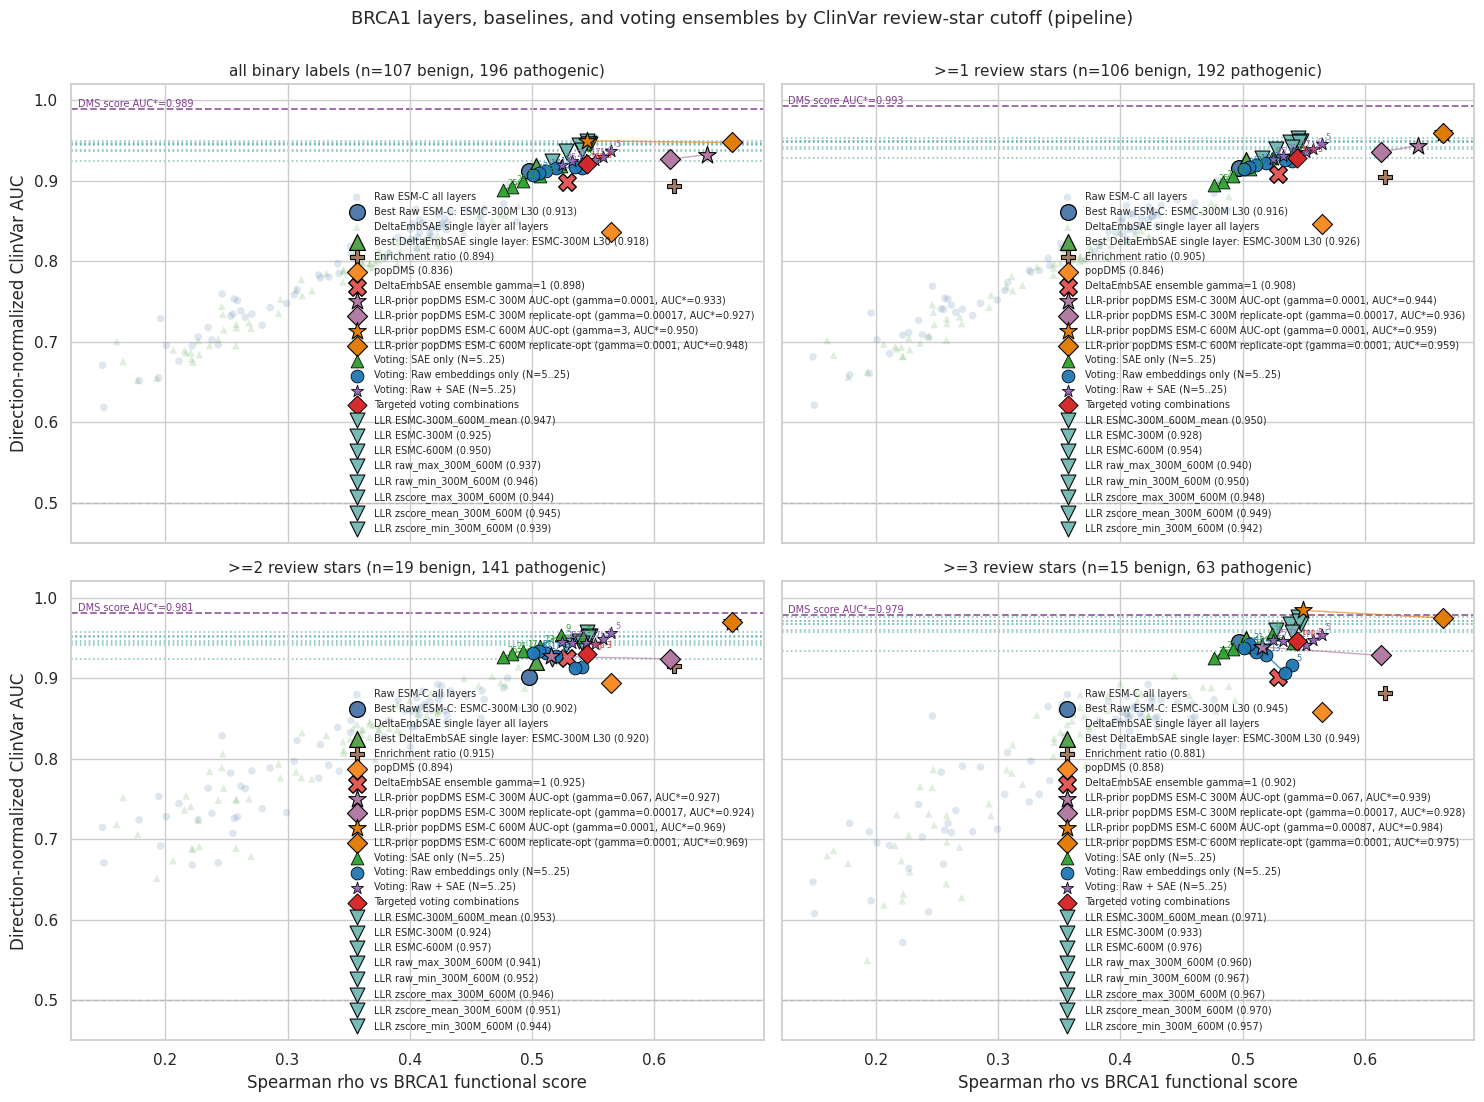

/net/dali/home/barton/dhw28/popDMS/esmDMS/data/clinprotgym_esmc_sae/datasets/MV_BRCA1_Findlay_2018/figures/brca1_sae_downstream/MV_BRCA1_Findlay_2018_all_layers_spearman_vs_auc_by_review_stars_pipeline.png


,review_cutoff,rank,method,method_group,spearman_rho,auc_discrimination,n_benign,n_pathogenic
1,all binary,1,DMS score: DMS functional score,DMS score,1.000000,0.989319,107,196
16,all binary,2,LLR-prior popDMS ESM-C 600M AUC-opt,LLR-prior popDMS,0.544974,0.949647,107,196
8,all binary,3,LLR ESMC-600M,LLR,0.544958,0.949647,107,196
17,all binary,4,LLR-prior popDMS ESM-C 600M replicate-opt,LLR-prior popDMS,0.663446,0.947788,107,196
6,all binary,5,LLR ESMC-300M_600M_mean,LLR,0.546532,0.946500,107,196
10,all binary,6,LLR raw_min_300M_600M,LLR,0.547514,0.946119,107,196
12,all binary,7,LLR zscore_mean_300M_600M,LLR,0.545757,0.945499,107,196
11,all binary,8,LLR zscore_max_300M_600M,LLR,0.538416,0.944021,107,196
13,all binary,9,LLR zscore_min_300M_600M,LLR,0.540398,0.938966,107,196
30,all binary,10,Raw + SAE top 5,Voting ensemble,0.564634,0.936844,107,196


In [33]:
from scipy.stats import spearmanr

plt, sns = ensure_plotting()

GRID_STAR_CUTOFFS = [0, 1, 2, 3]

def spearman_target_scores():
    """The DMS functional score every method's Spearman rho is measured against."""
    state = load_dataset_state()
    scores = state["scores_dataframe"][["SequenceIndex", "score"]].copy()
    scores["SequenceIndex"] = scores["SequenceIndex"].astype(str)
    scores["score"] = safe_numeric(scores["score"])
    return scores.dropna(subset=["score"])

def spearman_vs_functional_score(fitness_path, scores):
    """Mirrors the pipeline's spearman_for_fitness so LLR rho is comparable to the collected rows."""
    fitness = read_csv(fitness_path)
    if fitness.empty or "SequenceIndex" not in fitness.columns or "fitness" not in fitness.columns:
        return np.nan
    fitness = fitness[["SequenceIndex", "fitness"]].copy()
    fitness["SequenceIndex"] = fitness["SequenceIndex"].astype(str)
    merged = fitness.merge(scores, on="SequenceIndex", how="inner")
    x = safe_numeric(merged["fitness"]).to_numpy(dtype=float)
    y = safe_numeric(merged["score"]).to_numpy(dtype=float)
    finite = np.isfinite(x) & np.isfinite(y)
    if finite.sum() < 3:
        return np.nan
    return float(spearmanr(x[finite], y[finite]).statistic)

def llr_rows_for_cutoff(panel_df, min_stars, scores):
    """LLR Spearman rho and AUC at a star cutoff, from benchmark rows if collected, else from the LLR fitness tables."""
    rows = panel_df[panel_df["method_family"].eq("LLR baseline")].copy()
    if not rows.empty:
        return [
            {
                "label": str(row.get("model_label") or row.get("model_short") or method_label("LLR baseline")),
                "spearman_rho": float(row["spearman_rho"]),
                "auc_discrimination": float(row["auc_discrimination"]),
            }
            for _, row in rows.iterrows()
        ]
    out = []
    for path in sorted(TABLE_DIR.glob(f"{DATASET}_*_llr_fitness.csv")):
        stats = auc_from_labeled_fitness(fitness_with_active_labels(path, min_stars=min_stars))
        if not np.isfinite(stats["auc_discrimination"]):
            continue
        model_tag = path.stem.replace(f"{DATASET}_", "").replace("_llr_fitness", "").split("__")[-1]
        out.append({
            "label": f"{method_label('LLR baseline')} {model_tag}",
            "spearman_rho": spearman_vs_functional_score(path, scores),  # label-independent, same at every cutoff
            "auc_discrimination": stats["auc_discrimination"],
        })
    return out

def draw_spearman_auc_panel(ax, min_stars, scores):
    panel_df = auc_by_labels[auc_by_labels["min_review_stars"].eq(min_stars)].copy()
    panel_df["spearman_rho"] = safe_numeric(panel_df.get("spearman_rho", np.nan))
    panel_df["auc_discrimination"] = safe_numeric(panel_df["auc_discrimination"])
    panel_df["layer"] = safe_numeric(panel_df.get("layer", np.nan))

    # Best-by-AUC rows are re-selected at each cutoff, so the highlighted layer can change between panels.
    panel_best = best_rows_by_family(metrics, auc_by_labels, min_stars=min_stars)
    panel_df["is_best"] = mark_best_rows(panel_df, panel_best)

    scatter_df = panel_df[panel_df["method_family"].isin(METHOD_ORDER)].copy()
    scatter_df = scatter_df[np.isfinite(scatter_df["spearman_rho"]) & np.isfinite(scatter_df["auc_discrimination"])].copy()
    if scatter_df.empty:
        ax.text(0.5, 0.5, f"No rows at >={min_stars} stars", ha="center", va="center", transform=ax.transAxes)
        return 0, 0

    layer_df = scatter_df[scatter_df["method_family"].isin(["Raw embeddings", "Raw SAE"])]
    baseline_df = scatter_df[scatter_df["method_family"].isin(["Enrichment ratio baseline", "popDMS baseline"])]
    ensemble_df = scatter_df[scatter_df["method_family"].eq("Ensemble SAE model")]

    for family, group in layer_df.groupby("method_family", sort=False):
        color = method_color(family)
        marker = method_marker(family)
        label_base = method_label(family)
        nonbest = group[~group["is_best"]]
        if not nonbest.empty:
            ax.scatter(
                nonbest["spearman_rho"], nonbest["auc_discrimination"],
                s=30, marker=marker, color=color, alpha=0.18, edgecolor="none",
                label=f"{label_base} all layers", zorder=2,
            )
        for _, row in group[group["is_best"]].iterrows():
            layer_text = "" if pd.isna(row.get("layer")) else f" L{int(row['layer'])}"
            model_text = str(row.get("model_short", "")).replace("nan", "")
            ax.scatter(
                row["spearman_rho"], row["auc_discrimination"],
                s=130, marker=marker, color=color, alpha=0.98, edgecolor="black", linewidth=0.9,
                label=f"Best {label_base}: {model_text}{layer_text} ({row['auc_discrimination']:.3f})", zorder=6,
            )

    for _, row in baseline_df.iterrows():
        family = row["method_family"]
        ax.scatter(
            row["spearman_rho"], row["auc_discrimination"],
            s=105, marker=method_marker(family), color=method_color(family),
            alpha=0.94, edgecolor="black", linewidth=0.8,
            label=f"{method_label(family)} ({row['auc_discrimination']:.3f})", zorder=5,
        )

    for _, row in ensemble_df.iterrows():
        family = row["method_family"]
        ax.scatter(
            row["spearman_rho"], row["auc_discrimination"],
            s=160, marker=method_marker(family), color=method_color(family),
            alpha=0.98, edgecolor="black", linewidth=1.0,
            label=f"{method_label(family)} gamma=1 ({row['auc_discrimination']:.3f})", zorder=8,
        )

    llr_popdms_styles = {
        "ESM-C 300M": "#B279A2",
        "ESM-C 600M": "#E17C05",
    }
    llr_popdms_markers = {"ClinVar AUC": "*", "cross-replicate consistency": "D"}
    llr_popdms_panel = llr_prior_popdms_metrics[
        llr_prior_popdms_metrics["min_review_stars"].eq(min_stars)
    ].copy()
    for prior_model, group in llr_popdms_panel.groupby("prior_model", sort=False):
        color = llr_popdms_styles[prior_model]
        ax.plot(
            group["spearman_rho"], group["auc_discrimination"],
            color=color, linewidth=1.0, alpha=0.65, zorder=8,
        )
        for _, popdms_row in group.iterrows():
            optimization = popdms_row["optimization"]
            short_optimization = "AUC-opt" if optimization == "ClinVar AUC" else "replicate-opt"
            ax.scatter(
                popdms_row["spearman_rho"], popdms_row["auc_discrimination"],
                s=175 if optimization == "ClinVar AUC" else 105,
                marker=llr_popdms_markers[optimization], color=color, alpha=0.98,
                edgecolor="black", linewidth=0.8,
                label=(
                    f"LLR-prior popDMS {prior_model} {short_optimization} "
                    f"(gamma={popdms_row['gamma']:.2g}, AUC*={popdms_row['auc_discrimination']:.3f})"
                ),
                zorder=10,
            )

    voting_styles = {
        "SAE only": ("#2CA02C", "^"),
        "Raw embeddings only": ("#1F77B4", "o"),
        "Raw + SAE": ("#9467BD", "*"),
        "Targeted combinations": ("#D62728", "D"),
    }
    voting_panel = voting_ensemble_metrics[voting_ensemble_metrics["min_review_stars"].eq(min_stars)].copy()
    voting_panel["spearman_rho"] = safe_numeric(voting_panel["spearman_rho"])
    voting_panel["auc_discrimination"] = safe_numeric(voting_panel["auc_discrimination"])
    voting_panel = voting_panel[np.isfinite(voting_panel["spearman_rho"]) & np.isfinite(voting_panel["auc_discrimination"])]
    for pool, group in voting_panel.groupby("ensemble_pool", sort=False):
        group = group.sort_values("top_n")
        color, marker = voting_styles[pool]
        if pool == "Targeted combinations":
            ax.scatter(group["spearman_rho"], group["auc_discrimination"], s=95, marker=marker, color=color, alpha=0.98, edgecolor="black", linewidth=0.7, label="Targeted voting combinations", zorder=10)
            for _, vote_row in group.iterrows():
                ax.annotate(vote_row["ensemble_label"].replace("Both ", "").replace(" + ", "+"), (vote_row["spearman_rho"], vote_row["auc_discrimination"]), xytext=(4, 4), textcoords="offset points", fontsize=5.5, color=color, zorder=11)
            continue
        ax.plot(group["spearman_rho"], group["auc_discrimination"], color=color, linewidth=1.2, alpha=0.7, zorder=7)
        ax.scatter(
            group["spearman_rho"], group["auc_discrimination"], s=85, marker=marker,
            color=color, alpha=0.95, edgecolor="black", linewidth=0.6,
            label=f"Voting: {pool} (N=5..25)", zorder=9,
        )
        for _, vote_row in group.iterrows():
            ax.annotate(
                str(int(vote_row["top_n"])),
                (vote_row["spearman_rho"], vote_row["auc_discrimination"]),
                xytext=(3, 3), textcoords="offset points", fontsize=6, color=color, zorder=10,
            )

    # LLR: plotted as points (Spearman rho vs the DMS functional score) and kept as AUC guide lines.
    color = method_color("LLR baseline")
    for row in llr_rows_for_cutoff(scatter_df, min_stars, scores):
        y = row["auc_discrimination"]
        ax.axhline(y, color=color, linestyle=":", linewidth=1.2, alpha=0.8, zorder=0)
        if np.isfinite(row["spearman_rho"]):
            ax.scatter(
                row["spearman_rho"], y,
                s=115, marker=method_marker("LLR baseline"), color=color,
                alpha=0.96, edgecolor="black", linewidth=0.8,
                label=f"{row['label']} ({y:.3f})", zorder=7,
            )
        else:
            ax.text(0.99, y, f"{row['label']} AUC*={y:.3f}", transform=ax.get_yaxis_transform(), va="bottom", ha="right", fontsize=7, color=color)

    reference_df = panel_df[panel_df["method_family"].isin(REFERENCE_METHODS)].copy()
    reference_df = (
        reference_df[np.isfinite(reference_df["auc_discrimination"])]
        .sort_values("auc_discrimination", ascending=False)
        .drop_duplicates("method_family")
    )
    for _, row in reference_df.iterrows():
        family = row["method_family"]
        y = row["auc_discrimination"]
        ax.axhline(y, color=method_color(family), linestyle="--", linewidth=1.3, alpha=0.8, zorder=0)
        ax.text(0.01, y, f"{method_label(family)} AUC*={y:.3f}", transform=ax.get_yaxis_transform(), va="bottom", ha="left", fontsize=7, color=method_color(family))

    ax.axhline(0.5, color="0.72", linewidth=1, linestyle="--", zorder=1)
    n_benign = int(safe_numeric(scatter_df["n_benign"]).max()) if "n_benign" in scatter_df.columns else 0
    n_pathogenic = int(safe_numeric(scatter_df["n_pathogenic"]).max()) if "n_pathogenic" in scatter_df.columns else 0
    ax.legend(frameon=False, fontsize=7, loc="lower right")
    return n_benign, n_pathogenic

if auc_by_labels.empty:
    print("No AUC rows to plot. Run the metrics/AUC recompute cells first.")
else:
    target_scores = spearman_target_scores()
    fig, axes = plt.subplots(2, 2, figsize=(15.0, 11.0), sharex=True, sharey=True)
    for ax, min_stars in zip(axes.ravel(), GRID_STAR_CUTOFFS):
        n_benign, n_pathogenic = draw_spearman_auc_panel(ax, min_stars, target_scores)
        cutoff_label = "all binary labels" if min_stars == 0 else f">={min_stars} review stars"
        ax.set_title(f"{cutoff_label} (n={n_benign} benign, {n_pathogenic} pathogenic)", fontsize=11)
        ax.set_ylim(0.45, 1.02)

    for ax in axes[-1]:
        ax.set_xlabel("Spearman rho vs BRCA1 functional score")
    for ax in axes[:, 0]:
        ax.set_ylabel("Direction-normalized ClinVar AUC")

    fig.suptitle(f"BRCA1 layers, baselines, and voting ensembles by ClinVar review-star cutoff ({CLINICAL_LABEL_MODE})", y=1.0, fontsize=13)
    fig.tight_layout()
    out = FIGURE_DIR / f"{DATASET}_all_layers_spearman_vs_auc_by_review_stars_{CLINICAL_LABEL_MODE}.png"
    fig.savefig(out, dpi=300, bbox_inches="tight")
    plt.show()
    print(out)

    # Ranked summary directly under the star-cutoff plot. Keep one best row from each
    # non-voting family, then compare those representatives with every voting ensemble.
    star_table_rows = []
    for min_stars in GRID_STAR_CUTOFFS:
        panel = auc_by_labels[auc_by_labels["min_review_stars"].eq(min_stars)].copy()
        panel["spearman_rho"] = safe_numeric(panel.get("spearman_rho", np.nan))
        panel["auc_discrimination"] = safe_numeric(panel["auc_discrimination"])
        panel = panel[np.isfinite(panel["auc_discrimination"])]
        for family, family_rows in panel.groupby("method_family", sort=False):
            row = family_rows.sort_values(["auc_discrimination", "spearman_rho"], ascending=[False, False]).iloc[0]
            detail = str(row.get("model_label", "")).replace("nan", "")
            star_table_rows.append({
                "min_review_stars": min_stars,
                "method": f"{method_label(family)}: {detail}".rstrip(": "),
                "method_group": method_label(family),
                "spearman_rho": row.get("spearman_rho", np.nan),
                "auc_discrimination": row["auc_discrimination"],
                "n_benign": row.get("n_benign", np.nan),
                "n_pathogenic": row.get("n_pathogenic", np.nan),
            })
        for row in llr_rows_for_cutoff(panel, min_stars, target_scores):
            star_table_rows.append({
                "min_review_stars": min_stars, "method": row["label"], "method_group": "LLR",
                "spearman_rho": row["spearman_rho"], "auc_discrimination": row["auc_discrimination"],
                "n_benign": panel["n_benign"].max(), "n_pathogenic": panel["n_pathogenic"].max(),
            })
        llr_popdms_rows = llr_prior_popdms_metrics[
            llr_prior_popdms_metrics["min_review_stars"].eq(min_stars)
        ]
        for _, row in llr_popdms_rows.iterrows():
            optimization = "AUC-opt" if row["optimization"] == "ClinVar AUC" else "replicate-opt"
            star_table_rows.append({
                "min_review_stars": min_stars,
                "method": f"LLR-prior popDMS {row['prior_model']} {optimization}",
                "method_group": "LLR-prior popDMS",
                "spearman_rho": row["spearman_rho"],
                "auc_discrimination": row["auc_discrimination"],
                "n_benign": row["n_benign"], "n_pathogenic": row["n_pathogenic"],
            })
        voting_rows = voting_ensemble_metrics[voting_ensemble_metrics["min_review_stars"].eq(min_stars)]
        for _, row in voting_rows.iterrows():
            star_table_rows.append({
                "min_review_stars": min_stars, "method": row["ensemble_label"], "method_group": "Voting ensemble",
                "spearman_rho": row["spearman_rho"], "auc_discrimination": row["auc_discrimination"],
                "n_benign": row["n_benign"], "n_pathogenic": row["n_pathogenic"],
            })

    star_plot_best_methods = pd.DataFrame(star_table_rows)
    star_plot_best_methods = (
        star_plot_best_methods.sort_values(
            ["min_review_stars", "auc_discrimination", "spearman_rho"],
            ascending=[True, False, False],
        )
        .groupby("min_review_stars", group_keys=False)
        .head(10)
        .copy()
    )
    star_plot_best_methods["rank"] = star_plot_best_methods.groupby("min_review_stars").cumcount() + 1
    star_plot_best_methods["review_cutoff"] = star_plot_best_methods["min_review_stars"].map(
        lambda value: "all binary" if value == 0 else f">={value} stars"
    )
    star_plot_best_methods = star_plot_best_methods[
        ["review_cutoff", "rank", "method", "method_group", "spearman_rho", "auc_discrimination", "n_benign", "n_pathogenic"]
    ]
    display(star_plot_best_methods)


## Plot: Best Voting Ensemble Classification By Clinical Annotation And Star Level

The best voting ensemble is selected by all-binary direction-normalized AUC (breaking ties by Spearman rho). Its fixed pathogenic vote fractions are then split into benign and pathogenic ClinVar groups at each review-star cutoff, matching the earlier best-method distribution plot.


Best voting ensemble: Raw + SAE top 5 | votes=5 | all-binary AUC*=0.937 | rho=0.565


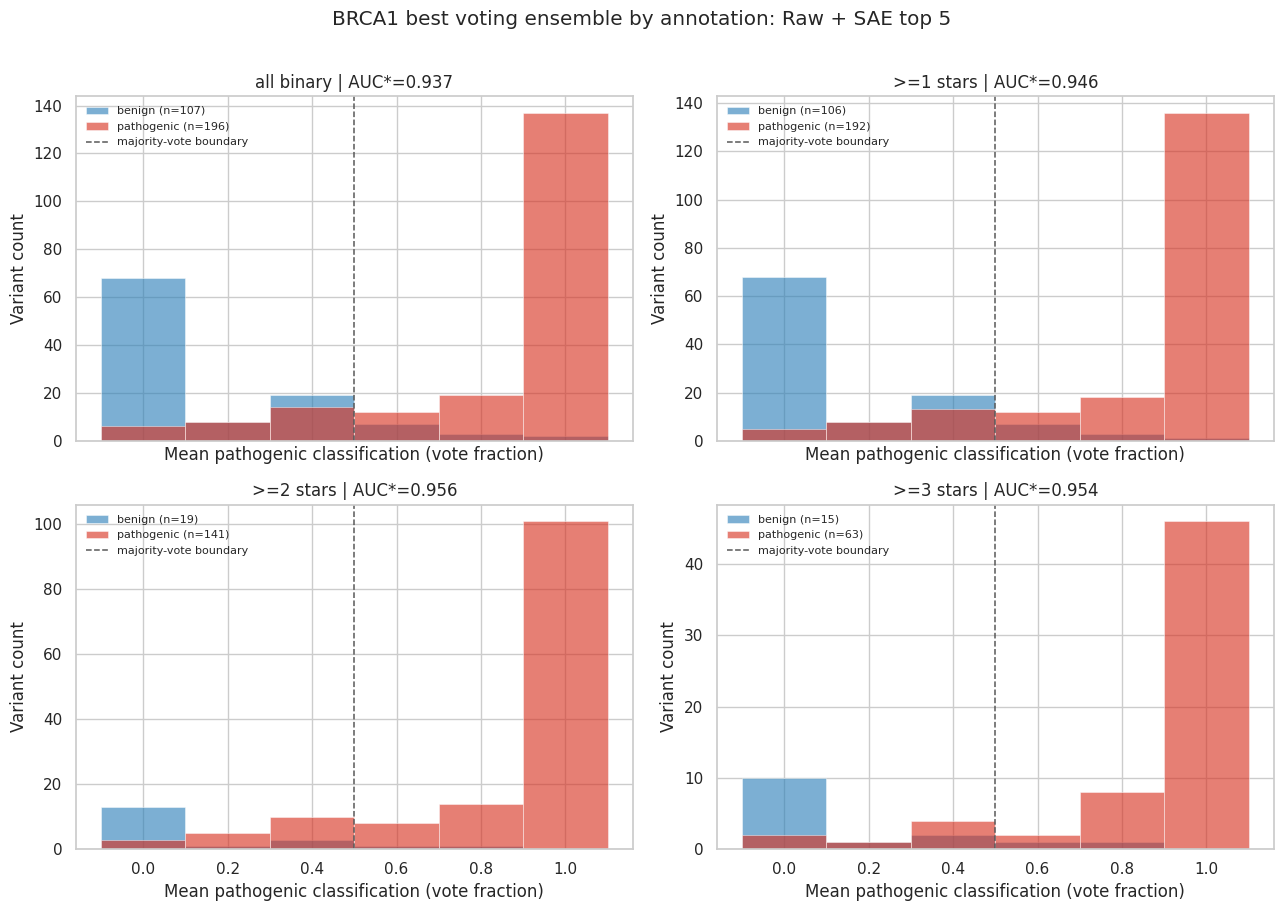

/net/dali/home/barton/dhw28/popDMS/esmDMS/data/clinprotgym_esmc_sae/datasets/MV_BRCA1_Findlay_2018/figures/brca1_sae_downstream/MV_BRCA1_Findlay_2018_best_voting_ensemble_classification_by_review_stars_pipeline.png


In [34]:
plt, sns = ensure_plotting()

all_binary_voting = voting_ensemble_metrics[
    voting_ensemble_metrics["min_review_stars"].eq(0)
    & np.isfinite(safe_numeric(voting_ensemble_metrics["auc_discrimination"]))
].copy()
all_binary_voting["spearman_rho"] = safe_numeric(all_binary_voting["spearman_rho"])
all_binary_voting["auc_discrimination"] = safe_numeric(all_binary_voting["auc_discrimination"])

if all_binary_voting.empty:
    print("No voting ensemble metrics available. Run the voting-ensemble cell first.")
else:
    best_voting_row = all_binary_voting.sort_values(
        ["auc_discrimination", "spearman_rho"], ascending=[False, False]
    ).iloc[0]
    best_voting_label = best_voting_row["ensemble_label"]
    best_voting_predictions = voting_ensemble_predictions[
        voting_ensemble_predictions["ensemble_label"].eq(best_voting_label)
    ][["SequenceIndex", "vote_fraction", "n_votes"]].copy()
    best_voting_predictions["SequenceIndex"] = best_voting_predictions["SequenceIndex"].astype(str)
    total_votes = int(best_voting_predictions["n_votes"].mode().iloc[0])

    label_table = normalize_label_columns(active_labels.copy())
    label_table["SequenceIndex"] = label_table["SequenceIndex"].astype(str)
    panels = []
    for min_stars in GRID_STAR_CUTOFFS:
        cutoff_labels = label_table[
            label_table["stars"].ge(min_stars)
            & label_table["annotation"].isin(PATHOGENICITY_LABELS)
        ][["SequenceIndex", "annotation", "stars"]]
        panel = best_voting_predictions.merge(cutoff_labels, on="SequenceIndex", how="inner")
        if panel.empty:
            continue
        evaluation = panel.copy()
        evaluation["fitness"] = -evaluation["vote_fraction"]
        panels.append((min_stars, panel, auc_from_labeled_fitness(evaluation)))

    print(
        f"Best voting ensemble: {best_voting_label} | votes={total_votes} | "
        f"all-binary AUC*={best_voting_row['auc_discrimination']:.3f} | "
        f"rho={best_voting_row['spearman_rho']:.3f}"
    )
    if not panels:
        print("No labeled variants overlap the best voting ensemble predictions.")
    else:
        fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True, squeeze=False)
        palette = {"benign": "#2C7FB8", "pathogenic": "#D7301F"}
        vote_bin_edges = (np.arange(total_votes + 2) - 0.5) / total_votes
        for ax, (min_stars, panel, stats) in zip(axes.ravel(), panels):
            for annotation in ["benign", "pathogenic"]:
                values = panel.loc[panel["annotation"].eq(annotation), "vote_fraction"].to_numpy(dtype=float)
                ax.hist(
                    values, bins=vote_bin_edges, alpha=0.62, color=palette[annotation],
                    label=f"{annotation} (n={len(values)})", edgecolor="white", linewidth=0.5,
                )
            ax.axvline(0.5, color="0.35", linestyle="--", linewidth=1.1, label="majority-vote boundary")
            cutoff_label = "all binary" if min_stars == 0 else f">={min_stars} stars"
            ax.set_title(f"{cutoff_label} | AUC*={stats['auc_discrimination']:.3f}")
            ax.set_xlabel("Mean pathogenic classification (vote fraction)")
            ax.set_ylabel("Variant count")
            ax.set_xticks(np.arange(total_votes + 1) / total_votes)
            ax.legend(frameon=False, fontsize=8)
        for ax in axes.ravel()[len(panels):]:
            ax.axis("off")
        fig.suptitle(f"BRCA1 best voting ensemble by annotation: {best_voting_label}", y=1.01)
        fig.tight_layout()
        out = FIGURE_DIR / f"{DATASET}_best_voting_ensemble_classification_by_review_stars_{CLINICAL_LABEL_MODE}.png"
        fig.savefig(out, dpi=300, bbox_inches="tight")
        plt.show()
        print(out)


## LLR-Prior popDMS Gamma Diagnostics

For each ESM-C prior, this plot follows the two gamma-selection objectives across the complete regularization sweep. Direction-normalized ClinVar AUC uses the configurable review-star cutoff below; cross-replicate consistency is the mean pairwise Pearson correlation of the replicate-specific selection coefficients. The markers identify the gamma selected by each objective, and the dashed horizontal line gives the AUC of the pure ESM-C LLR baseline on the same clinical labels.


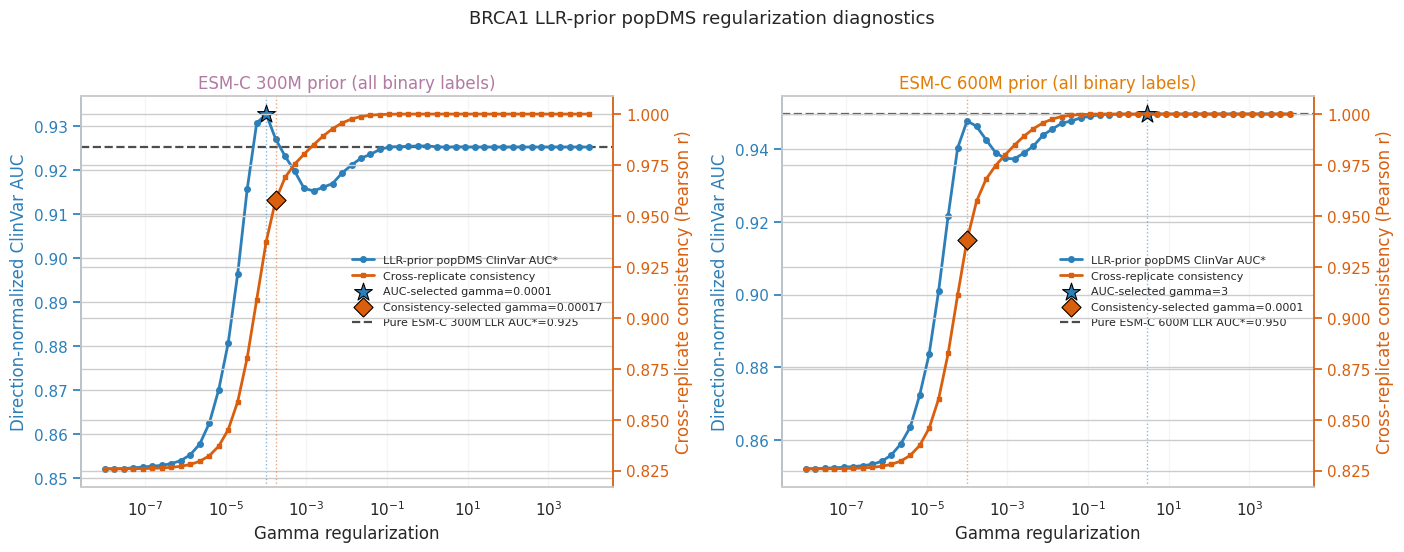

/net/dali/home/barton/dhw28/popDMS/esmDMS/data/clinprotgym_esmc_sae/datasets/MV_BRCA1_Findlay_2018/figures/brca1_sae_downstream/MV_BRCA1_Findlay_2018_llr_prior_popdms_gamma_diagnostics_stars0_pipeline.png


,prior_model,min_review_stars,auc_selected_gamma,auc_at_auc_selected_gamma,consistency_selected_gamma,consistency_at_selected_gamma,auc_at_consistency_selected_gamma,pure_llr_auc
0,ESM-C 300M,0,0.000100,0.932720,0.000172,0.957649,0.927046,0.925234
1,ESM-C 600M,0,2.955209,0.949647,0.000100,0.938349,0.947788,0.949647


In [35]:
plt, sns = ensure_plotting()
LLR_PRIOR_POPDMS_DIAGNOSTIC_STAR_CUTOFF = 0

auc_column = f"auc_discrimination_stars_{LLR_PRIOR_POPDMS_DIAGNOSTIC_STAR_CUTOFF}"
model_colors = {"ESM-C 300M": "#B279A2", "ESM-C 600M": "#E17C05"}
auc_color = "#2C7FB8"
consistency_color = "#D95F0E"
reference_color = "#4D4D4D"
diagnostic_rows = []

fig, axes = plt.subplots(1, len(LLR_PRIOR_POPDMS_MODELS), figsize=(14.2, 5.4), sharex=True, squeeze=False)
for ax, (prior_model, llr_path) in zip(axes.ravel(), LLR_PRIOR_POPDMS_MODELS.items()):
    sweep = llr_prior_popdms_sweeps[prior_model].sort_values("gamma").copy()
    selected = llr_prior_popdms_metrics[
        llr_prior_popdms_metrics["prior_model"].eq(prior_model)
        & llr_prior_popdms_metrics["min_review_stars"].eq(LLR_PRIOR_POPDMS_DIAGNOSTIC_STAR_CUTOFF)
    ].copy()
    auc_selected = selected[selected["optimization"].eq("ClinVar AUC")].iloc[0]
    consistency_selected = selected[selected["optimization"].eq("cross-replicate consistency")].iloc[0]

    llr_fitness = pd.read_csv(llr_path, usecols=["SequenceIndex", "fitness"])
    llr_fitness["SequenceIndex"] = llr_fitness["SequenceIndex"].astype(str)
    pure_llr_stats = llr_prior_popdms_auc(
        llr_fitness, LLR_PRIOR_POPDMS_DIAGNOSTIC_STAR_CUTOFF
    )
    pure_llr_auc = pure_llr_stats["auc_discrimination"]

    auc_line = ax.plot(
        sweep["gamma"], sweep[auc_column], color=auc_color, marker="o", markersize=4,
        linewidth=2.0, label="LLR-prior popDMS ClinVar AUC*", zorder=3,
    )[0]
    llr_line = ax.axhline(
        pure_llr_auc, color=reference_color, linestyle="--", linewidth=1.6,
        label=f"Pure {prior_model} LLR AUC*={pure_llr_auc:.3f}", zorder=1,
    )
    auc_marker = ax.scatter(
        auc_selected["gamma"], auc_selected["auc_discrimination"],
        s=180, marker="*", color=auc_color, edgecolor="black", linewidth=0.8,
        label=f"AUC-selected gamma={auc_selected['gamma']:.2g}", zorder=7,
    )
    ax.axvline(auc_selected["gamma"], color=auc_color, linestyle=":", linewidth=1.0, alpha=0.55)
    ax.set_xscale("log")
    ax.set_xlabel("Gamma regularization")
    ax.set_ylabel("Direction-normalized ClinVar AUC", color=auc_color)
    ax.tick_params(axis="y", colors=auc_color)
    ax.spines["left"].set_color(auc_color)
    ax.grid(True, which="both", axis="x", alpha=0.18)

    consistency_ax = ax.twinx()
    consistency_line = consistency_ax.plot(
        sweep["gamma"], sweep["cross_replicate_consistency"],
        color=consistency_color, marker="s", markersize=3.5, linewidth=2.0,
        label="Cross-replicate consistency", zorder=4,
    )[0]
    consistency_marker = consistency_ax.scatter(
        consistency_selected["gamma"], consistency_selected["cross_replicate_consistency"],
        s=95, marker="D", color=consistency_color, edgecolor="black", linewidth=0.8,
        label=f"Consistency-selected gamma={consistency_selected['gamma']:.2g}", zorder=8,
    )
    consistency_ax.axvline(
        consistency_selected["gamma"], color=consistency_color, linestyle=":", linewidth=1.0, alpha=0.55
    )
    consistency_ax.set_ylabel("Cross-replicate consistency (Pearson r)", color=consistency_color)
    consistency_ax.tick_params(axis="y", colors=consistency_color)
    consistency_ax.spines["right"].set_color(consistency_color)

    cutoff_label = (
        "all binary labels" if LLR_PRIOR_POPDMS_DIAGNOSTIC_STAR_CUTOFF == 0
        else f">={LLR_PRIOR_POPDMS_DIAGNOSTIC_STAR_CUTOFF} review stars"
    )
    ax.set_title(f"{prior_model} prior ({cutoff_label})", color=model_colors[prior_model])
    ax.legend(
        [auc_line, consistency_line, auc_marker, consistency_marker, llr_line],
        [handle.get_label() for handle in [auc_line, consistency_line, auc_marker, consistency_marker, llr_line]],
        loc="center right", frameon=False, fontsize=8,
    )
    diagnostic_rows.append({
        "prior_model": prior_model,
        "min_review_stars": LLR_PRIOR_POPDMS_DIAGNOSTIC_STAR_CUTOFF,
        "auc_selected_gamma": auc_selected["gamma"],
        "auc_at_auc_selected_gamma": auc_selected["auc_discrimination"],
        "consistency_selected_gamma": consistency_selected["gamma"],
        "consistency_at_selected_gamma": consistency_selected["cross_replicate_consistency"],
        "auc_at_consistency_selected_gamma": consistency_selected["auc_discrimination"],
        "pure_llr_auc": pure_llr_auc,
    })

fig.suptitle("BRCA1 LLR-prior popDMS regularization diagnostics", y=1.02, fontsize=13)
fig.tight_layout()
out = FIGURE_DIR / f"{DATASET}_llr_prior_popdms_gamma_diagnostics_stars{LLR_PRIOR_POPDMS_DIAGNOSTIC_STAR_CUTOFF}_{CLINICAL_LABEL_MODE}.png"
fig.savefig(out, dpi=300, bbox_inches="tight")
plt.show()
print(out)
llr_prior_popdms_gamma_diagnostics = pd.DataFrame(diagnostic_rows)
display(llr_prior_popdms_gamma_diagnostics)


## Gamma Diagnostics Across All Four ClinVar Star Cutoffs

The final diagnostic expands the regularization comparison to all four review-star cutoffs. Rows are label cutoffs and columns are ESM-C prior models; each panel recomputes the AUC curve, AUC-selected gamma, and pure-LLR reference from that panel's clinical labels. Cross-replicate consistency and its selected gamma do not depend on clinical labels and are repeated to make the tradeoff directly visible in every panel. Each AUC axis is fitted tightly to its blue curve so the peak sits near the top, all panels share one consistency scale, and horizontal gridlines are suppressed on both y-axes. Cutoff-specific horizontal references additionally show the best voting ensemble, best single SAE layer, best raw-embedding layer, and regular popDMS.


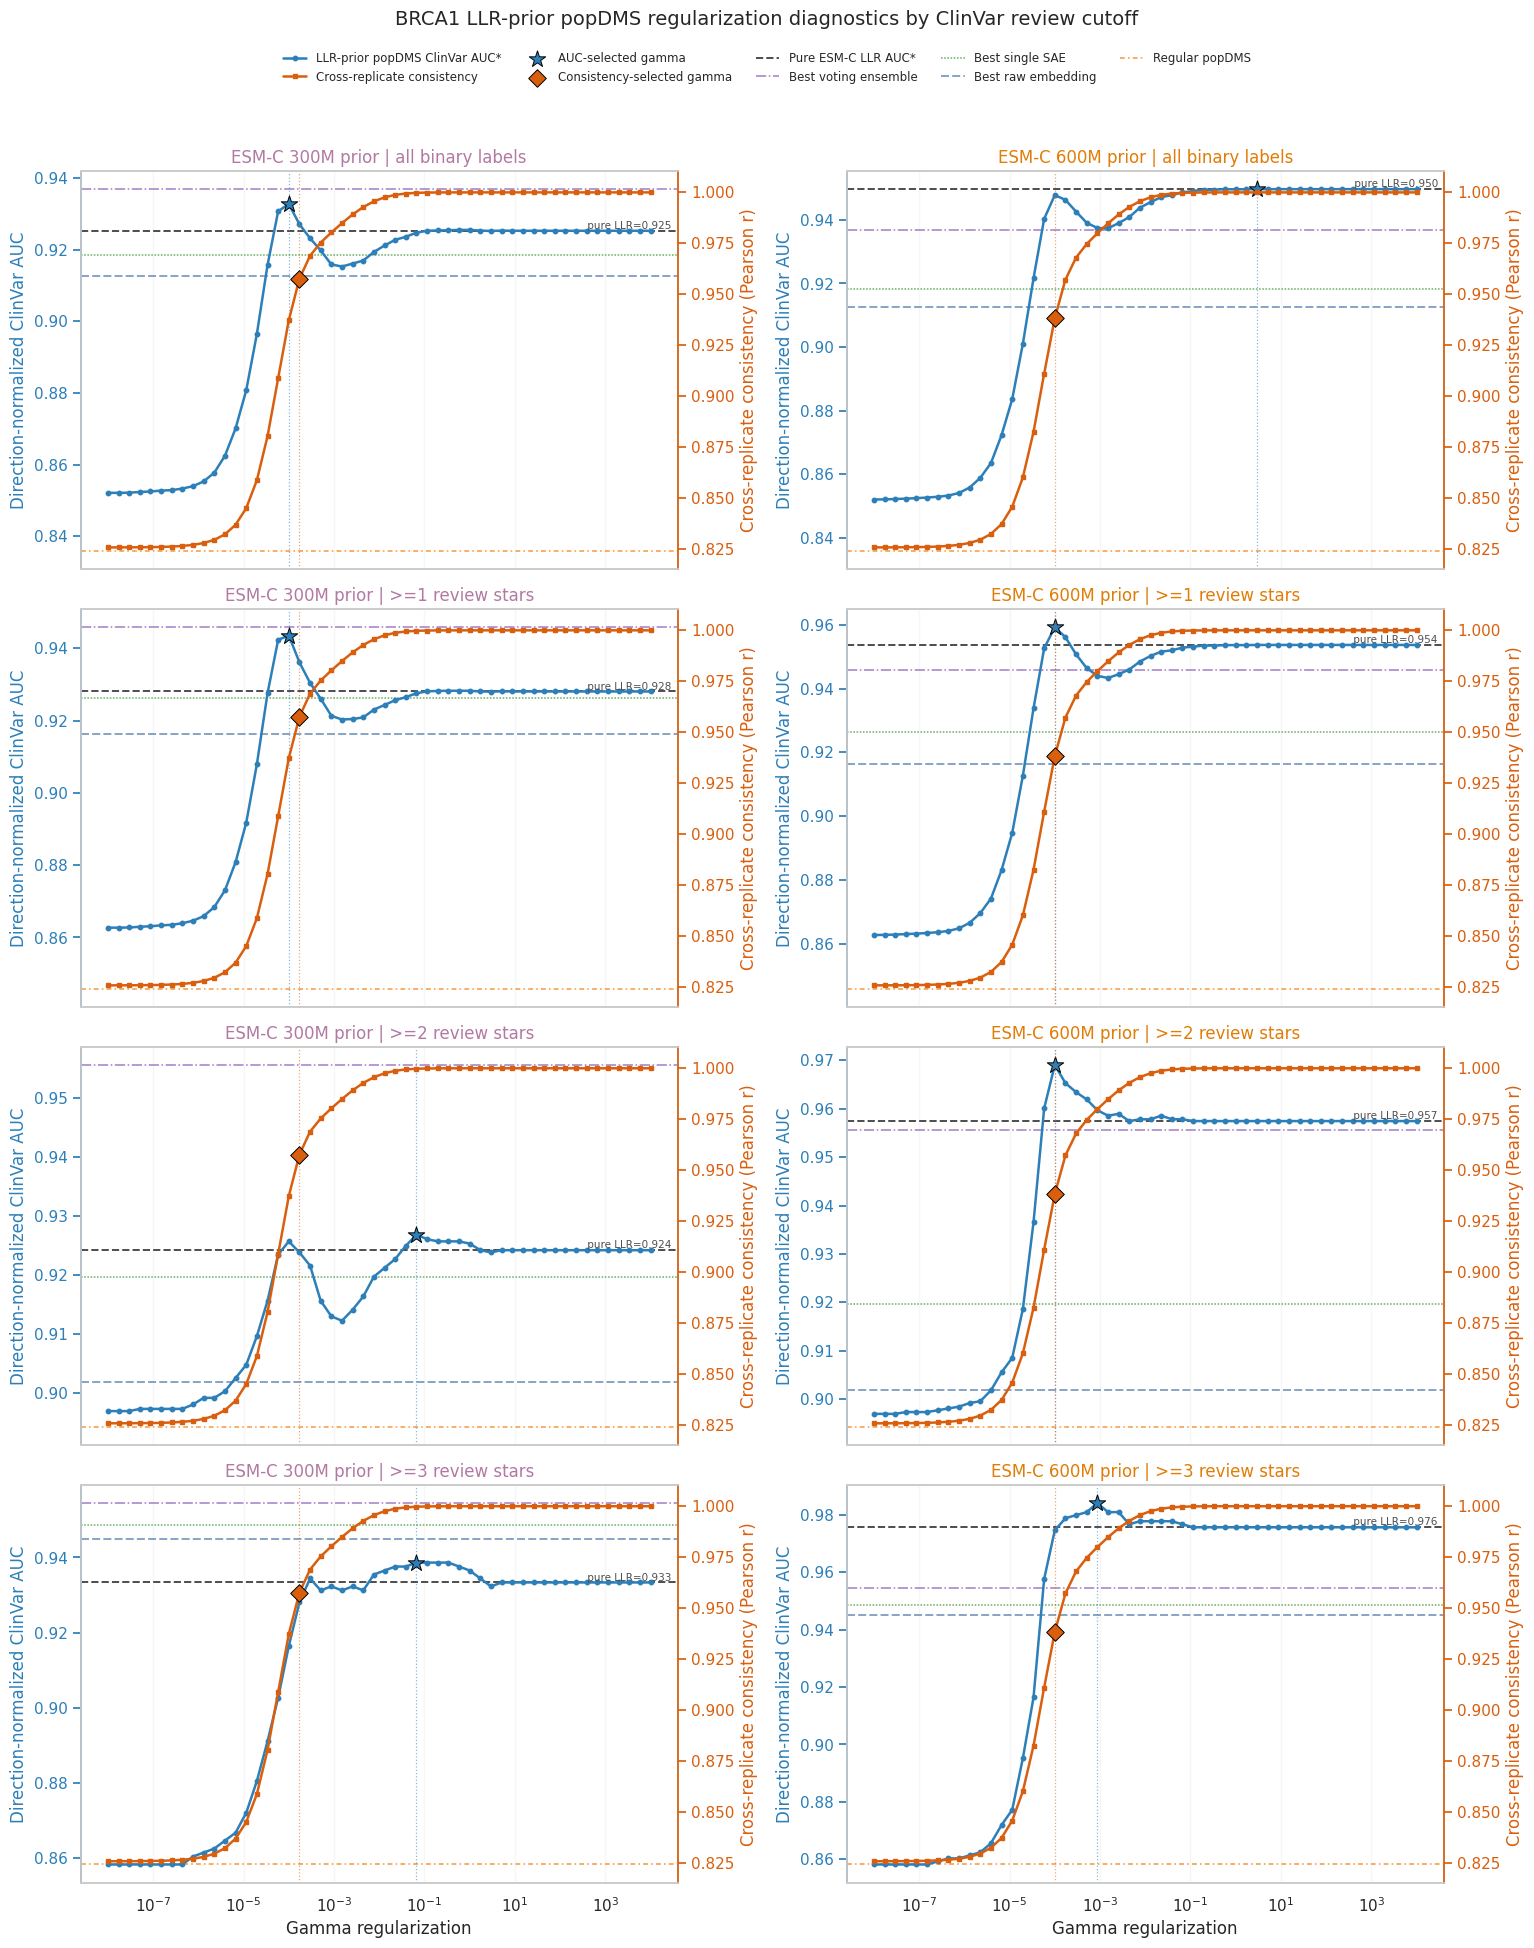

/net/dali/home/barton/dhw28/popDMS/esmDMS/data/clinprotgym_esmc_sae/datasets/MV_BRCA1_Findlay_2018/figures/brca1_sae_downstream/MV_BRCA1_Findlay_2018_llr_prior_popdms_gamma_diagnostics_by_review_stars_pipeline.png


,prior_model,min_review_stars,auc_selected_gamma,auc_at_auc_selected_gamma,consistency_selected_gamma,consistency_at_selected_gamma,auc_at_consistency_selected_gamma,pure_llr_auc
0,ESM-C 300M,0,0.000100,0.932720,0.000172,0.957649,0.927046,0.925234
1,ESM-C 600M,0,2.955209,0.949647,0.000100,0.938349,0.947788,0.949647
2,ESM-C 300M,1,0.000100,0.943544,0.000172,0.957649,0.936124,0.928066
3,ESM-C 600M,1,0.000100,0.959316,0.000100,0.938349,0.959316,0.953715
4,ESM-C 300M,2,0.066608,0.926838,0.000172,0.957649,0.923852,0.924225
5,ESM-C 600M,2,0.000100,0.969018,0.000100,0.938349,0.969018,0.957447
6,ESM-C 300M,3,0.066608,0.938624,0.000172,0.957649,0.928042,0.933333
7,ESM-C 600M,3,0.000873,0.984127,0.000100,0.938349,0.974603,0.975661


,min_review_stars,reference_label,method_family,auc_discrimination,spearman_rho,model_label,model_short,layer
0,0,Best voting ensemble,Voting ensemble,0.936844,0.564634,Raw + SAE top 5,Raw + SAE,NaN
1,0,Best single SAE,Raw SAE,0.918415,0.502812,ESMC-300M Layer_30 DeltaEmbSAE_max_pool_batcht...,ESMC-300M,30.0
2,0,Best raw embedding,Raw embeddings,0.912645,0.497372,ESMC-300M Layer_30 raw max_pool,ESMC-300M,30.0
3,0,Regular popDMS,popDMS baseline,0.836019,0.564651,Regular popDMS substitution,NaN,NaN
4,1,Best voting ensemble,Voting ensemble,0.945878,0.564634,Raw + SAE top 5,Raw + SAE,NaN
5,1,Best single SAE,Raw SAE,0.926297,0.502812,ESMC-300M Layer_30 DeltaEmbSAE_max_pool_batcht...,ESMC-300M,30.0
6,1,Best raw embedding,Raw embeddings,0.916372,0.497372,ESMC-300M Layer_30 raw max_pool,ESMC-300M,30.0
7,1,Regular popDMS,popDMS baseline,0.845863,0.564651,Regular popDMS substitution,NaN,NaN
8,2,Best voting ensemble,Voting ensemble,0.955580,0.564634,Raw + SAE top 5,Raw + SAE,NaN
9,2,Best single SAE,Raw SAE,0.919746,0.502812,ESMC-300M Layer_30 DeltaEmbSAE_max_pool_batcht...,ESMC-300M,30.0


In [36]:
plt, sns = ensure_plotting()
LLR_PRIOR_POPDMS_DIAGNOSTIC_STAR_CUTOFFS = [0, 1, 2, 3]

model_colors = {"ESM-C 300M": "#B279A2", "ESM-C 600M": "#E17C05"}
auc_color = "#2C7FB8"
consistency_color = "#D95F0E"
reference_color = "#4D4D4D"
REFERENCE_BENCHMARK_SPECS = [
    ("Best single SAE", "Raw SAE", "#54A24B", (0, (1, 1))),
    ("Best raw embedding", "Raw embeddings", "#4C78A8", (0, (5, 2))),
    ("Regular popDMS", "popDMS baseline", "#F58518", (0, (3, 2, 1, 2))),
]
diagnostic_rows = []
reference_benchmark_rows = []
legend_handles = None
legend_labels = None
all_consistency_values = np.concatenate([
    sweep["cross_replicate_consistency"].to_numpy(dtype=float)
    for sweep in llr_prior_popdms_sweeps.values()
])
finite_consistency = all_consistency_values[np.isfinite(all_consistency_values)]
consistency_span = float(finite_consistency.max() - finite_consistency.min())
consistency_padding = max(0.005, 0.06 * consistency_span)
shared_consistency_ylim = (
    float(finite_consistency.min() - consistency_padding),
    float(finite_consistency.max() + consistency_padding),
)

pure_llr_fitness = {}
for prior_model, llr_path in LLR_PRIOR_POPDMS_MODELS.items():
    llr_fitness = pd.read_csv(llr_path, usecols=["SequenceIndex", "fitness"])
    llr_fitness["SequenceIndex"] = llr_fitness["SequenceIndex"].astype(str)
    pure_llr_fitness[prior_model] = llr_fitness

for min_stars in LLR_PRIOR_POPDMS_DIAGNOSTIC_STAR_CUTOFFS:
    cutoff_rows = auc_by_labels[auc_by_labels["min_review_stars"].eq(min_stars)].copy()
    cutoff_rows["auc_discrimination"] = safe_numeric(cutoff_rows["auc_discrimination"])
    cutoff_rows["spearman_rho"] = safe_numeric(cutoff_rows.get("spearman_rho", np.nan))
    voting_candidates = voting_ensemble_metrics[
        voting_ensemble_metrics["min_review_stars"].eq(min_stars)
    ].copy()
    voting_candidates["auc_discrimination"] = safe_numeric(voting_candidates["auc_discrimination"])
    voting_candidates["spearman_rho"] = safe_numeric(voting_candidates["spearman_rho"])
    voting_candidates = voting_candidates[np.isfinite(voting_candidates["auc_discrimination"])]
    if not voting_candidates.empty:
        best_voting = voting_candidates.sort_values(
            ["auc_discrimination", "spearman_rho"], ascending=[False, False]
        ).iloc[0]
        reference_benchmark_rows.append({
            "min_review_stars": min_stars,
            "reference_label": "Best voting ensemble",
            "method_family": "Voting ensemble",
            "auc_discrimination": float(best_voting["auc_discrimination"]),
            "spearman_rho": best_voting.get("spearman_rho", np.nan),
            "model_label": best_voting.get("ensemble_label", ""),
            "model_short": best_voting.get("ensemble_pool", ""),
            "layer": np.nan,
            "color": "#9467BD",
            "linestyle": "-.",
        })
    for reference_label, method_family, color, linestyle in REFERENCE_BENCHMARK_SPECS:
        candidates = cutoff_rows[
            cutoff_rows["method_family"].eq(method_family)
            & np.isfinite(cutoff_rows["auc_discrimination"])
        ].copy()
        if candidates.empty:
            continue
        best = candidates.sort_values(
            ["auc_discrimination", "spearman_rho"], ascending=[False, False]
        ).iloc[0]
        reference_benchmark_rows.append({
            "min_review_stars": min_stars,
            "reference_label": reference_label,
            "method_family": method_family,
            "auc_discrimination": float(best["auc_discrimination"]),
            "spearman_rho": best.get("spearman_rho", np.nan),
            "model_label": best.get("model_label", ""),
            "model_short": best.get("model_short", ""),
            "layer": best.get("layer", np.nan),
            "color": color,
            "linestyle": linestyle,
        })
llr_prior_popdms_reference_benchmarks = pd.DataFrame(reference_benchmark_rows)

fig, axes = plt.subplots(
    len(LLR_PRIOR_POPDMS_DIAGNOSTIC_STAR_CUTOFFS), len(LLR_PRIOR_POPDMS_MODELS),
    figsize=(15.5, 19.5), sharex=True, squeeze=False,
)
for row_idx, min_stars in enumerate(LLR_PRIOR_POPDMS_DIAGNOSTIC_STAR_CUTOFFS):
    auc_column = f"auc_discrimination_stars_{min_stars}"
    cutoff_label = "all binary labels" if min_stars == 0 else f">={min_stars} review stars"
    for col_idx, prior_model in enumerate(LLR_PRIOR_POPDMS_MODELS):
        ax = axes[row_idx, col_idx]
        sweep = llr_prior_popdms_sweeps[prior_model].sort_values("gamma").copy()
        selected = llr_prior_popdms_metrics[
            llr_prior_popdms_metrics["prior_model"].eq(prior_model)
            & llr_prior_popdms_metrics["min_review_stars"].eq(min_stars)
        ]
        auc_selected = selected[selected["optimization"].eq("ClinVar AUC")].iloc[0]
        consistency_selected = selected[
            selected["optimization"].eq("cross-replicate consistency")
        ].iloc[0]
        pure_llr_auc = llr_prior_popdms_auc(
            pure_llr_fitness[prior_model], min_stars
        )["auc_discrimination"]
        finite_auc = sweep.loc[np.isfinite(sweep[auc_column]), auc_column].to_numpy(dtype=float)
        auc_span = float(finite_auc.max() - finite_auc.min())
        auc_padding = max(0.001, 0.05 * auc_span)
        panel_auc_ylim = (
            float(finite_auc.min() - auc_padding),
            float(finite_auc.max() + auc_padding),
        )

        auc_line = ax.plot(
            sweep["gamma"], sweep[auc_column], color=auc_color, marker="o",
            markersize=3.2, linewidth=1.8, label="LLR-prior popDMS ClinVar AUC*", zorder=3,
        )[0]
        llr_line = ax.axhline(
            pure_llr_auc, color=reference_color, linestyle="--", linewidth=1.4,
            label="Pure ESM-C LLR AUC*", zorder=1,
        )
        benchmark_lines = []
        panel_references = llr_prior_popdms_reference_benchmarks[
            llr_prior_popdms_reference_benchmarks["min_review_stars"].eq(min_stars)
        ]
        panel_auc_values = np.concatenate([
            finite_auc,
            panel_references["auc_discrimination"].to_numpy(dtype=float),
            np.asarray([pure_llr_auc], dtype=float),
        ])
        panel_auc_span = float(panel_auc_values.max() - panel_auc_values.min())
        panel_auc_padding = max(0.001, 0.05 * panel_auc_span)
        panel_auc_ylim = (
            float(panel_auc_values.min() - panel_auc_padding),
            float(panel_auc_values.max() + panel_auc_padding),
        )
        for _, reference_row in panel_references.iterrows():
            benchmark_lines.append(ax.axhline(
                reference_row["auc_discrimination"], color=reference_row["color"],
                linestyle=reference_row["linestyle"], linewidth=1.15, alpha=0.82,
                label=reference_row["reference_label"], zorder=2,
            ))
        auc_marker = ax.scatter(
            auc_selected["gamma"], auc_selected["auc_discrimination"],
            s=155, marker="*", color=auc_color, edgecolor="black", linewidth=0.7,
            label="AUC-selected gamma", zorder=7,
        )
        ax.axvline(
            auc_selected["gamma"], color=auc_color, linestyle=":", linewidth=0.9, alpha=0.55
        )
        ax.text(
            0.99, pure_llr_auc, f" pure LLR={pure_llr_auc:.3f}",
            transform=ax.get_yaxis_transform(), ha="right", va="bottom",
            fontsize=7.5, color=reference_color,
        )
        ax.set_xscale("log")
        ax.set_ylim(*panel_auc_ylim)
        ax.set_ylabel("Direction-normalized ClinVar AUC", color=auc_color)
        ax.tick_params(axis="y", colors=auc_color)
        ax.spines["left"].set_color(auc_color)
        ax.grid(False, axis="y")
        ax.grid(True, which="both", axis="x", alpha=0.16)

        consistency_ax = ax.twinx()
        consistency_line = consistency_ax.plot(
            sweep["gamma"], sweep["cross_replicate_consistency"],
            color=consistency_color, marker="s", markersize=2.8, linewidth=1.8,
            label="Cross-replicate consistency", zorder=4,
        )[0]
        consistency_marker = consistency_ax.scatter(
            consistency_selected["gamma"],
            consistency_selected["cross_replicate_consistency"],
            s=80, marker="D", color=consistency_color, edgecolor="black", linewidth=0.7,
            label="Consistency-selected gamma", zorder=8,
        )
        consistency_ax.axvline(
            consistency_selected["gamma"], color=consistency_color,
            linestyle=":", linewidth=0.9, alpha=0.55,
        )
        consistency_ax.set_ylabel("Cross-replicate consistency (Pearson r)", color=consistency_color)
        consistency_ax.set_ylim(*shared_consistency_ylim)
        consistency_ax.tick_params(axis="y", colors=consistency_color)
        consistency_ax.spines["right"].set_color(consistency_color)
        consistency_ax.grid(False)

        ax.set_title(f"{prior_model} prior | {cutoff_label}", color=model_colors[prior_model])
        if row_idx == len(LLR_PRIOR_POPDMS_DIAGNOSTIC_STAR_CUTOFFS) - 1:
            ax.set_xlabel("Gamma regularization")
        if legend_handles is None:
            legend_handles = [
                auc_line, consistency_line, auc_marker, consistency_marker, llr_line, *benchmark_lines
            ]
            legend_labels = [handle.get_label() for handle in legend_handles]

        diagnostic_rows.append({
            "prior_model": prior_model,
            "min_review_stars": min_stars,
            "auc_selected_gamma": auc_selected["gamma"],
            "auc_at_auc_selected_gamma": auc_selected["auc_discrimination"],
            "consistency_selected_gamma": consistency_selected["gamma"],
            "consistency_at_selected_gamma": consistency_selected["cross_replicate_consistency"],
            "auc_at_consistency_selected_gamma": consistency_selected["auc_discrimination"],
            "pure_llr_auc": pure_llr_auc,
        })

fig.suptitle("BRCA1 LLR-prior popDMS regularization diagnostics by ClinVar review cutoff", y=0.998, fontsize=14)
fig.legend(
    legend_handles, legend_labels, loc="upper center", bbox_to_anchor=(0.5, 0.982),
    ncol=5, frameon=False, fontsize=8.5,
)
fig.tight_layout(rect=[0, 0, 1, 0.955])
out = FIGURE_DIR / f"{DATASET}_llr_prior_popdms_gamma_diagnostics_by_review_stars_{CLINICAL_LABEL_MODE}.png"
fig.savefig(out, dpi=300, bbox_inches="tight")
plt.show()
print(out)
llr_prior_popdms_gamma_diagnostics_all_cutoffs = pd.DataFrame(diagnostic_rows)
display(llr_prior_popdms_gamma_diagnostics_all_cutoffs)
display(llr_prior_popdms_reference_benchmarks.drop(columns=["color", "linestyle"]))


## LLR Prior-Scale (Alpha) by Gamma Sweep

This secondary local sweep separates the **amplitude** of the ESM-C prior from its **precision**. It solves `(C + gamma I) s = dx + gamma * alpha * LLR` for a grid of gamma and alpha values. Alpha zero is ordinary zero-mean popDMS; alpha one is the raw LLR. The scale-matched alpha preserves LLR zero and matches the LLR standard deviation to the standard deviation of regular popDMS selection coefficients. The grid includes zero, values beginning 100-fold below scale match, half/matched/twice-matched values, logarithmic intermediate values, and the raw prior.

The first figure shows the complete AUC and replicate-consistency surfaces. The second gives readable gamma profiles for the five named alpha choices. Change `LLR_ALPHA_SWEEP_STAR_CUTOFF` to plot another ClinVar review-star cutoff; metrics for all four cutoffs are retained in the sweep table.


Regular popDMS selection SD: 0.0266811
Scale source: /net/dali/home/barton/dhw28/popDMS/esmDMS/data/clinprotgym_esmc_sae/datasets/MV_BRCA1_Findlay_2018/jobs/benchmark_row_analysis/fitness/00002_MV_BRCA1_Findlay_2018_Regular_popDMS_substitution_selection.csv
/net/dali/home/barton/dhw28/popDMS/esmDMS/data/clinprotgym_esmc_sae/datasets/MV_BRCA1_Findlay_2018/tables/MV_BRCA1_Findlay_2018_llr_prior_popdms_alpha_gamma_sweep.csv


,prior_model,raw_llr_std,target_popdms_std,scale_matched_alpha
0,ESM-C 300M,3.816535,0.026681,0.006991
884,ESM-C 600M,4.368287,0.026681,0.006108


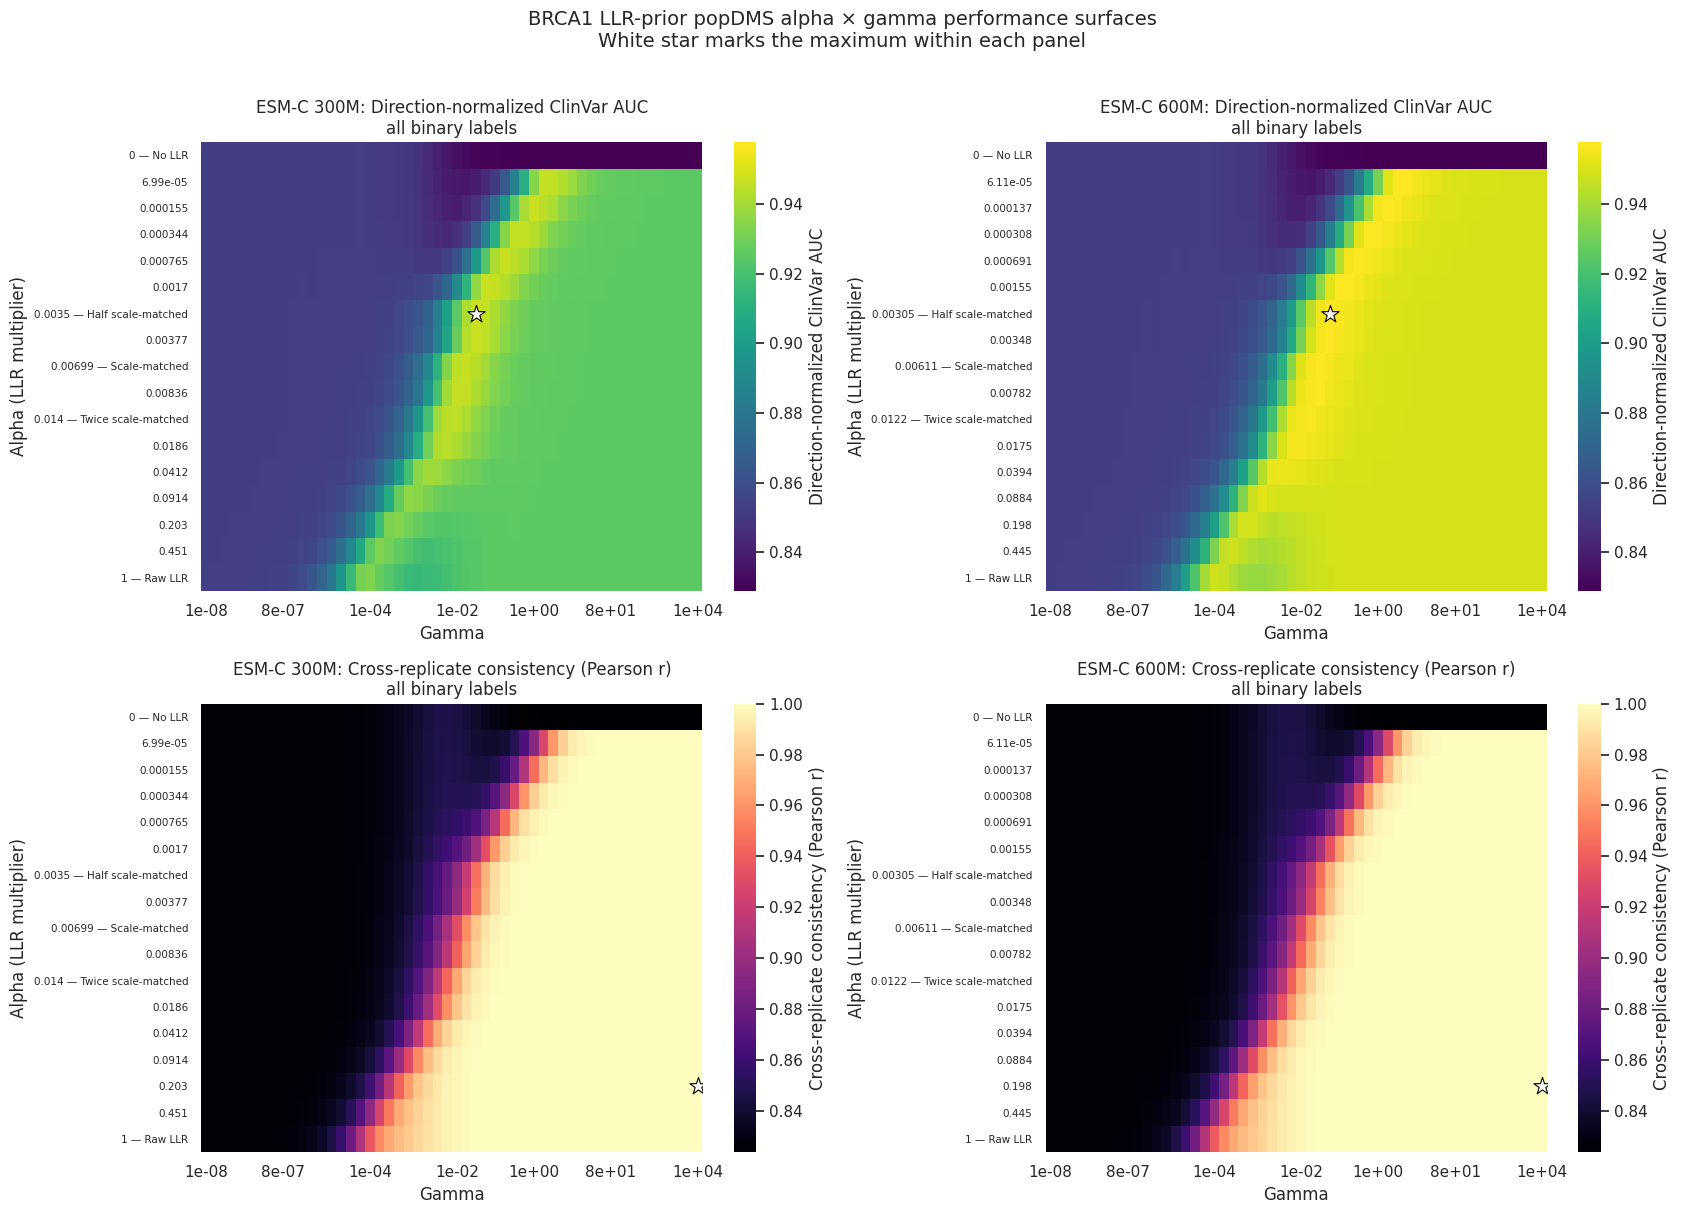

/net/dali/home/barton/dhw28/popDMS/esmDMS/data/clinprotgym_esmc_sae/datasets/MV_BRCA1_Findlay_2018/figures/brca1_sae_downstream/MV_BRCA1_Findlay_2018_llr_prior_popdms_alpha_gamma_surfaces_stars0_pipeline.png


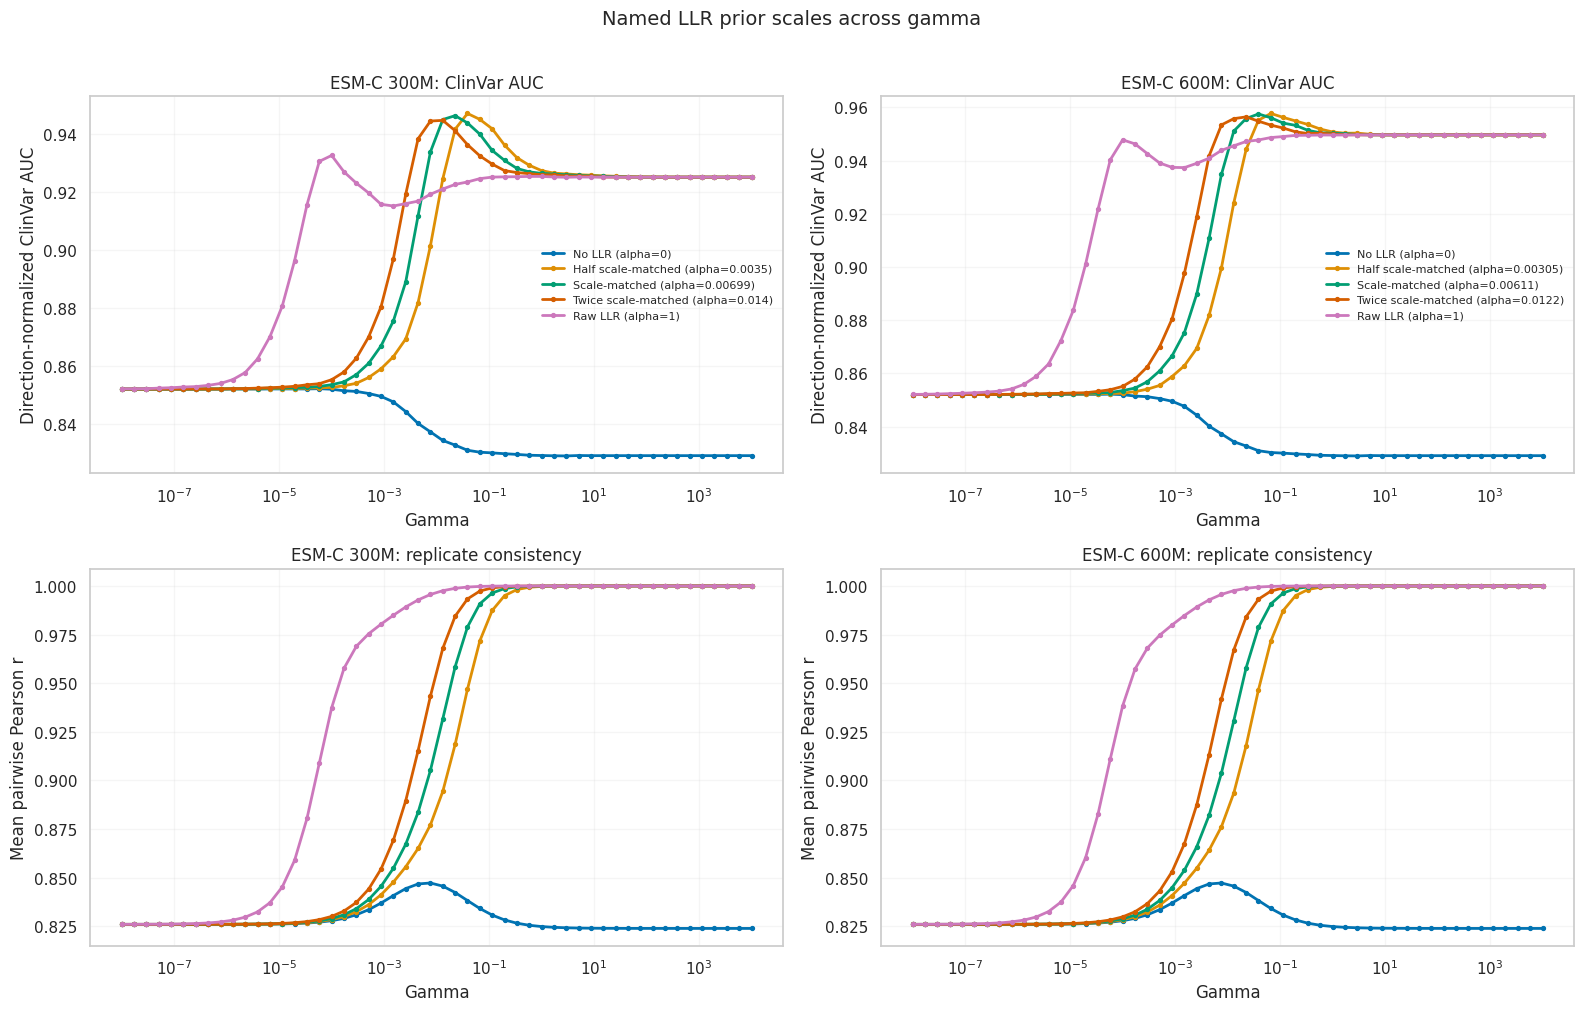

/net/dali/home/barton/dhw28/popDMS/esmDMS/data/clinprotgym_esmc_sae/datasets/MV_BRCA1_Findlay_2018/figures/brca1_sae_downstream/MV_BRCA1_Findlay_2018_llr_prior_popdms_named_alpha_gamma_profiles_stars0_pipeline.png


,prior_model,alpha_label,alpha,auc_selected_gamma,best_auc_discrimination,consistency_selected_gamma,consistency_at_selected_gamma,auc_at_consistency_selected_gamma
0,ESM-C 300M,No LLR,0.000000,0.000058,0.852184,0.002581,0.844303,0.844269
1,ESM-C 300M,Half scale-matched,0.003495,0.038747,0.947215,0.066608,0.971752,0.945165
2,ESM-C 300M,Scale-matched,0.006991,0.022539,0.946452,0.038747,0.978941,0.943925
3,ESM-C 300M,Twice scale-matched,0.013982,0.013111,0.944831,0.013111,0.967901,0.944831
4,ESM-C 300M,Raw LLR,1.000000,0.000100,0.932720,0.000172,0.957649,0.927046
5,ESM-C 600M,No LLR,0.000000,0.000058,0.852184,0.002581,0.844303,0.844269
6,ESM-C 600M,Half scale-matched,0.003054,0.066608,0.957706,0.066608,0.971629,0.957706
7,ESM-C 600M,Scale-matched,0.006108,0.038747,0.957515,0.038747,0.978730,0.957515
8,ESM-C 600M,Twice scale-matched,0.012216,0.022539,0.956418,0.013111,0.967104,0.955751
9,ESM-C 600M,Raw LLR,1.000000,2.955209,0.949647,0.000100,0.938349,0.947788


In [37]:
plt, sns = ensure_plotting()

LLR_ALPHA_SWEEP_STAR_CUTOFF = 0
LLR_ALPHA_SWEEP_GENERAL_POINTS = 13

def regular_popdms_selection_scale(metrics_df):
    rows = metrics_df[metrics_df["method_family"].eq("popDMS baseline")].copy()
    if rows.empty:
        raise ValueError("No regular popDMS row is available for LLR alpha scale matching.")
    row = rows.iloc[0]
    selection_path = Path(str(row.get("selection_path", "")))
    if selection_path.is_file():
        values = safe_numeric(pd.read_csv(selection_path)["selection_coefficient"])
        source = selection_path
    else:
        fitness_path = Path(str(row.get("fitness_path", "")))
        if not fitness_path.is_file():
            raise FileNotFoundError("Regular popDMS selection and fitness files are both missing.")
        values = safe_numeric(pd.read_csv(fitness_path)["fitness"]) - 1.0
        source = fitness_path
    values = values[np.isfinite(values)]
    if len(values) < 2 or float(values.std(ddof=1)) <= 0:
        raise ValueError("Regular popDMS selection coefficients do not have a usable scale.")
    return float(values.std(ddof=1)), source

def llr_alpha_grid(scale_matched):
    named = {
        "No LLR": 0.0,
        "Half scale-matched": 0.5 * scale_matched,
        "Scale-matched": scale_matched,
        "Twice scale-matched": 2.0 * scale_matched,
        "Raw LLR": 1.0,
    }
    general = np.geomspace(scale_matched / 100.0, 1.0, num=LLR_ALPHA_SWEEP_GENERAL_POINTS)
    values = np.unique(np.round(np.concatenate([[0.0], general, list(named.values())]), 15))
    rows = []
    for alpha in np.sort(values):
        label = next(
            (name for name, value in named.items() if np.isclose(alpha, value, rtol=1e-10, atol=1e-15)),
            "General sweep",
        )
        rows.append({"alpha": float(alpha), "alpha_label": label})
    return pd.DataFrame(rows), named

def run_llr_alpha_gamma_sweep(
    model_label,
    llr_path,
    popdms_selection_scale,
    gamma_values=LLR_PRIOR_POPDMS_GAMMAS,
):
    state = load_dataset_state()
    sequence_df = state["sequence_dataframe"].copy()
    metadata_df = state["sequence_metadata"].copy()
    scores_df = state["scores_dataframe"].copy()
    scores_df["SequenceIndex"] = scores_df["SequenceIndex"].astype(str)

    seq_to_feature, feature_table = llr_prior_popdms_feature_index(metadata_df)
    payloads = [
        llr_prior_popdms_replicate_payload(rep_df, seq_to_feature, len(feature_table))
        for _, rep_df in sequence_df.groupby("Replicate")
        if rep_df["Generation"].nunique() >= 2
    ]
    if not payloads:
        raise ValueError("No usable replicate trajectories for the LLR alpha sweep.")

    llr = pd.read_csv(llr_path, usecols=["SequenceIndex", "fitness"])
    llr["SequenceIndex"] = llr["SequenceIndex"].astype(str)
    raw_prior = (
        feature_table[["SequenceIndex"]]
        .merge(llr, on="SequenceIndex", how="left")["fitness"]
        .to_numpy(dtype=float)
    )
    if not np.isfinite(raw_prior).all():
        raise ValueError(f"{model_label} has missing LLR values in the assayed mutation set.")

    llr_scale = float(np.std(raw_prior, ddof=1))
    scale_matched = float(popdms_selection_scale / llr_scale)
    alpha_table, named_alphas = llr_alpha_grid(scale_matched)
    joint_payload = {
        "diag": np.sum([payload["diag"] for payload in payloads], axis=0),
        "weighted_means": [item for payload in payloads for item in payload["weighted_means"]],
        "dx": np.sum([payload["dx"] for payload in payloads], axis=0),
    }

    sweep_rows = []
    for alpha_row in alpha_table.itertuples(index=False):
        scaled_prior = float(alpha_row.alpha) * raw_prior
        for gamma in np.asarray(gamma_values, dtype=float):
            replicate_selection = np.asarray([
                solve_llr_prior_popdms(payload, gamma, scaled_prior)
                for payload in payloads
            ])
            pair_r = [
                pearsonr(replicate_selection[i], replicate_selection[j]).statistic
                for i in range(len(payloads))
                for j in range(i + 1, len(payloads))
            ]
            consistency = float(np.nanmean(pair_r)) if pair_r else np.nan

            # Match the joint convention used by the notebook's primary LLR-prior benchmark.
            joint_selection = solve_llr_prior_popdms(
                joint_payload, gamma * len(payloads), scaled_prior
            )
            fitness = llr_prior_popdms_fitness(feature_table, joint_selection)
            row = {
                "prior_model": model_label,
                "alpha": float(alpha_row.alpha),
                "alpha_over_scale_match": (
                    float(alpha_row.alpha / scale_matched) if scale_matched > 0 else np.nan
                ),
                "alpha_label": alpha_row.alpha_label,
                "scale_matched_alpha": scale_matched,
                "raw_llr_std": llr_scale,
                "target_popdms_std": popdms_selection_scale,
                "gamma": float(gamma),
                "cross_replicate_consistency": consistency,
                "spearman_rho": llr_prior_popdms_spearman(fitness, scores_df),
            }
            for min_stars in LLR_PRIOR_POPDMS_STAR_CUTOFFS:
                stats = llr_prior_popdms_auc(fitness, min_stars)
                row[f"auc_discrimination_stars_{min_stars}"] = stats["auc_discrimination"]
                row[f"auc_stars_{min_stars}"] = stats["auc"]
                row[f"n_benign_stars_{min_stars}"] = stats["n_benign"]
                row[f"n_pathogenic_stars_{min_stars}"] = stats["n_pathogenic"]
            sweep_rows.append(row)

    return (
        pd.DataFrame(sweep_rows).sort_values(["alpha", "gamma"]).reset_index(drop=True),
        alpha_table,
        named_alphas,
    )

popdms_selection_std, popdms_scale_source = regular_popdms_selection_scale(metrics)
print(f"Regular popDMS selection SD: {popdms_selection_std:.6g}")
print(f"Scale source: {popdms_scale_source}")

llr_alpha_gamma_sweep_frames = []
llr_alpha_tables = {}
llr_named_alphas = {}
for prior_model, llr_path in LLR_PRIOR_POPDMS_MODELS.items():
    model_sweep, alpha_table, named_alphas = run_llr_alpha_gamma_sweep(
        prior_model, llr_path, popdms_selection_std
    )
    llr_alpha_gamma_sweep_frames.append(model_sweep)
    llr_alpha_tables[prior_model] = alpha_table
    llr_named_alphas[prior_model] = named_alphas

llr_alpha_gamma_sweep = pd.concat(llr_alpha_gamma_sweep_frames, ignore_index=True)
alpha_sweep_path = TABLE_DIR / f"{DATASET}_llr_prior_popdms_alpha_gamma_sweep.csv"
llr_alpha_gamma_sweep.to_csv(alpha_sweep_path, index=False)
print(alpha_sweep_path)

scale_summary = (
    llr_alpha_gamma_sweep[
        ["prior_model", "raw_llr_std", "target_popdms_std", "scale_matched_alpha"]
    ]
    .drop_duplicates()
    .sort_values("prior_model")
)
display(scale_summary)

auc_column = f"auc_discrimination_stars_{LLR_ALPHA_SWEEP_STAR_CUTOFF}"
surface_specs = [
    (auc_column, "Direction-normalized ClinVar AUC", "viridis"),
    ("cross_replicate_consistency", "Cross-replicate consistency (Pearson r)", "magma"),
]
surface_limits = {
    metric: (
        float(safe_numeric(llr_alpha_gamma_sweep[metric]).min()),
        float(safe_numeric(llr_alpha_gamma_sweep[metric]).max()),
    )
    for metric, _, _ in surface_specs
}

fig, axes = plt.subplots(
    len(surface_specs), len(LLR_PRIOR_POPDMS_MODELS),
    figsize=(17, 12), squeeze=False,
)
for row_idx, (metric, metric_label, cmap) in enumerate(surface_specs):
    for col_idx, prior_model in enumerate(LLR_PRIOR_POPDMS_MODELS):
        ax = axes[row_idx, col_idx]
        model_sweep = llr_alpha_gamma_sweep[
            llr_alpha_gamma_sweep["prior_model"].eq(prior_model)
        ].copy()
        pivot = (
            model_sweep.pivot(index="alpha", columns="gamma", values=metric)
            .sort_index()
            .sort_index(axis=1)
        )
        sns.heatmap(
            pivot, ax=ax, cmap=cmap,
            vmin=surface_limits[metric][0], vmax=surface_limits[metric][1],
            cbar_kws={"label": metric_label},
            xticklabels=False, yticklabels=False,
        )

        gamma_values = pivot.columns.to_numpy(dtype=float)
        gamma_ticks = np.unique(np.linspace(0, len(gamma_values) - 1, 7).round().astype(int))
        ax.set_xticks(gamma_ticks + 0.5)
        ax.set_xticklabels([f"{gamma_values[idx]:.0e}" for idx in gamma_ticks], rotation=0)

        alpha_values = pivot.index.to_numpy(dtype=float)
        alpha_meta = (
            model_sweep[["alpha", "alpha_label"]]
            .drop_duplicates("alpha")
            .set_index("alpha")["alpha_label"]
        )
        alpha_labels = []
        for alpha in alpha_values:
            label = alpha_meta.loc[alpha]
            suffix = f" — {label}" if label != "General sweep" else ""
            alpha_labels.append(f"{alpha:.3g}{suffix}")
        ax.set_yticks(np.arange(len(alpha_values)) + 0.5)
        ax.set_yticklabels(alpha_labels, rotation=0, fontsize=7.5)

        values = pivot.to_numpy(dtype=float)
        if np.isfinite(values).any():
            best_flat = int(np.nanargmax(values))
            best_row, best_col = np.unravel_index(best_flat, values.shape)
            ax.scatter(
                best_col + 0.5, best_row + 0.5,
                marker="*", s=170, facecolor="white", edgecolor="black", linewidth=0.8,
            )

        ax.set_xlabel("Gamma")
        ax.set_ylabel("Alpha (LLR multiplier)")
        cutoff_label = (
            "all binary labels" if LLR_ALPHA_SWEEP_STAR_CUTOFF == 0
            else f">={LLR_ALPHA_SWEEP_STAR_CUTOFF} review stars"
        )
        ax.set_title(f"{prior_model}: {metric_label}\n{cutoff_label}")

fig.suptitle(
    "BRCA1 LLR-prior popDMS alpha × gamma performance surfaces\n"
    "White star marks the maximum within each panel",
    y=1.01, fontsize=14,
)
fig.tight_layout()
alpha_surface_path = FIGURE_DIR / (
    f"{DATASET}_llr_prior_popdms_alpha_gamma_surfaces_"
    f"stars{LLR_ALPHA_SWEEP_STAR_CUTOFF}_{CLINICAL_LABEL_MODE}.png"
)
fig.savefig(alpha_surface_path, dpi=300, bbox_inches="tight")
plt.show()
print(alpha_surface_path)

named_order = [
    "No LLR", "Half scale-matched", "Scale-matched",
    "Twice scale-matched", "Raw LLR",
]
named_colors = dict(zip(named_order, sns.color_palette("colorblind", len(named_order))))
fig, axes = plt.subplots(2, len(LLR_PRIOR_POPDMS_MODELS), figsize=(16, 10), squeeze=False)
for col_idx, prior_model in enumerate(LLR_PRIOR_POPDMS_MODELS):
    model_sweep = llr_alpha_gamma_sweep[
        llr_alpha_gamma_sweep["prior_model"].eq(prior_model)
    ].copy()
    for label in named_order:
        profile = model_sweep[model_sweep["alpha_label"].eq(label)].sort_values("gamma")
        if profile.empty:
            continue
        alpha = float(profile["alpha"].iloc[0])
        legend_label = f"{label} (alpha={alpha:.3g})"
        axes[0, col_idx].plot(
            profile["gamma"], profile[auc_column],
            color=named_colors[label], linewidth=2, marker="o", markersize=2.8,
            label=legend_label,
        )
        axes[1, col_idx].plot(
            profile["gamma"], profile["cross_replicate_consistency"],
            color=named_colors[label], linewidth=2, marker="o", markersize=2.8,
            label=legend_label,
        )

    axes[0, col_idx].set_title(f"{prior_model}: ClinVar AUC")
    axes[1, col_idx].set_title(f"{prior_model}: replicate consistency")
    for row_idx, ax in enumerate(axes[:, col_idx]):
        ax.set_xscale("log")
        ax.set_xlabel("Gamma")
        ax.grid(True, which="both", alpha=0.18)
        ax.set_ylabel(
            "Direction-normalized ClinVar AUC"
            if row_idx == 0 else "Mean pairwise Pearson r"
        )
    axes[0, col_idx].legend(frameon=False, fontsize=8)

fig.suptitle("Named LLR prior scales across gamma", y=1.01, fontsize=14)
fig.tight_layout()
alpha_profiles_path = FIGURE_DIR / (
    f"{DATASET}_llr_prior_popdms_named_alpha_gamma_profiles_"
    f"stars{LLR_ALPHA_SWEEP_STAR_CUTOFF}_{CLINICAL_LABEL_MODE}.png"
)
fig.savefig(alpha_profiles_path, dpi=300, bbox_inches="tight")
plt.show()
print(alpha_profiles_path)

summary_rows = []
for prior_model in LLR_PRIOR_POPDMS_MODELS:
    model_sweep = llr_alpha_gamma_sweep[
        llr_alpha_gamma_sweep["prior_model"].eq(prior_model)
    ]
    for label in named_order:
        profile = model_sweep[model_sweep["alpha_label"].eq(label)].sort_values("gamma")
        if profile.empty:
            continue
        auc_selected = profile.sort_values(
            [auc_column, "gamma"], ascending=[False, True]
        ).iloc[0]
        consistency_gamma = float(paper_popdms_gamma(
            profile["cross_replicate_consistency"].to_list(),
            profile["gamma"].to_numpy(dtype=float),
            corr_cutoff_pct=0.5,
        ))
        consistency_selected = profile[
            np.isclose(profile["gamma"], consistency_gamma)
        ].iloc[0]
        summary_rows.append({
            "prior_model": prior_model,
            "alpha_label": label,
            "alpha": float(profile["alpha"].iloc[0]),
            "auc_selected_gamma": float(auc_selected["gamma"]),
            "best_auc_discrimination": float(auc_selected[auc_column]),
            "consistency_selected_gamma": consistency_gamma,
            "consistency_at_selected_gamma": float(
                consistency_selected["cross_replicate_consistency"]
            ),
            "auc_at_consistency_selected_gamma": float(
                consistency_selected[auc_column]
            ),
        })

llr_alpha_gamma_named_summary = pd.DataFrame(summary_rows)
display(llr_alpha_gamma_named_summary)


## Four-Star Gamma Diagnostics at the Best LLR Alpha

For each ESM-C model, alpha is selected by the highest direction-normalized ClinVar AUC over the complete alpha-by-gamma sweep at `LLR_BEST_ALPHA_SELECTION_STAR_CUTOFF` (default: all binary labels). Alpha is then held fixed while gamma is re-optimized separately for AUC at each review-star cutoff. The established four-star plotting cell is reused so its axes and benchmark references remain directly comparable, with an additional horizontal reference for the AUC of the BRCA1 DMS functional scores themselves. The benchmark table following the plot also includes the best-alpha ESM-C 600M LLR-prior popDMS value at the AUC-selected gamma for each cutoff.


,prior_model,alpha,alpha_label,selection_star_cutoff,selection_gamma,selection_auc_discrimination,scale_matched_alpha,alpha_over_scale_match
0,ESM-C 300M,0.003495,Half scale-matched,0,0.038747,0.947215,0.006991,0.5
1,ESM-C 600M,0.003054,Half scale-matched,0,0.066608,0.957706,0.006108,0.5


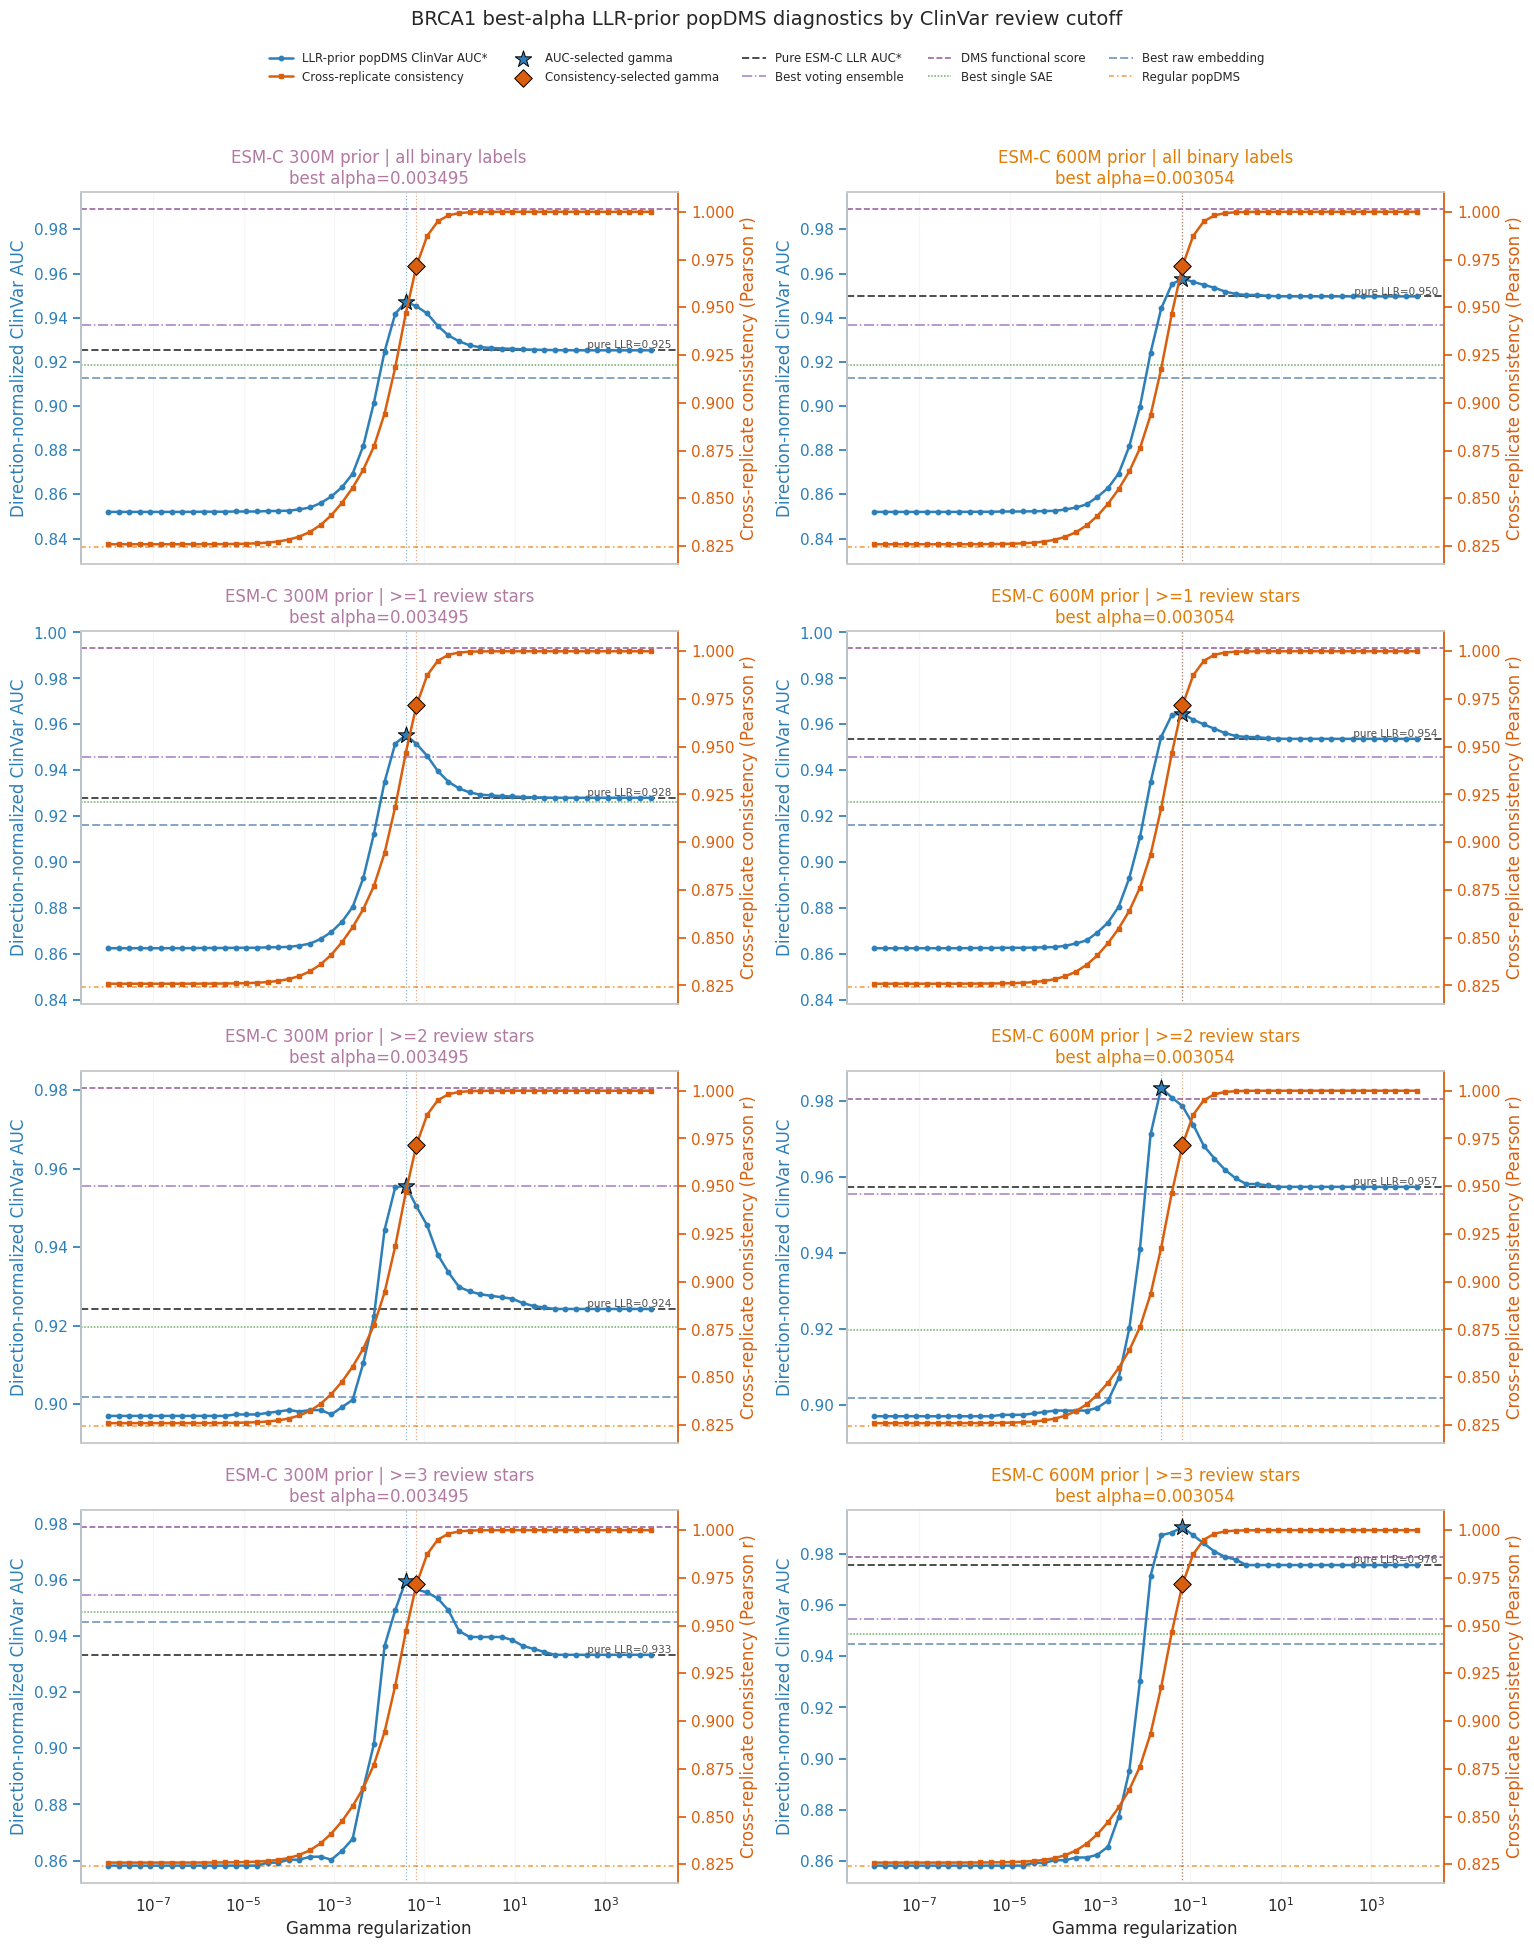

/net/dali/home/barton/dhw28/popDMS/esmDMS/data/clinprotgym_esmc_sae/datasets/MV_BRCA1_Findlay_2018/figures/brca1_sae_downstream/MV_BRCA1_Findlay_2018_llr_prior_popdms_best_alpha_gamma_diagnostics_by_review_stars_pipeline.png


,prior_model,min_review_stars,auc_selected_gamma,auc_at_auc_selected_gamma,consistency_selected_gamma,consistency_at_selected_gamma,auc_at_consistency_selected_gamma,pure_llr_auc
0,ESM-C 300M,0,0.038747,0.947215,0.066608,0.971752,0.945165,0.925234
1,ESM-C 600M,0,0.066608,0.957706,0.066608,0.971629,0.957706,0.949647
2,ESM-C 300M,1,0.038747,0.955385,0.066608,0.971752,0.951504,0.928066
3,ESM-C 600M,1,0.066608,0.964672,0.066608,0.971629,0.964672,0.953715
4,ESM-C 300M,2,0.038747,0.955580,0.066608,0.971752,0.950355,0.924225
5,ESM-C 600M,2,0.022539,0.983576,0.066608,0.971629,0.978723,0.957447
6,ESM-C 300M,3,0.038747,0.959788,0.066608,0.971752,0.956614,0.933333
7,ESM-C 600M,3,0.066608,0.990476,0.066608,0.971629,0.990476,0.975661


,min_review_stars,reference_label,method_family,auc_discrimination,spearman_rho,model_label,model_short,layer
3,0,Best raw embedding,Raw embeddings,0.912645,0.497372,ESMC-300M Layer_30 raw max_pool,ESMC-300M,30.0
2,0,Best single SAE,Raw SAE,0.918415,0.502812,ESMC-300M Layer_30 DeltaEmbSAE_max_pool_batcht...,ESMC-300M,30.0
0,0,Best voting ensemble,Voting ensemble,0.936844,0.564634,Raw + SAE top 5,Raw + SAE,NaN
20,0,Best-alpha LLR-prior popDMS (ESM-C 600M),Best-alpha LLR-prior popDMS,0.957706,0.645315,"alpha=0.003054, gamma=0.06661",ESM-C 600M,NaN
1,0,DMS functional score,DMS functional score,0.989319,1.000000,DMS functional score,NaN,NaN
4,0,Regular popDMS,popDMS baseline,0.836019,0.564651,Regular popDMS substitution,NaN,NaN
8,1,Best raw embedding,Raw embeddings,0.916372,0.497372,ESMC-300M Layer_30 raw max_pool,ESMC-300M,30.0
7,1,Best single SAE,Raw SAE,0.926297,0.502812,ESMC-300M Layer_30 DeltaEmbSAE_max_pool_batcht...,ESMC-300M,30.0
5,1,Best voting ensemble,Voting ensemble,0.945878,0.564634,Raw + SAE top 5,Raw + SAE,NaN
21,1,Best-alpha LLR-prior popDMS (ESM-C 600M),Best-alpha LLR-prior popDMS,0.964672,0.645315,"alpha=0.003054, gamma=0.06661",ESM-C 600M,NaN


,prior_model,min_review_stars,auc_selected_gamma,auc_at_auc_selected_gamma,consistency_selected_gamma,consistency_at_selected_gamma,auc_at_consistency_selected_gamma,pure_llr_auc
0,ESM-C 300M,0,0.038747,0.947215,0.066608,0.971752,0.945165,0.925234
1,ESM-C 600M,0,0.066608,0.957706,0.066608,0.971629,0.957706,0.949647
2,ESM-C 300M,1,0.038747,0.955385,0.066608,0.971752,0.951504,0.928066
3,ESM-C 600M,1,0.066608,0.964672,0.066608,0.971629,0.964672,0.953715
4,ESM-C 300M,2,0.038747,0.955580,0.066608,0.971752,0.950355,0.924225
5,ESM-C 600M,2,0.022539,0.983576,0.066608,0.971629,0.978723,0.957447
6,ESM-C 300M,3,0.038747,0.959788,0.066608,0.971752,0.956614,0.933333
7,ESM-C 600M,3,0.066608,0.990476,0.066608,0.971629,0.990476,0.975661


In [38]:
LLR_BEST_ALPHA_SELECTION_STAR_CUTOFF = 0

if "llr_alpha_gamma_sweep" not in globals():
    alpha_sweep_path = TABLE_DIR / f"{DATASET}_llr_prior_popdms_alpha_gamma_sweep.csv"
    llr_alpha_gamma_sweep = pd.read_csv(alpha_sweep_path)

selection_auc_column = f"auc_discrimination_stars_{LLR_BEST_ALPHA_SELECTION_STAR_CUTOFF}"
best_alpha_rows = []
best_alpha_profiles = {}
best_alpha_metric_rows = []
for prior_model in LLR_PRIOR_POPDMS_MODELS:
    model_sweep = llr_alpha_gamma_sweep[
        llr_alpha_gamma_sweep["prior_model"].eq(prior_model)
    ].copy()
    best_row = model_sweep.sort_values(
        [selection_auc_column, "alpha", "gamma"],
        ascending=[False, True, True],
    ).iloc[0]
    best_alpha = float(best_row["alpha"])
    profile = model_sweep[
        np.isclose(model_sweep["alpha"], best_alpha, rtol=1e-10, atol=1e-15)
    ].sort_values("gamma")
    best_alpha_profiles[prior_model] = profile
    best_alpha_rows.append({
        "prior_model": prior_model,
        "alpha": best_alpha,
        "alpha_label": best_row["alpha_label"],
        "selection_star_cutoff": LLR_BEST_ALPHA_SELECTION_STAR_CUTOFF,
        "selection_gamma": float(best_row["gamma"]),
        "selection_auc_discrimination": float(best_row[selection_auc_column]),
        "scale_matched_alpha": float(best_row["scale_matched_alpha"]),
        "alpha_over_scale_match": float(best_row["alpha_over_scale_match"]),
    })

    consistency_gamma = float(paper_popdms_gamma(
        profile["cross_replicate_consistency"].to_list(),
        profile["gamma"].to_numpy(dtype=float),
        corr_cutoff_pct=0.5,
    ))
    for min_stars in LLR_PRIOR_POPDMS_STAR_CUTOFFS:
        auc_column = f"auc_discrimination_stars_{min_stars}"
        auc_gamma = float(profile.sort_values(
            [auc_column, "gamma"], ascending=[False, True]
        ).iloc[0]["gamma"])
        for optimization, selected_gamma in [
            ("ClinVar AUC", auc_gamma),
            ("cross-replicate consistency", consistency_gamma),
        ]:
            selected = profile[np.isclose(profile["gamma"], selected_gamma)].iloc[0]
            best_alpha_metric_rows.append({
                "benchmark": "Best-alpha LLR-prior popDMS",
                "prior_model": prior_model,
                "optimization": optimization,
                "min_review_stars": min_stars,
                "gamma": selected_gamma,
                "spearman_rho": selected["spearman_rho"],
                "auc": selected[f"auc_stars_{min_stars}"],
                "auc_discrimination": selected[auc_column],
                "cross_replicate_consistency": selected["cross_replicate_consistency"],
                "n_benign": int(selected[f"n_benign_stars_{min_stars}"]),
                "n_pathogenic": int(selected[f"n_pathogenic_stars_{min_stars}"]),
            })

llr_best_alpha_selections = pd.DataFrame(best_alpha_rows)
llr_best_alpha_metrics = pd.DataFrame(best_alpha_metric_rows)
display(llr_best_alpha_selections)

notebook_path = REPO_ROOT / "clinprotgym_brca1_sae_downstream_analysis.ipynb"
notebook_json = json.loads(notebook_path.read_text())
four_star_source = next(
    "".join(cell["source"])
    for cell in notebook_json["cells"]
    if cell.get("id") == "brca1-llr-prior-popdms-four-cutoff-code"
)
four_star_source = four_star_source.replace(
    'REFERENCE_BENCHMARK_SPECS = [\n',
    'REFERENCE_BENCHMARK_SPECS = [\n'
    '    ("DMS functional score", "DMS functional score", "#7F3C8D", "--"),\n',
)
four_star_source = four_star_source.replace(
    'ax.set_title(f"{prior_model} prior | {cutoff_label}", color=model_colors[prior_model])',
    'alpha_value = float(llr_best_alpha_selections.loc['
    'llr_best_alpha_selections["prior_model"].eq(prior_model), "alpha"].iloc[0])\n'
    '        ax.set_title(f"{prior_model} prior | {cutoff_label}\\n'
    'best alpha={alpha_value:.4g}", color=model_colors[prior_model])',
)
four_star_source = four_star_source.replace(
    "BRCA1 LLR-prior popDMS regularization diagnostics by ClinVar review cutoff",
    "BRCA1 best-alpha LLR-prior popDMS diagnostics by ClinVar review cutoff",
)
four_star_source = four_star_source.replace(
    'f"{DATASET}_llr_prior_popdms_gamma_diagnostics_by_review_stars_{CLINICAL_LABEL_MODE}.png"',
    'f"{DATASET}_llr_prior_popdms_best_alpha_gamma_diagnostics_by_review_stars_{CLINICAL_LABEL_MODE}.png"',
)
four_star_source = four_star_source.replace(
    'display(llr_prior_popdms_reference_benchmarks.drop(columns=["color", "linestyle"]))',
    'best_alpha_600m = llr_prior_popdms_metrics[\n'
    '    llr_prior_popdms_metrics["prior_model"].eq("ESM-C 600M")\n'
    '    & llr_prior_popdms_metrics["optimization"].eq("ClinVar AUC")\n'
    '].copy()\n'
    'best_alpha_600m_value = float(llr_best_alpha_selections.loc[\n'
    '    llr_best_alpha_selections["prior_model"].eq("ESM-C 600M"), "alpha"\n'
    '].iloc[0])\n'
    'best_alpha_600m_rows = pd.DataFrame({\n'
    '    "min_review_stars": best_alpha_600m["min_review_stars"],\n'
    '    "reference_label": "Best-alpha LLR-prior popDMS (ESM-C 600M)",\n'
    '    "method_family": "Best-alpha LLR-prior popDMS",\n'
    '    "auc_discrimination": best_alpha_600m["auc_discrimination"],\n'
    '    "spearman_rho": best_alpha_600m["spearman_rho"],\n'
    '    "model_label": [\n'
    '        f"alpha={best_alpha_600m_value:.4g}, gamma={gamma:.4g}"\n'
    '        for gamma in best_alpha_600m["gamma"]\n'
    '    ],\n'
    '    "model_short": "ESM-C 600M",\n'
    '    "layer": np.nan,\n'
    '})\n'
    'llr_prior_popdms_reference_benchmarks = pd.concat([\n'
    '    llr_prior_popdms_reference_benchmarks, best_alpha_600m_rows\n'
    '], ignore_index=True).sort_values(["min_review_stars", "reference_label"])\n'
    'display(llr_prior_popdms_reference_benchmarks.drop(columns=["color", "linestyle"], errors="ignore"))',
)

original_sweeps = llr_prior_popdms_sweeps
original_metrics = llr_prior_popdms_metrics
try:
    llr_prior_popdms_sweeps = best_alpha_profiles
    llr_prior_popdms_metrics = llr_best_alpha_metrics
    exec(compile(four_star_source, "best_alpha_four_star_plot", "exec"))
    llr_best_alpha_four_star_diagnostics = (
        llr_prior_popdms_gamma_diagnostics_all_cutoffs.copy()
    )
finally:
    llr_prior_popdms_sweeps = original_sweeps
    llr_prior_popdms_metrics = original_metrics

display(llr_best_alpha_four_star_diagnostics)


/net/dali/home/barton/dhw28/popDMS/esmDMS/data/clinprotgym_esmc_sae/datasets/MV_BRCA1_Findlay_2018/tables/MV_BRCA1_Findlay_2018_biohub__ESMC-300M_600M_mean_llr_fitness.csv
Loaded cached mean-prior sweep: /net/dali/home/barton/dhw28/popDMS/esmDMS/data/clinprotgym_esmc_sae/datasets/MV_BRCA1_Findlay_2018/tables/MV_BRCA1_Findlay_2018_mean_llr_prior_popdms_alpha_gamma_sweep.csv
/net/dali/home/barton/dhw28/popDMS/esmDMS/data/clinprotgym_esmc_sae/datasets/MV_BRCA1_Findlay_2018/tables/MV_BRCA1_Findlay_2018_three_llr_priors_popdms_alpha_gamma_sweep.csv


,min_review_stars,prior_model,raw_alpha,raw_best_gamma,raw_best_auc_discrimination,optimized_alpha,optimized_gamma,optimized_auc_discrimination
0,0,ESM-C 300M,1.0,0.000100,0.932720,0.003495,0.038747,0.947215
1,0,ESM-C 600M,1.0,2.955209,0.949647,0.003054,0.066608,0.957706
2,0,ESM-C 300M + 600M mean,1.0,15.013107,0.946500,0.000067,2.955209,0.956895
3,1,ESM-C 300M,1.0,0.000100,0.943544,0.003495,0.038747,0.955385
4,1,ESM-C 600M,1.0,0.000100,0.959316,0.017544,0.007627,0.964721
5,1,ESM-C 300M + 600M mean,1.0,0.000100,0.953518,0.000150,1.000000,0.964230
6,2,ESM-C 300M,1.0,0.066608,0.926838,0.000070,1.000000,0.959686
7,2,ESM-C 600M,1.0,0.000100,0.969018,0.000061,1.000000,0.983949
8,2,ESM-C 300M + 600M mean,1.0,0.581709,0.952594,0.000067,1.000000,0.977604
9,3,ESM-C 300M,1.0,0.066608,0.938624,0.000155,1.000000,0.960847


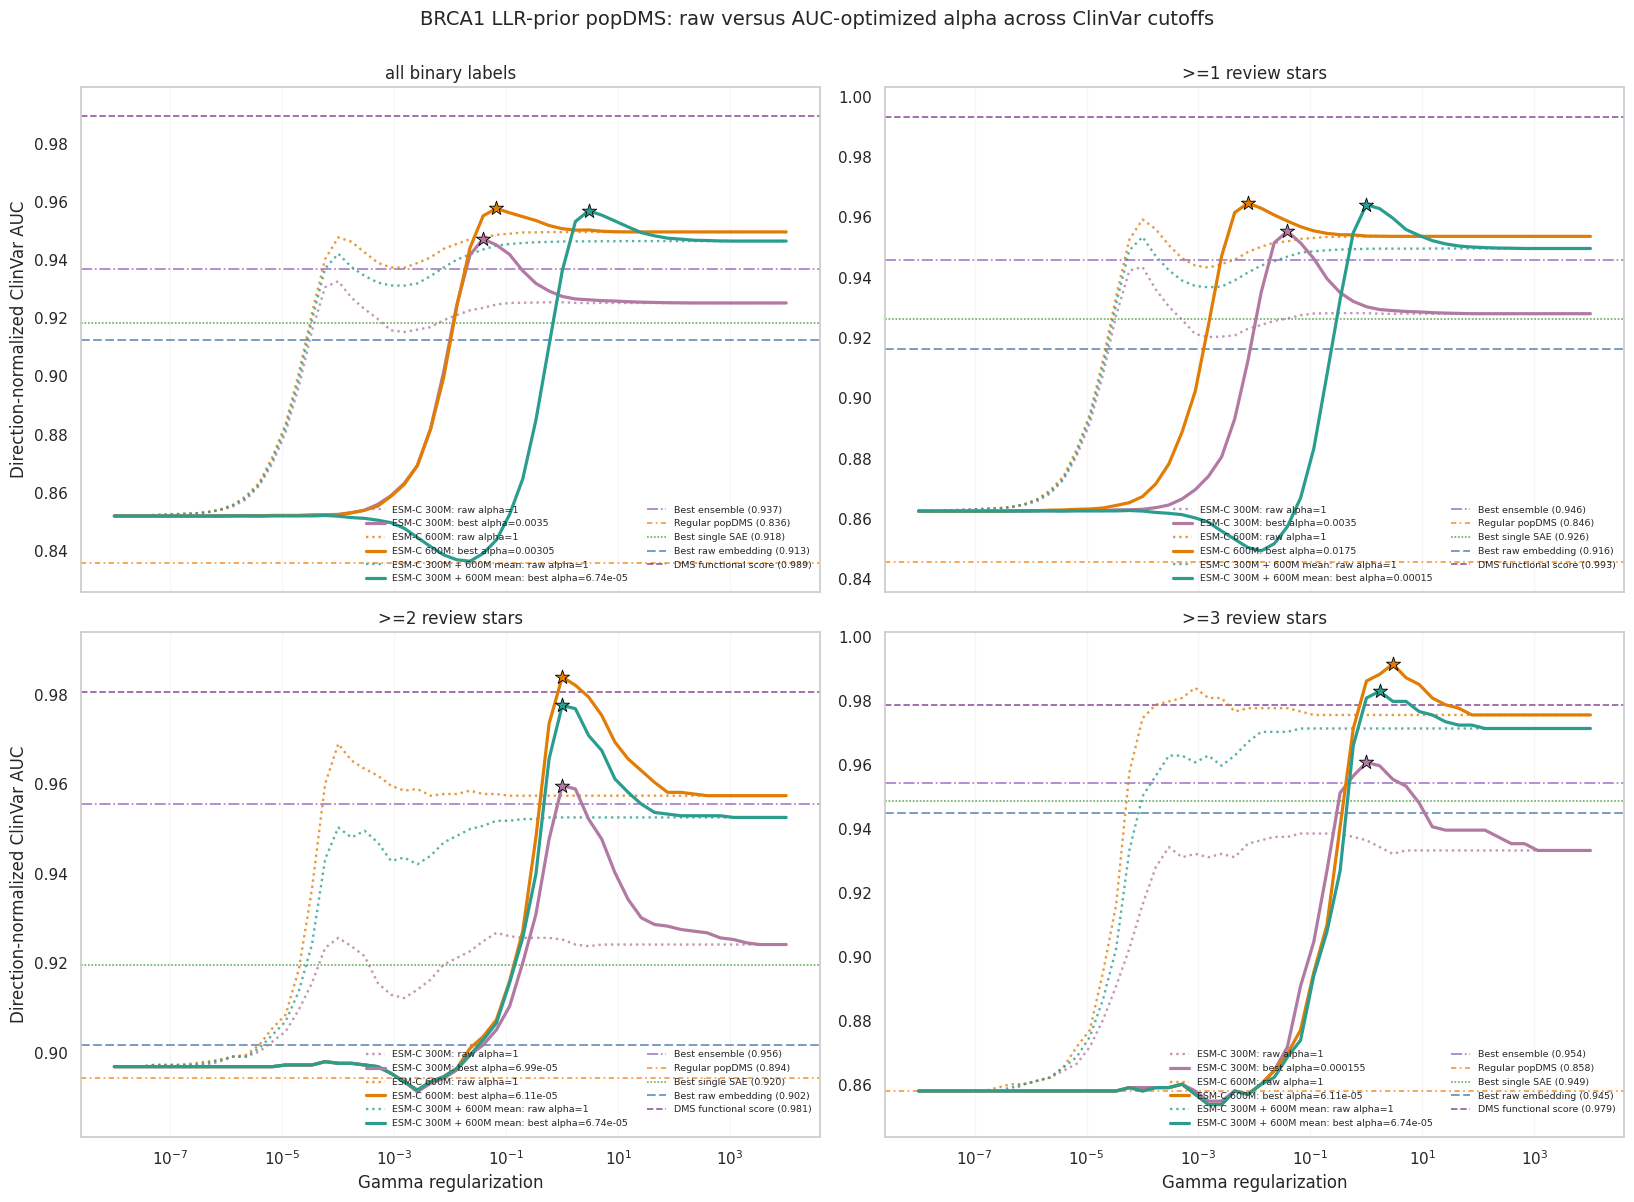

/net/dali/home/barton/dhw28/popDMS/esmDMS/data/clinprotgym_esmc_sae/datasets/MV_BRCA1_Findlay_2018/figures/brca1_sae_downstream/MV_BRCA1_Findlay_2018_three_llr_priors_raw_vs_best_alpha_gamma_profiles_pipeline.png


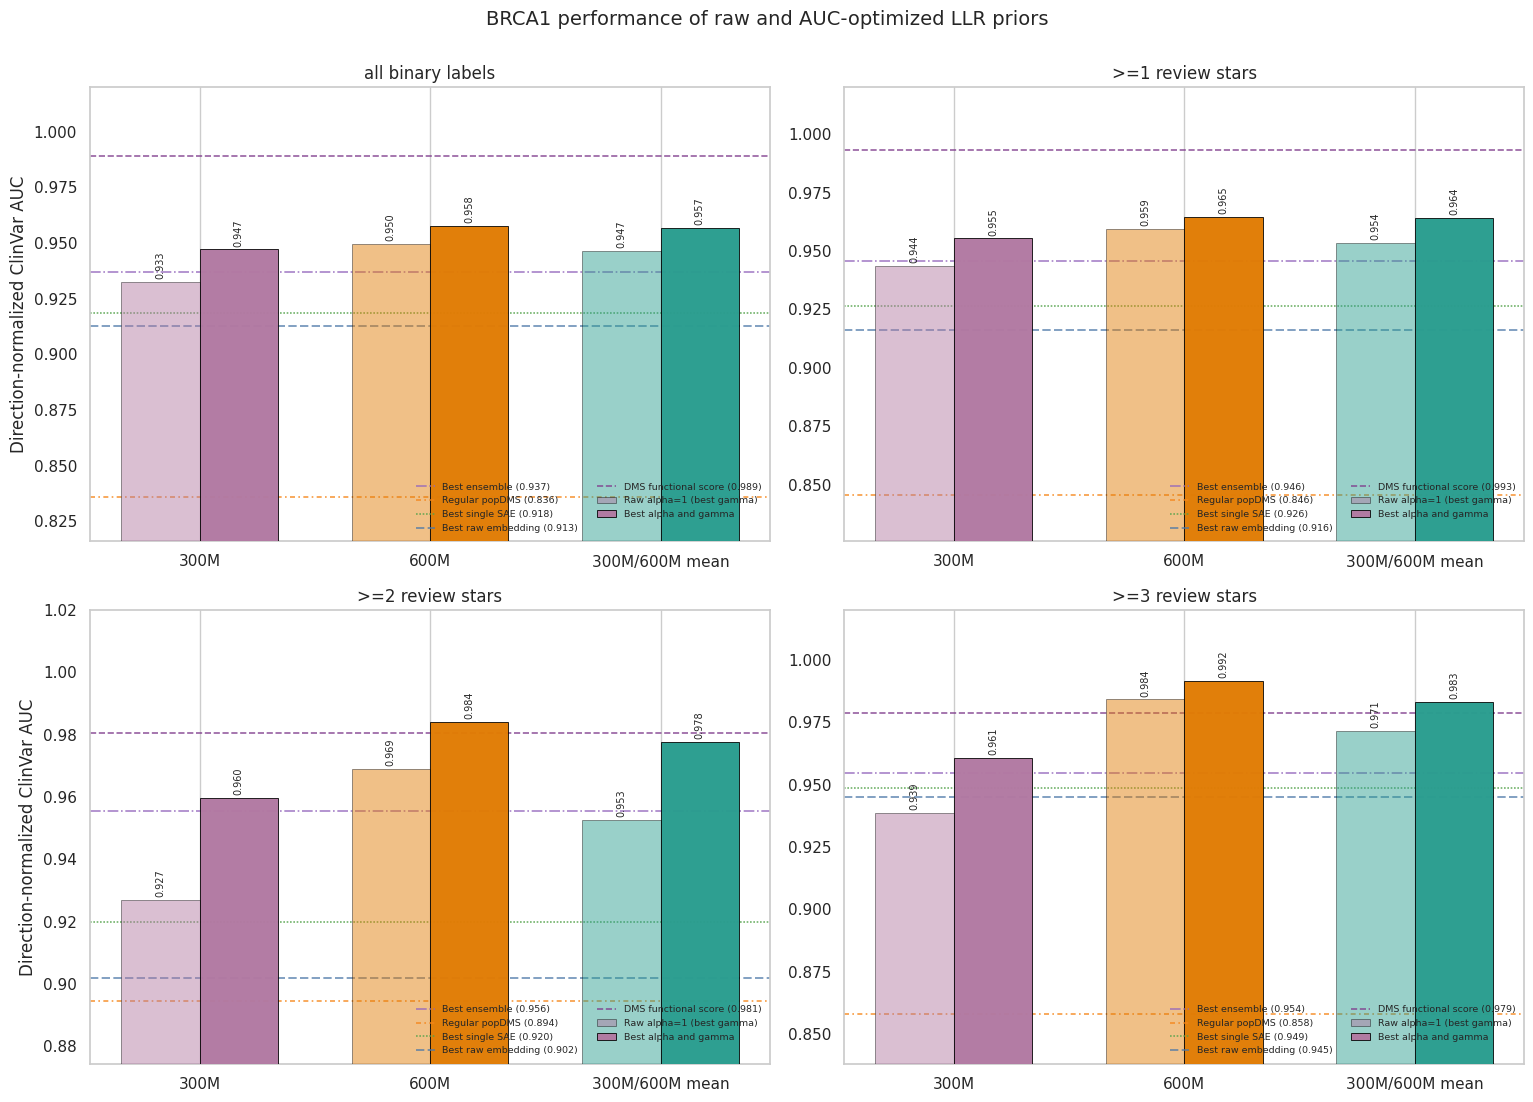

/net/dali/home/barton/dhw28/popDMS/esmDMS/data/clinprotgym_esmc_sae/datasets/MV_BRCA1_Findlay_2018/figures/brca1_sae_downstream/MV_BRCA1_Findlay_2018_three_llr_priors_raw_vs_optimized_auc_pipeline.png


In [39]:
# Mean ESM-C LLR prior: alpha-by-gamma sweep and comparison with the raw-scale priors.
# Here, "unnormalized" means the original LLR amplitude (alpha=1).
plt, sns = ensure_plotting()

MEAN_LLR_PRIOR_LABEL = "ESM-C 300M + 600M mean"
RECOMPUTE_MEAN_LLR_SWEEP = False
mean_llr_path = TABLE_DIR / f"{DATASET}_biohub__ESMC-300M_600M_mean_llr_fitness.csv"
mean_sweep_path = TABLE_DIR / f"{DATASET}_mean_llr_prior_popdms_alpha_gamma_sweep.csv"
three_prior_sweep_path = TABLE_DIR / f"{DATASET}_three_llr_priors_popdms_alpha_gamma_sweep.csv"

llr_300 = pd.read_csv(LLR_PRIOR_POPDMS_MODELS["ESM-C 300M"], usecols=["SequenceIndex", "fitness"])
llr_600 = pd.read_csv(LLR_PRIOR_POPDMS_MODELS["ESM-C 600M"], usecols=["SequenceIndex", "fitness"])
llr_300["SequenceIndex"] = llr_300["SequenceIndex"].astype(str)
llr_600["SequenceIndex"] = llr_600["SequenceIndex"].astype(str)
mean_llr = llr_300.merge(
    llr_600, on="SequenceIndex", how="outer", suffixes=("_300M", "_600M"),
    validate="one_to_one", indicator=True,
)
if not mean_llr["_merge"].eq("both").all():
    missing_counts = mean_llr["_merge"].value_counts().to_dict()
    raise ValueError(f"The 300M and 600M LLR tables cover different variants: {missing_counts}")
mean_llr["fitness"] = mean_llr[["fitness_300M", "fitness_600M"]].mean(axis=1)
mean_llr[["SequenceIndex", "fitness"]].to_csv(mean_llr_path, index=False)
print(mean_llr_path)

if mean_sweep_path.is_file() and not RECOMPUTE_MEAN_LLR_SWEEP:
    mean_llr_alpha_gamma_sweep = pd.read_csv(mean_sweep_path)
    print(f"Loaded cached mean-prior sweep: {mean_sweep_path}")
else:
    if "popdms_selection_std" not in globals():
        popdms_selection_std, popdms_scale_source = regular_popdms_selection_scale(metrics)
    mean_llr_alpha_gamma_sweep, mean_alpha_table, mean_named_alphas = run_llr_alpha_gamma_sweep(
        MEAN_LLR_PRIOR_LABEL, mean_llr_path, popdms_selection_std
    )
    mean_llr_alpha_gamma_sweep.to_csv(mean_sweep_path, index=False)
    print(mean_sweep_path)

base_two_prior_sweep = llr_alpha_gamma_sweep[
    llr_alpha_gamma_sweep["prior_model"].isin(LLR_PRIOR_POPDMS_MODELS)
].copy()
three_prior_alpha_gamma_sweep = pd.concat(
    [base_two_prior_sweep, mean_llr_alpha_gamma_sweep], ignore_index=True
).sort_values(["prior_model", "alpha", "gamma"]).reset_index(drop=True)
three_prior_alpha_gamma_sweep.to_csv(three_prior_sweep_path, index=False)
print(three_prior_sweep_path)

THREE_PRIOR_ORDER = ["ESM-C 300M", "ESM-C 600M", MEAN_LLR_PRIOR_LABEL]
three_prior_colors = {
    "ESM-C 300M": "#B279A2",
    "ESM-C 600M": "#E17C05",
    MEAN_LLR_PRIOR_LABEL: "#2A9D8F",
}
baseline_specs = [
    ("Regular popDMS", "popDMS baseline", "#F58518", (0, (3, 2, 1, 2))),
    ("Best single SAE", "Raw SAE", "#54A24B", (0, (1, 1))),
    ("Best raw embedding", "Raw embeddings", "#4C78A8", (0, (5, 2))),
    ("DMS functional score", "DMS functional score", "#7F3C8D", "--"),
]

def three_prior_auc_baselines(min_stars):
    cutoff_rows = auc_by_labels[auc_by_labels["min_review_stars"].eq(min_stars)].copy()
    cutoff_rows["auc_discrimination"] = safe_numeric(cutoff_rows["auc_discrimination"])
    cutoff_rows["spearman_rho"] = safe_numeric(cutoff_rows.get("spearman_rho", np.nan))
    rows = []
    voting = voting_ensemble_metrics[
        voting_ensemble_metrics["min_review_stars"].eq(min_stars)
    ].copy()
    voting["auc_discrimination"] = safe_numeric(voting["auc_discrimination"])
    voting["spearman_rho"] = safe_numeric(voting["spearman_rho"])
    voting = voting[np.isfinite(voting["auc_discrimination"])]
    if not voting.empty:
        best = voting.sort_values(
            ["auc_discrimination", "spearman_rho"], ascending=[False, False]
        ).iloc[0]
        rows.append({
            "label": "Best ensemble", "auc": float(best["auc_discrimination"]),
            "color": "#9467BD", "linestyle": "-.",
        })
    for label, family, color, linestyle in baseline_specs:
        candidates = cutoff_rows[
            cutoff_rows["method_family"].eq(family)
            & np.isfinite(cutoff_rows["auc_discrimination"])
        ].copy()
        if candidates.empty:
            continue
        best = candidates.sort_values(
            ["auc_discrimination", "spearman_rho"], ascending=[False, False]
        ).iloc[0]
        rows.append({
            "label": label, "auc": float(best["auc_discrimination"]),
            "color": color, "linestyle": linestyle,
        })
    return rows

comparison_rows = []
best_profiles = {}
raw_profiles = {}
for min_stars in LLR_PRIOR_POPDMS_STAR_CUTOFFS:
    auc_column = f"auc_discrimination_stars_{min_stars}"
    for prior_model in THREE_PRIOR_ORDER:
        model_sweep = three_prior_alpha_gamma_sweep[
            three_prior_alpha_gamma_sweep["prior_model"].eq(prior_model)
        ].copy()
        model_sweep[auc_column] = safe_numeric(model_sweep[auc_column])
        raw_profile = model_sweep[np.isclose(model_sweep["alpha"], 1.0)].sort_values("gamma")
        if raw_profile.empty:
            raise ValueError(f"{prior_model} does not contain the raw alpha=1 profile.")
        best_row = model_sweep.sort_values(
            [auc_column, "alpha", "gamma"], ascending=[False, True, True]
        ).iloc[0]
        best_alpha = float(best_row["alpha"])
        best_profile = model_sweep[
            np.isclose(model_sweep["alpha"], best_alpha, rtol=1e-10, atol=1e-15)
        ].sort_values("gamma")
        raw_best = raw_profile.sort_values([auc_column, "gamma"], ascending=[False, True]).iloc[0]
        raw_profiles[(min_stars, prior_model)] = raw_profile
        best_profiles[(min_stars, prior_model)] = best_profile
        comparison_rows.append({
            "min_review_stars": min_stars,
            "prior_model": prior_model,
            "raw_alpha": 1.0,
            "raw_best_gamma": float(raw_best["gamma"]),
            "raw_best_auc_discrimination": float(raw_best[auc_column]),
            "optimized_alpha": best_alpha,
            "optimized_gamma": float(best_row["gamma"]),
            "optimized_auc_discrimination": float(best_row[auc_column]),
        })
three_prior_auc_summary = pd.DataFrame(comparison_rows)
display(three_prior_auc_summary)

# Figure 1: full gamma profiles at raw alpha=1 and at the AUC-optimal alpha.
fig, axes = plt.subplots(2, 2, figsize=(16.5, 12.0), sharex=True, sharey=False)
for ax, min_stars in zip(axes.ravel(), LLR_PRIOR_POPDMS_STAR_CUTOFFS):
    auc_column = f"auc_discrimination_stars_{min_stars}"
    plotted_values = []
    for prior_model in THREE_PRIOR_ORDER:
        color = three_prior_colors[prior_model]
        raw_profile = raw_profiles[(min_stars, prior_model)]
        best_profile = best_profiles[(min_stars, prior_model)]
        best_alpha = float(best_profile["alpha"].iloc[0])
        ax.plot(
            raw_profile["gamma"], raw_profile[auc_column], color=color, linestyle=":",
            linewidth=1.7, alpha=0.78, label=f"{prior_model}: raw alpha=1", zorder=3,
        )
        ax.plot(
            best_profile["gamma"], best_profile[auc_column], color=color, linestyle="-",
            linewidth=2.3, label=f"{prior_model}: best alpha={best_alpha:.3g}", zorder=4,
        )
        best_point = best_profile.sort_values([auc_column, "gamma"], ascending=[False, True]).iloc[0]
        ax.scatter(
            best_point["gamma"], best_point[auc_column], marker="*", s=115,
            color=color, edgecolor="black", linewidth=0.6, zorder=7,
        )
        plotted_values.extend(raw_profile[auc_column].dropna().to_list())
        plotted_values.extend(best_profile[auc_column].dropna().to_list())
    baselines = three_prior_auc_baselines(min_stars)
    for baseline in baselines:
        ax.axhline(
            baseline["auc"], color=baseline["color"], linestyle=baseline["linestyle"],
            linewidth=1.25, alpha=0.82,
            label=f"{baseline['label']} ({baseline['auc']:.3f})", zorder=1,
        )
        plotted_values.append(baseline["auc"])
    span = max(plotted_values) - min(plotted_values)
    padding = max(0.01, 0.06 * span)
    ax.set_ylim(max(0.45, min(plotted_values) - padding), min(1.02, max(plotted_values) + padding))
    ax.set_xscale("log")
    ax.grid(True, which="both", axis="x", alpha=0.16)
    ax.grid(False, axis="y")
    cutoff_label = "all binary labels" if min_stars == 0 else f">={min_stars} review stars"
    ax.set_title(cutoff_label)
    ax.legend(frameon=False, fontsize=6.8, ncol=2, loc="lower right")
for ax in axes[-1]:
    ax.set_xlabel("Gamma regularization")
for ax in axes[:, 0]:
    ax.set_ylabel("Direction-normalized ClinVar AUC")
fig.suptitle(
    "BRCA1 LLR-prior popDMS: raw versus AUC-optimized alpha across ClinVar cutoffs",
    y=1.0, fontsize=14,
)
fig.tight_layout()
profile_out = FIGURE_DIR / f"{DATASET}_three_llr_priors_raw_vs_best_alpha_gamma_profiles_{CLINICAL_LABEL_MODE}.png"
fig.savefig(profile_out, dpi=300, bbox_inches="tight")
plt.show()
print(profile_out)

# Figure 2: the best AUC attainable at raw alpha=1 versus the fully optimized alpha/gamma sweep.
fig, axes = plt.subplots(2, 2, figsize=(15.5, 11.0), sharey=False)
x = np.arange(len(THREE_PRIOR_ORDER))
width = 0.34
for ax, min_stars in zip(axes.ravel(), LLR_PRIOR_POPDMS_STAR_CUTOFFS):
    panel = (
        three_prior_auc_summary[three_prior_auc_summary["min_review_stars"].eq(min_stars)]
        .set_index("prior_model").loc[THREE_PRIOR_ORDER]
    )
    raw_bars = ax.bar(
        x - width / 2, panel["raw_best_auc_discrimination"], width,
        color=[three_prior_colors[name] for name in THREE_PRIOR_ORDER], alpha=0.48,
        edgecolor="black", linewidth=0.6, label="Raw alpha=1 (best gamma)", zorder=3,
    )
    optimized_bars = ax.bar(
        x + width / 2, panel["optimized_auc_discrimination"], width,
        color=[three_prior_colors[name] for name in THREE_PRIOR_ORDER], alpha=0.98,
        edgecolor="black", linewidth=0.6, label="Best alpha and gamma", zorder=3,
    )
    plotted_values = list(panel["raw_best_auc_discrimination"]) + list(panel["optimized_auc_discrimination"])
    for baseline in three_prior_auc_baselines(min_stars):
        ax.axhline(
            baseline["auc"], color=baseline["color"], linestyle=baseline["linestyle"],
            linewidth=1.2, alpha=0.82, label=f"{baseline['label']} ({baseline['auc']:.3f})", zorder=1,
        )
        plotted_values.append(baseline["auc"])
    ax.bar_label(raw_bars, fmt="%.3f", padding=2, fontsize=7, rotation=90)
    ax.bar_label(optimized_bars, fmt="%.3f", padding=2, fontsize=7, rotation=90)
    span = max(plotted_values) - min(plotted_values)
    padding = max(0.02, 0.10 * span)
    ax.set_ylim(max(0.45, min(plotted_values) - padding), min(1.02, max(plotted_values) + 2 * padding))
    ax.set_xticks(x)
    ax.set_xticklabels(["300M", "600M", "300M/600M mean"])
    cutoff_label = "all binary labels" if min_stars == 0 else f">={min_stars} review stars"
    ax.set_title(cutoff_label)
    ax.grid(False, axis="y")
    ax.legend(frameon=False, fontsize=6.8, ncol=2, loc="lower right")
for ax in axes[:, 0]:
    ax.set_ylabel("Direction-normalized ClinVar AUC")
fig.suptitle("BRCA1 performance of raw and AUC-optimized LLR priors", y=1.0, fontsize=14)
fig.tight_layout()
bar_out = FIGURE_DIR / f"{DATASET}_three_llr_priors_raw_vs_optimized_auc_{CLINICAL_LABEL_MODE}.png"
fig.savefig(bar_out, dpi=300, bbox_inches="tight")
plt.show()
print(bar_out)


,n,mean,std,median,median_absolute_deviation,rms_magnitude,mean_absolute_magnitude,median_absolute_magnitude,min,q01,q05,q25,q75,q95,q99,max,full_range,max_absolute_magnitude
model,,,,,,,,,,,,,,,,,,
ESM-C 300M,1837,-3.848702,3.816535,-2.954594,2.606888,5.419457,4.097097,2.997482,-15.612517,-13.014764,-11.019972,-6.425534,-0.760509,0.893920,2.298624,4.787117,20.399634,15.612517
ESM-C 600M,1837,-5.175948,4.368287,-4.730703,3.229140,6.772148,5.402464,4.746039,-20.703962,-15.397161,-13.127622,-8.110236,-1.668915,0.803895,2.614741,5.055975,25.759937,20.703962


,n_paired_variants,pearson_r,spearman_rho,ols_600M_on_300M_slope,ols_intercept,600M_to_300M_std_ratio,600M_to_300M_range_ratio,600M_to_300M_rms_ratio,median_abs_600M_to_300M_ratio,sign_agreement_fraction,mean_600M_minus_300M,std_600M_minus_300M,rmse_between_models
0,1837,0.870445,0.859197,0.996285,-1.341546,1.144569,1.262765,1.249599,1.30738,0.890582,-1.327246,2.150402,2.526518


/net/dali/home/barton/dhw28/popDMS/esmDMS/data/clinprotgym_esmc_sae/datasets/MV_BRCA1_Findlay_2018/tables/MV_BRCA1_Findlay_2018_300M_600M_llr_scale_summary.csv


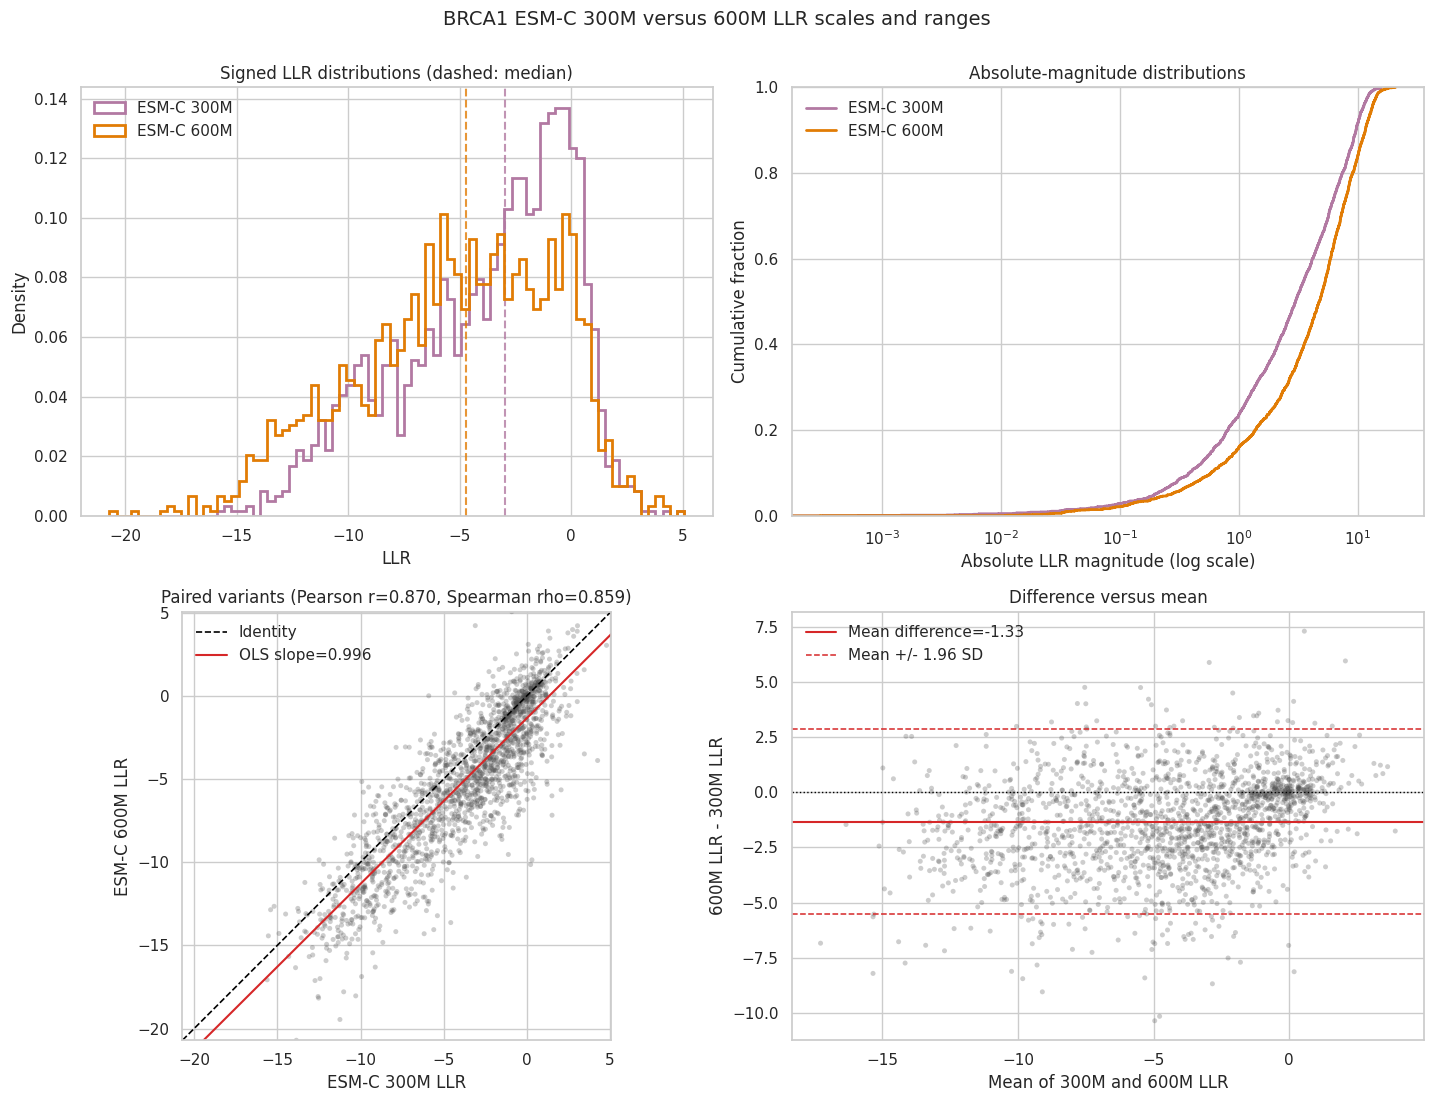

/net/dali/home/barton/dhw28/popDMS/esmDMS/data/clinprotgym_esmc_sae/datasets/MV_BRCA1_Findlay_2018/figures/brca1_sae_downstream/MV_BRCA1_Findlay_2018_300M_vs_600M_llr_scale_distributions.png


In [40]:
# Compare the native scales and paired distributions of the 300M and 600M LLRs.
plt, sns = ensure_plotting()

llr_scale_frames = []
for model_label, llr_path in LLR_PRIOR_POPDMS_MODELS.items():
    frame = pd.read_csv(llr_path, usecols=["SequenceIndex", "fitness"]).rename(
        columns={"fitness": "llr"}
    )
    frame["SequenceIndex"] = frame["SequenceIndex"].astype(str)
    frame["llr"] = safe_numeric(frame["llr"])
    frame["model"] = model_label
    llr_scale_frames.append(frame)
llr_scale_long = pd.concat(llr_scale_frames, ignore_index=True)
llr_scale_long = llr_scale_long[np.isfinite(llr_scale_long["llr"])].copy()

llr_scale_wide = (
    llr_scale_long.pivot(index="SequenceIndex", columns="model", values="llr")
    .dropna(subset=["ESM-C 300M", "ESM-C 600M"])
    .reset_index()
)
llr_300_values = llr_scale_wide["ESM-C 300M"].to_numpy(dtype=float)
llr_600_values = llr_scale_wide["ESM-C 600M"].to_numpy(dtype=float)

def llr_distribution_summary(model_label, values):
    values = np.asarray(values, dtype=float)
    absolute = np.abs(values)
    median = float(np.median(values))
    return {
        "model": model_label,
        "n": len(values),
        "mean": float(np.mean(values)),
        "std": float(np.std(values, ddof=1)),
        "median": median,
        "median_absolute_deviation": float(np.median(np.abs(values - median))),
        "rms_magnitude": float(np.sqrt(np.mean(values ** 2))),
        "mean_absolute_magnitude": float(np.mean(absolute)),
        "median_absolute_magnitude": float(np.median(absolute)),
        "min": float(np.min(values)),
        "q01": float(np.quantile(values, 0.01)),
        "q05": float(np.quantile(values, 0.05)),
        "q25": float(np.quantile(values, 0.25)),
        "q75": float(np.quantile(values, 0.75)),
        "q95": float(np.quantile(values, 0.95)),
        "q99": float(np.quantile(values, 0.99)),
        "max": float(np.max(values)),
        "full_range": float(np.ptp(values)),
        "max_absolute_magnitude": float(np.max(absolute)),
    }

llr_scale_summary = pd.DataFrame([
    llr_distribution_summary("ESM-C 300M", llr_300_values),
    llr_distribution_summary("ESM-C 600M", llr_600_values),
]).set_index("model")
display(llr_scale_summary)

llr_difference = llr_600_values - llr_300_values
paired_mean = 0.5 * (llr_300_values + llr_600_values)
pearson_value = float(pearsonr(llr_300_values, llr_600_values).statistic)
spearman_value = float(spearmanr(llr_300_values, llr_600_values).statistic)
linear_slope, linear_intercept = np.polyfit(llr_300_values, llr_600_values, deg=1)
nonzero = (np.abs(llr_300_values) > np.finfo(float).eps) & (np.abs(llr_600_values) > np.finfo(float).eps)
llr_scale_comparison = pd.DataFrame([{
    "n_paired_variants": len(llr_scale_wide),
    "pearson_r": pearson_value,
    "spearman_rho": spearman_value,
    "ols_600M_on_300M_slope": float(linear_slope),
    "ols_intercept": float(linear_intercept),
    "600M_to_300M_std_ratio": float(np.std(llr_600_values, ddof=1) / np.std(llr_300_values, ddof=1)),
    "600M_to_300M_range_ratio": float(np.ptp(llr_600_values) / np.ptp(llr_300_values)),
    "600M_to_300M_rms_ratio": float(
        np.sqrt(np.mean(llr_600_values ** 2)) / np.sqrt(np.mean(llr_300_values ** 2))
    ),
    "median_abs_600M_to_300M_ratio": float(np.median(
        np.abs(llr_600_values[nonzero]) / np.abs(llr_300_values[nonzero])
    )),
    "sign_agreement_fraction": float(np.mean(np.sign(llr_300_values) == np.sign(llr_600_values))),
    "mean_600M_minus_300M": float(np.mean(llr_difference)),
    "std_600M_minus_300M": float(np.std(llr_difference, ddof=1)),
    "rmse_between_models": float(np.sqrt(np.mean(llr_difference ** 2))),
}])
display(llr_scale_comparison)

llr_scale_summary_path = TABLE_DIR / f"{DATASET}_300M_600M_llr_scale_summary.csv"
llr_scale_summary.reset_index().to_csv(llr_scale_summary_path, index=False)
print(llr_scale_summary_path)

model_colors = {"ESM-C 300M": "#B279A2", "ESM-C 600M": "#E17C05"}
fig, axes = plt.subplots(2, 2, figsize=(14.5, 11.0))

# Native signed LLR distributions on common bins.
signed_min = float(min(llr_300_values.min(), llr_600_values.min()))
signed_max = float(max(llr_300_values.max(), llr_600_values.max()))
signed_bins = np.linspace(signed_min, signed_max, 81)
for model_label, values in [("ESM-C 300M", llr_300_values), ("ESM-C 600M", llr_600_values)]:
    axes[0, 0].hist(
        values, bins=signed_bins, density=True, histtype="step", linewidth=2.0,
        color=model_colors[model_label], label=model_label,
    )
    axes[0, 0].axvline(np.median(values), color=model_colors[model_label], linestyle="--", alpha=0.8)
axes[0, 0].set_xlabel("LLR")
axes[0, 0].set_ylabel("Density")
axes[0, 0].set_title("Signed LLR distributions (dashed: median)")
axes[0, 0].legend(frameon=False)

# Absolute-magnitude ECDF makes multiplicative scale differences visible.
for model_label, values in [("ESM-C 300M", llr_300_values), ("ESM-C 600M", llr_600_values)]:
    positive_magnitudes = np.abs(values)[np.abs(values) > 0]
    sns.ecdfplot(
        x=positive_magnitudes, ax=axes[0, 1], color=model_colors[model_label],
        linewidth=2.0, label=model_label,
    )
axes[0, 1].set_xscale("log")
axes[0, 1].set_xlabel("Absolute LLR magnitude (log scale)")
axes[0, 1].set_ylabel("Cumulative fraction")
axes[0, 1].set_title("Absolute-magnitude distributions")
axes[0, 1].legend(frameon=False)

# Per-variant correspondence, with identity and fitted scale relationship.
point_limits = [signed_min, signed_max]
axes[1, 0].scatter(
    llr_300_values, llr_600_values, s=13, alpha=0.28, color="#4D4D4D", edgecolor="none"
)
axes[1, 0].plot(point_limits, point_limits, color="black", linestyle="--", linewidth=1.2, label="Identity")
fit_x = np.asarray(point_limits)
axes[1, 0].plot(
    fit_x, linear_intercept + linear_slope * fit_x, color="#D62728", linewidth=1.5,
    label=f"OLS slope={linear_slope:.3f}",
)
axes[1, 0].set_xlim(point_limits)
axes[1, 0].set_ylim(point_limits)
axes[1, 0].set_aspect("equal", adjustable="box")
axes[1, 0].set_xlabel("ESM-C 300M LLR")
axes[1, 0].set_ylabel("ESM-C 600M LLR")
axes[1, 0].set_title(f"Paired variants (Pearson r={pearson_value:.3f}, Spearman rho={spearman_value:.3f})")
axes[1, 0].legend(frameon=False)

# Difference-versus-mean plot shows scale-dependent disagreement and the full difference range.
difference_mean = float(np.mean(llr_difference))
difference_std = float(np.std(llr_difference, ddof=1))
axes[1, 1].scatter(
    paired_mean, llr_difference, s=13, alpha=0.28, color="#4D4D4D", edgecolor="none"
)
axes[1, 1].axhline(difference_mean, color="#D62728", linewidth=1.5, label=f"Mean difference={difference_mean:.3g}")
axes[1, 1].axhline(difference_mean + 1.96 * difference_std, color="#D62728", linestyle="--", linewidth=1.1)
axes[1, 1].axhline(difference_mean - 1.96 * difference_std, color="#D62728", linestyle="--", linewidth=1.1, label="Mean +/- 1.96 SD")
axes[1, 1].axhline(0, color="black", linestyle=":", linewidth=1.0)
axes[1, 1].set_xlabel("Mean of 300M and 600M LLR")
axes[1, 1].set_ylabel("600M LLR - 300M LLR")
axes[1, 1].set_title("Difference versus mean")
axes[1, 1].legend(frameon=False)

fig.suptitle("BRCA1 ESM-C 300M versus 600M LLR scales and ranges", y=1.0, fontsize=14)
fig.tight_layout()
llr_scale_figure_path = FIGURE_DIR / f"{DATASET}_300M_vs_600M_llr_scale_distributions.png"
fig.savefig(llr_scale_figure_path, dpi=300, bbox_inches="tight")
plt.show()
print(llr_scale_figure_path)


Loaded cached sweep: /net/dali/home/barton/dhw28/popDMS/esmDMS/data/clinprotgym_esmc_sae/datasets/MV_BRCA1_Findlay_2018/tables/MV_BRCA1_Findlay_2018_raw_min_llr_prior_popdms_alpha_gamma_sweep.csv
Loaded cached sweep: /net/dali/home/barton/dhw28/popDMS/esmDMS/data/clinprotgym_esmc_sae/datasets/MV_BRCA1_Findlay_2018/tables/MV_BRCA1_Findlay_2018_raw_max_llr_prior_popdms_alpha_gamma_sweep.csv
Loaded cached sweep: /net/dali/home/barton/dhw28/popDMS/esmDMS/data/clinprotgym_esmc_sae/datasets/MV_BRCA1_Findlay_2018/tables/MV_BRCA1_Findlay_2018_zscore_min_llr_prior_popdms_alpha_gamma_sweep.csv
Loaded cached sweep: /net/dali/home/barton/dhw28/popDMS/esmDMS/data/clinprotgym_esmc_sae/datasets/MV_BRCA1_Findlay_2018/tables/MV_BRCA1_Findlay_2018_zscore_mean_llr_prior_popdms_alpha_gamma_sweep.csv
Loaded cached sweep: /net/dali/home/barton/dhw28/popDMS/esmDMS/data/clinprotgym_esmc_sae/datasets/MV_BRCA1_Findlay_2018/tables/MV_BRCA1_Findlay_2018_zscore_max_llr_prior_popdms_alpha_gamma_sweep.csv
/net/dali/

,prior_model,mean,std,min,median,max,full_range
0,"Raw min(300M, 600M)",-5.477691e+00,4.238122,-20.703962,-5.010480,3.043365,23.747327
1,"Raw max(300M, 600M)",-3.546960e+00,3.834395,-15.612517,-2.705931,5.055975,20.668492
2,"Z-score min(300M, 600M)",-1.965692e-01,0.998023,-3.554715,-0.042019,1.879223,5.433937
3,"Z-score mean(300M, 600M)",3.867952e-18,0.967069,-3.088667,0.166630,2.070981,5.159648
4,"Z-score max(300M, 600M)",1.965692e-01,0.962616,-2.723029,0.377708,2.342320,5.065349


,min_review_stars,prior_model,raw_alpha,raw_best_gamma,raw_best_auc_discrimination,optimized_alpha,optimized_gamma,optimized_auc_discrimination
0,0,"Raw min(300M, 600M)",1.0,1.719072,0.946119,0.000141,1.719072,0.955321
1,0,"Raw max(300M, 600M)",1.0,0.000100,0.939395,0.001692,0.114505,0.954558
2,0,"Z-score min(300M, 600M)",1.0,0.196842,0.939252,0.004150,0.196842,0.951125
3,0,"Z-score mean(300M, 600M)",1.0,1.000000,0.945546,0.000546,1.719072,0.956704
4,0,"Z-score max(300M, 600M)",1.0,0.000508,0.945928,0.001085,0.581709,0.958087
5,1,"Raw min(300M, 600M)",1.0,0.000100,0.954255,0.003544,0.038747,0.961822
6,1,"Raw max(300M, 600M)",1.0,0.000100,0.950423,0.003479,0.038747,0.962461
7,1,"Z-score min(300M, 600M)",1.0,0.000296,0.949391,0.016351,0.038747,0.958235
8,1,"Z-score mean(300M, 600M)",1.0,0.000296,0.952928,0.001081,0.581709,0.963886
9,1,"Z-score max(300M, 600M)",1.0,0.000508,0.956810,0.013859,0.038747,0.966883


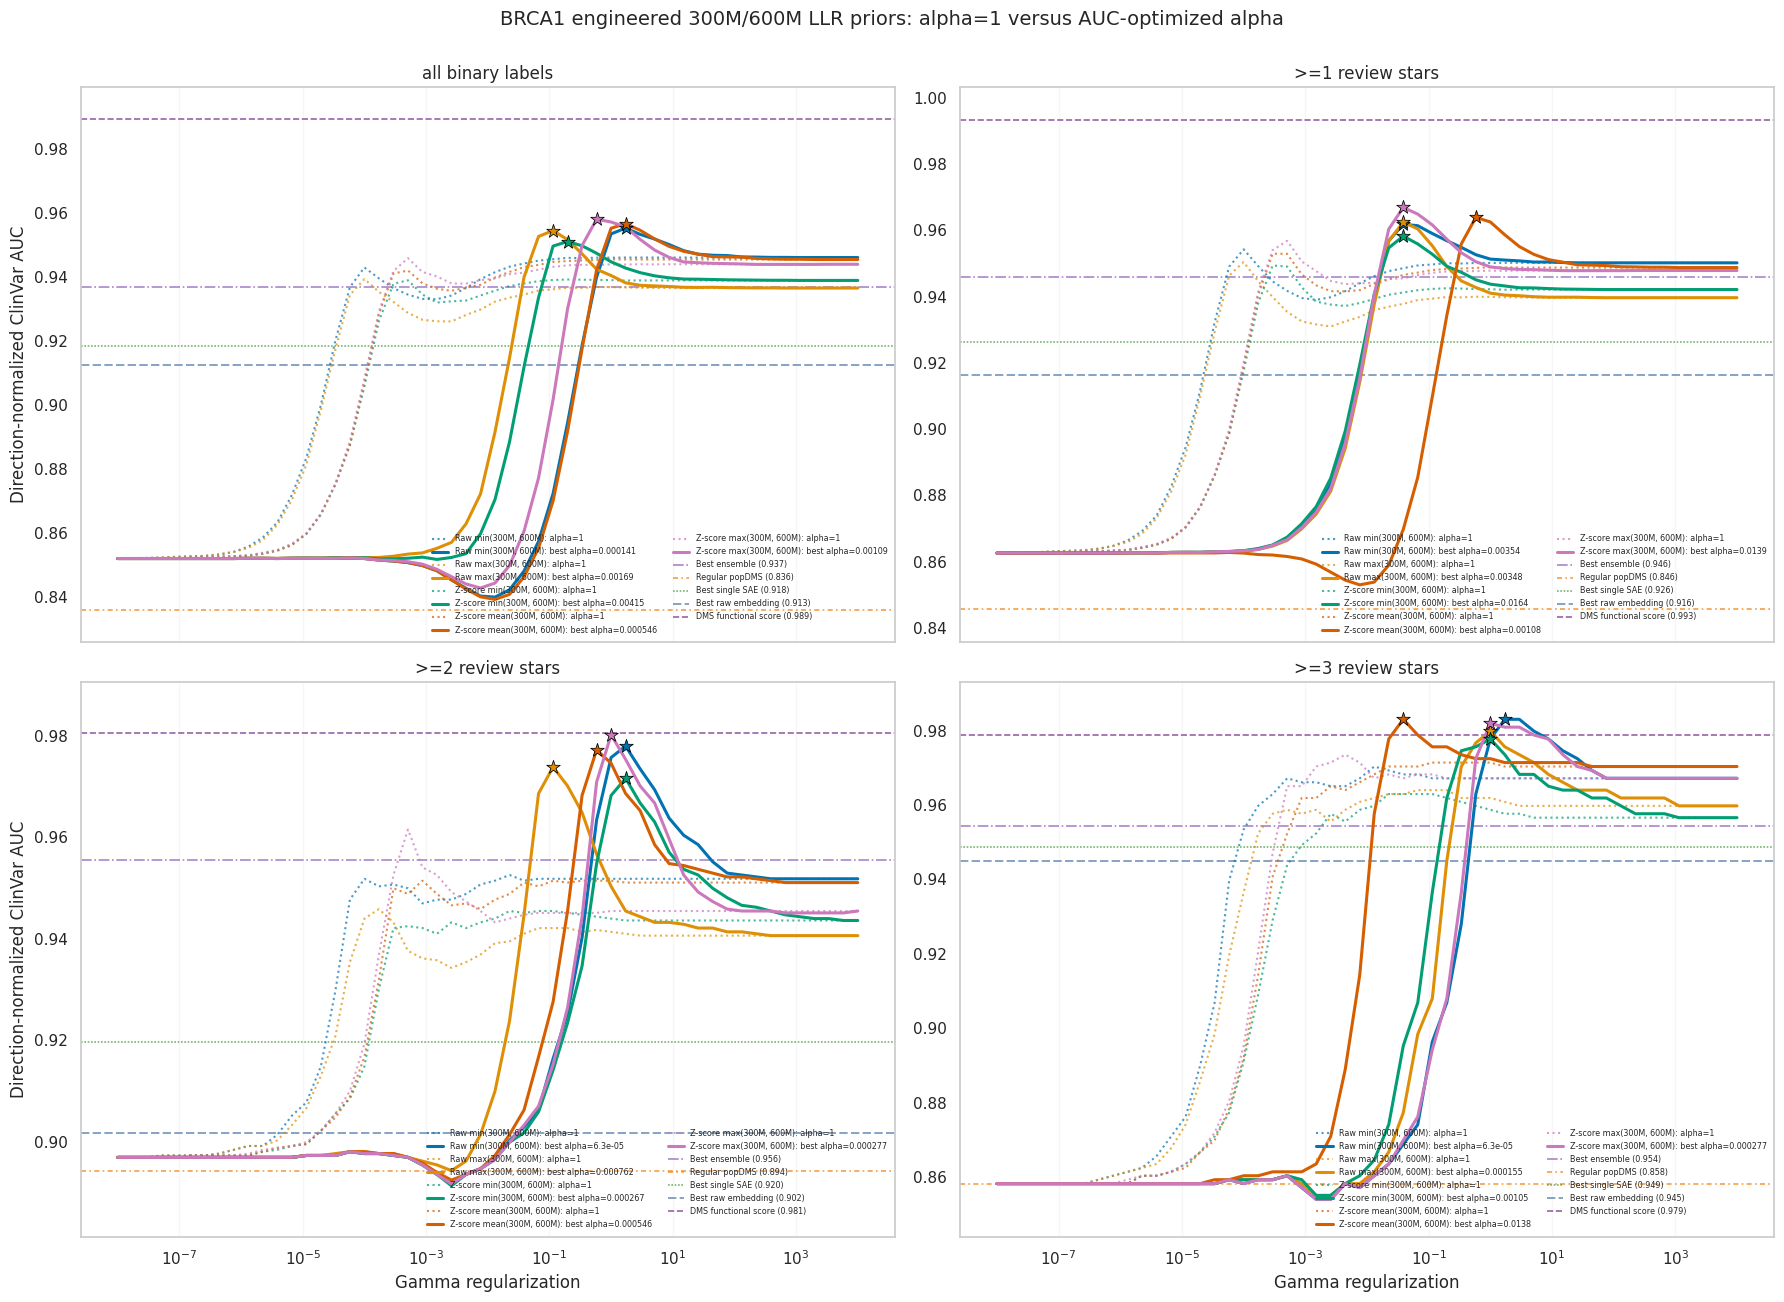

/net/dali/home/barton/dhw28/popDMS/esmDMS/data/clinprotgym_esmc_sae/datasets/MV_BRCA1_Findlay_2018/figures/brca1_sae_downstream/MV_BRCA1_Findlay_2018_engineered_llr_priors_raw_vs_best_alpha_profiles_pipeline.png


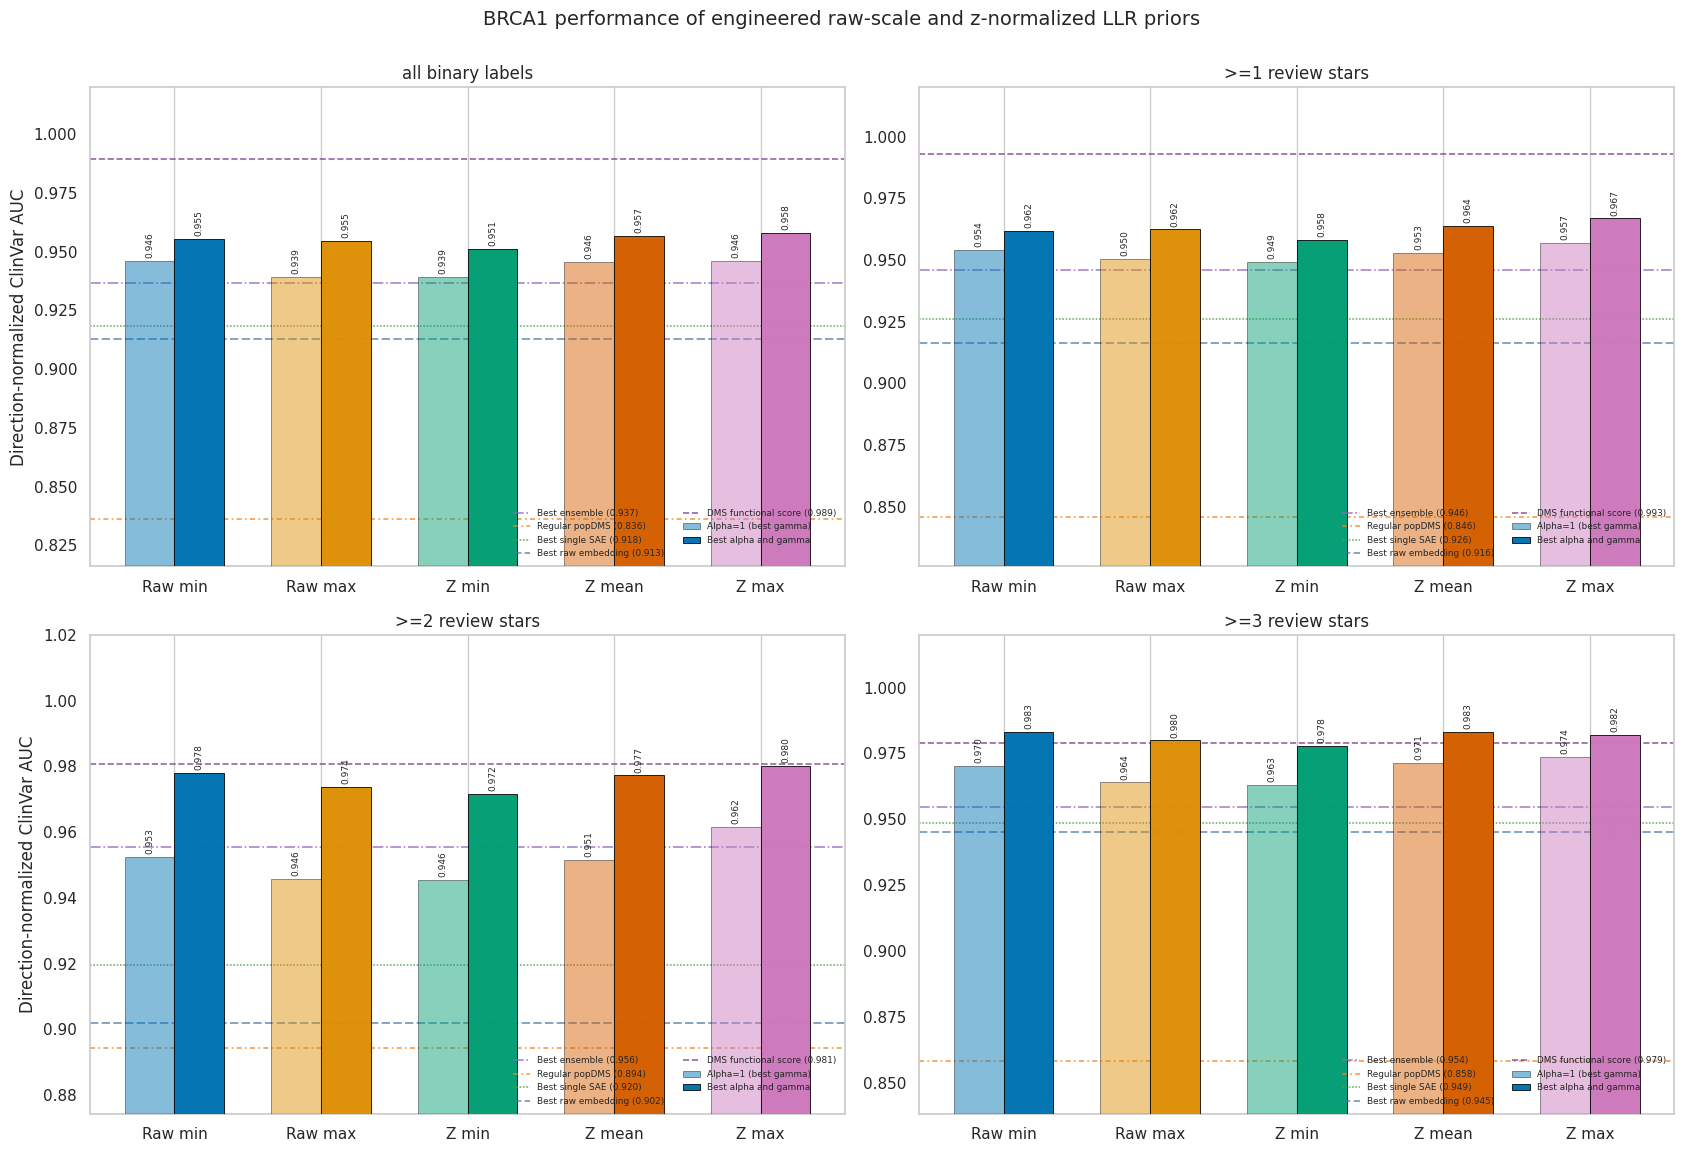

/net/dali/home/barton/dhw28/popDMS/esmDMS/data/clinprotgym_esmc_sae/datasets/MV_BRCA1_Findlay_2018/figures/brca1_sae_downstream/MV_BRCA1_Findlay_2018_engineered_llr_priors_raw_vs_optimized_auc_pipeline.png


In [41]:
# Engineered 300M/600M priors: raw min/max and z-normalized min/mean/max.
plt, sns = ensure_plotting()

RECOMPUTE_ENGINEERED_LLR_SWEEPS = False
engineered_source_300 = pd.read_csv(
    LLR_PRIOR_POPDMS_MODELS["ESM-C 300M"], usecols=["SequenceIndex", "fitness"]
).rename(columns={"fitness": "llr_300M"})
engineered_source_600 = pd.read_csv(
    LLR_PRIOR_POPDMS_MODELS["ESM-C 600M"], usecols=["SequenceIndex", "fitness"]
).rename(columns={"fitness": "llr_600M"})
engineered_source_300["SequenceIndex"] = engineered_source_300["SequenceIndex"].astype(str)
engineered_source_600["SequenceIndex"] = engineered_source_600["SequenceIndex"].astype(str)
engineered_source = engineered_source_300.merge(
    engineered_source_600, on="SequenceIndex", how="outer", validate="one_to_one", indicator=True
)
if not engineered_source["_merge"].eq("both").all():
    raise ValueError("The 300M and 600M LLR files do not contain the same variants.")
for column in ["llr_300M", "llr_600M"]:
    engineered_source[column] = safe_numeric(engineered_source[column])
if not np.isfinite(engineered_source[["llr_300M", "llr_600M"]].to_numpy(dtype=float)).all():
    raise ValueError("The source LLR files contain missing or non-finite values.")

raw_300 = engineered_source["llr_300M"].to_numpy(dtype=float)
raw_600 = engineered_source["llr_600M"].to_numpy(dtype=float)
z_300 = (raw_300 - raw_300.mean()) / raw_300.std(ddof=1)
z_600 = (raw_600 - raw_600.mean()) / raw_600.std(ddof=1)

ENGINEERED_LLR_PRIORS = {
    "Raw min(300M, 600M)": {"slug": "raw_min", "values": np.minimum(raw_300, raw_600)},
    "Raw max(300M, 600M)": {"slug": "raw_max", "values": np.maximum(raw_300, raw_600)},
    "Z-score min(300M, 600M)": {"slug": "zscore_min", "values": np.minimum(z_300, z_600)},
    "Z-score mean(300M, 600M)": {"slug": "zscore_mean", "values": 0.5 * (z_300 + z_600)},
    "Z-score max(300M, 600M)": {"slug": "zscore_max", "values": np.maximum(z_300, z_600)},
}

if "popdms_selection_std" not in globals():
    popdms_selection_std, popdms_scale_source = regular_popdms_selection_scale(metrics)

engineered_sweep_frames = []
engineered_prior_distribution_rows = []
for prior_label, spec in ENGINEERED_LLR_PRIORS.items():
    values = np.asarray(spec["values"], dtype=float)
    prior_path = TABLE_DIR / f"{DATASET}_{spec['slug']}_300M_600M_llr_fitness.csv"
    sweep_path = TABLE_DIR / f"{DATASET}_{spec['slug']}_llr_prior_popdms_alpha_gamma_sweep.csv"
    pd.DataFrame({
        "SequenceIndex": engineered_source["SequenceIndex"], "fitness": values
    }).to_csv(prior_path, index=False)
    if sweep_path.is_file() and not RECOMPUTE_ENGINEERED_LLR_SWEEPS:
        prior_sweep = pd.read_csv(sweep_path)
        print(f"Loaded cached sweep: {sweep_path}")
    else:
        prior_sweep, prior_alpha_table, prior_named_alphas = run_llr_alpha_gamma_sweep(
            prior_label, prior_path, popdms_selection_std
        )
        prior_sweep.to_csv(sweep_path, index=False)
        print(sweep_path)
    engineered_sweep_frames.append(prior_sweep)
    engineered_prior_distribution_rows.append({
        "prior_model": prior_label,
        "mean": float(values.mean()),
        "std": float(values.std(ddof=1)),
        "min": float(values.min()),
        "median": float(np.median(values)),
        "max": float(values.max()),
        "full_range": float(np.ptp(values)),
    })

engineered_llr_alpha_gamma_sweep = (
    pd.concat(engineered_sweep_frames, ignore_index=True)
    .sort_values(["prior_model", "alpha", "gamma"]).reset_index(drop=True)
)
engineered_sweep_path = TABLE_DIR / f"{DATASET}_engineered_llr_priors_alpha_gamma_sweep.csv"
engineered_llr_alpha_gamma_sweep.to_csv(engineered_sweep_path, index=False)
print(engineered_sweep_path)
engineered_prior_distribution_summary = pd.DataFrame(engineered_prior_distribution_rows)
display(engineered_prior_distribution_summary)

ENGINEERED_PRIOR_ORDER = list(ENGINEERED_LLR_PRIORS)
engineered_colors = dict(zip(
    ENGINEERED_PRIOR_ORDER, sns.color_palette("colorblind", len(ENGINEERED_PRIOR_ORDER))
))
engineered_comparison_rows = []
engineered_raw_profiles = {}
engineered_best_profiles = {}
for min_stars in LLR_PRIOR_POPDMS_STAR_CUTOFFS:
    auc_column = f"auc_discrimination_stars_{min_stars}"
    for prior_model in ENGINEERED_PRIOR_ORDER:
        model_sweep = engineered_llr_alpha_gamma_sweep[
            engineered_llr_alpha_gamma_sweep["prior_model"].eq(prior_model)
        ].copy()
        model_sweep[auc_column] = safe_numeric(model_sweep[auc_column])
        raw_profile = model_sweep[np.isclose(model_sweep["alpha"], 1.0)].sort_values("gamma")
        if raw_profile.empty:
            raise ValueError(f"{prior_model} is missing its alpha=1 profile.")
        best_row = model_sweep.sort_values(
            [auc_column, "alpha", "gamma"], ascending=[False, True, True]
        ).iloc[0]
        best_alpha = float(best_row["alpha"])
        best_profile = model_sweep[
            np.isclose(model_sweep["alpha"], best_alpha, rtol=1e-10, atol=1e-15)
        ].sort_values("gamma")
        raw_best = raw_profile.sort_values([auc_column, "gamma"], ascending=[False, True]).iloc[0]
        engineered_raw_profiles[(min_stars, prior_model)] = raw_profile
        engineered_best_profiles[(min_stars, prior_model)] = best_profile
        engineered_comparison_rows.append({
            "min_review_stars": min_stars,
            "prior_model": prior_model,
            "raw_alpha": 1.0,
            "raw_best_gamma": float(raw_best["gamma"]),
            "raw_best_auc_discrimination": float(raw_best[auc_column]),
            "optimized_alpha": best_alpha,
            "optimized_gamma": float(best_row["gamma"]),
            "optimized_auc_discrimination": float(best_row[auc_column]),
        })
engineered_prior_auc_summary = pd.DataFrame(engineered_comparison_rows)
display(engineered_prior_auc_summary)

# Full gamma profiles for alpha=1 and the cutoff-specific AUC-optimal alpha.
fig, axes = plt.subplots(2, 2, figsize=(18.0, 13.0), sharex=True, sharey=False)
for ax, min_stars in zip(axes.ravel(), LLR_PRIOR_POPDMS_STAR_CUTOFFS):
    auc_column = f"auc_discrimination_stars_{min_stars}"
    plotted_values = []
    for prior_model in ENGINEERED_PRIOR_ORDER:
        color = engineered_colors[prior_model]
        raw_profile = engineered_raw_profiles[(min_stars, prior_model)]
        best_profile = engineered_best_profiles[(min_stars, prior_model)]
        best_alpha = float(best_profile["alpha"].iloc[0])
        ax.plot(
            raw_profile["gamma"], raw_profile[auc_column], color=color, linestyle=":",
            linewidth=1.5, alpha=0.72, label=f"{prior_model}: alpha=1", zorder=3,
        )
        ax.plot(
            best_profile["gamma"], best_profile[auc_column], color=color, linestyle="-",
            linewidth=2.2, label=f"{prior_model}: best alpha={best_alpha:.3g}", zorder=4,
        )
        best_point = best_profile.sort_values([auc_column, "gamma"], ascending=[False, True]).iloc[0]
        ax.scatter(
            best_point["gamma"], best_point[auc_column], marker="*", s=105, color=color,
            edgecolor="black", linewidth=0.55, zorder=7,
        )
        plotted_values.extend(raw_profile[auc_column].dropna().to_list())
        plotted_values.extend(best_profile[auc_column].dropna().to_list())
    for baseline in three_prior_auc_baselines(min_stars):
        ax.axhline(
            baseline["auc"], color=baseline["color"], linestyle=baseline["linestyle"],
            linewidth=1.2, alpha=0.8, label=f"{baseline['label']} ({baseline['auc']:.3f})", zorder=1,
        )
        plotted_values.append(baseline["auc"])
    span = max(plotted_values) - min(plotted_values)
    padding = max(0.01, 0.06 * span)
    ax.set_ylim(max(0.45, min(plotted_values) - padding), min(1.02, max(plotted_values) + padding))
    ax.set_xscale("log")
    ax.grid(True, which="both", axis="x", alpha=0.16)
    ax.grid(False, axis="y")
    cutoff_label = "all binary labels" if min_stars == 0 else f">={min_stars} review stars"
    ax.set_title(cutoff_label)
    ax.legend(frameon=False, fontsize=5.8, ncol=2, loc="lower right")
for ax in axes[-1]:
    ax.set_xlabel("Gamma regularization")
for ax in axes[:, 0]:
    ax.set_ylabel("Direction-normalized ClinVar AUC")
fig.suptitle(
    "BRCA1 engineered 300M/600M LLR priors: alpha=1 versus AUC-optimized alpha",
    y=1.0, fontsize=14,
)
fig.tight_layout()
engineered_profile_out = FIGURE_DIR / f"{DATASET}_engineered_llr_priors_raw_vs_best_alpha_profiles_{CLINICAL_LABEL_MODE}.png"
fig.savefig(engineered_profile_out, dpi=300, bbox_inches="tight")
plt.show()
print(engineered_profile_out)

# Best gamma at alpha=1 compared with the best alpha/gamma combination.
fig, axes = plt.subplots(2, 2, figsize=(17.0, 11.5), sharey=False)
x = np.arange(len(ENGINEERED_PRIOR_ORDER))
width = 0.34
short_labels = ["Raw min", "Raw max", "Z min", "Z mean", "Z max"]
for ax, min_stars in zip(axes.ravel(), LLR_PRIOR_POPDMS_STAR_CUTOFFS):
    panel = (
        engineered_prior_auc_summary[engineered_prior_auc_summary["min_review_stars"].eq(min_stars)]
        .set_index("prior_model").loc[ENGINEERED_PRIOR_ORDER]
    )
    raw_bars = ax.bar(
        x - width / 2, panel["raw_best_auc_discrimination"], width,
        color=[engineered_colors[name] for name in ENGINEERED_PRIOR_ORDER], alpha=0.48,
        edgecolor="black", linewidth=0.6, label="Alpha=1 (best gamma)", zorder=3,
    )
    optimized_bars = ax.bar(
        x + width / 2, panel["optimized_auc_discrimination"], width,
        color=[engineered_colors[name] for name in ENGINEERED_PRIOR_ORDER], alpha=0.98,
        edgecolor="black", linewidth=0.6, label="Best alpha and gamma", zorder=3,
    )
    plotted_values = list(panel["raw_best_auc_discrimination"]) + list(panel["optimized_auc_discrimination"])
    for baseline in three_prior_auc_baselines(min_stars):
        ax.axhline(
            baseline["auc"], color=baseline["color"], linestyle=baseline["linestyle"],
            linewidth=1.2, alpha=0.8, label=f"{baseline['label']} ({baseline['auc']:.3f})", zorder=1,
        )
        plotted_values.append(baseline["auc"])
    ax.bar_label(raw_bars, fmt="%.3f", padding=2, fontsize=6.5, rotation=90)
    ax.bar_label(optimized_bars, fmt="%.3f", padding=2, fontsize=6.5, rotation=90)
    span = max(plotted_values) - min(plotted_values)
    padding = max(0.02, 0.10 * span)
    ax.set_ylim(max(0.45, min(plotted_values) - padding), min(1.02, max(plotted_values) + 2 * padding))
    ax.set_xticks(x)
    ax.set_xticklabels(short_labels)
    cutoff_label = "all binary labels" if min_stars == 0 else f">={min_stars} review stars"
    ax.set_title(cutoff_label)
    ax.grid(False, axis="y")
    ax.legend(frameon=False, fontsize=6.4, ncol=2, loc="lower right")
for ax in axes[:, 0]:
    ax.set_ylabel("Direction-normalized ClinVar AUC")
fig.suptitle("BRCA1 performance of engineered raw-scale and z-normalized LLR priors", y=1.0, fontsize=14)
fig.tight_layout()
engineered_bar_out = FIGURE_DIR / f"{DATASET}_engineered_llr_priors_raw_vs_optimized_auc_{CLINICAL_LABEL_MODE}.png"
fig.savefig(engineered_bar_out, dpi=300, bbox_inches="tight")
plt.show()
print(engineered_bar_out)


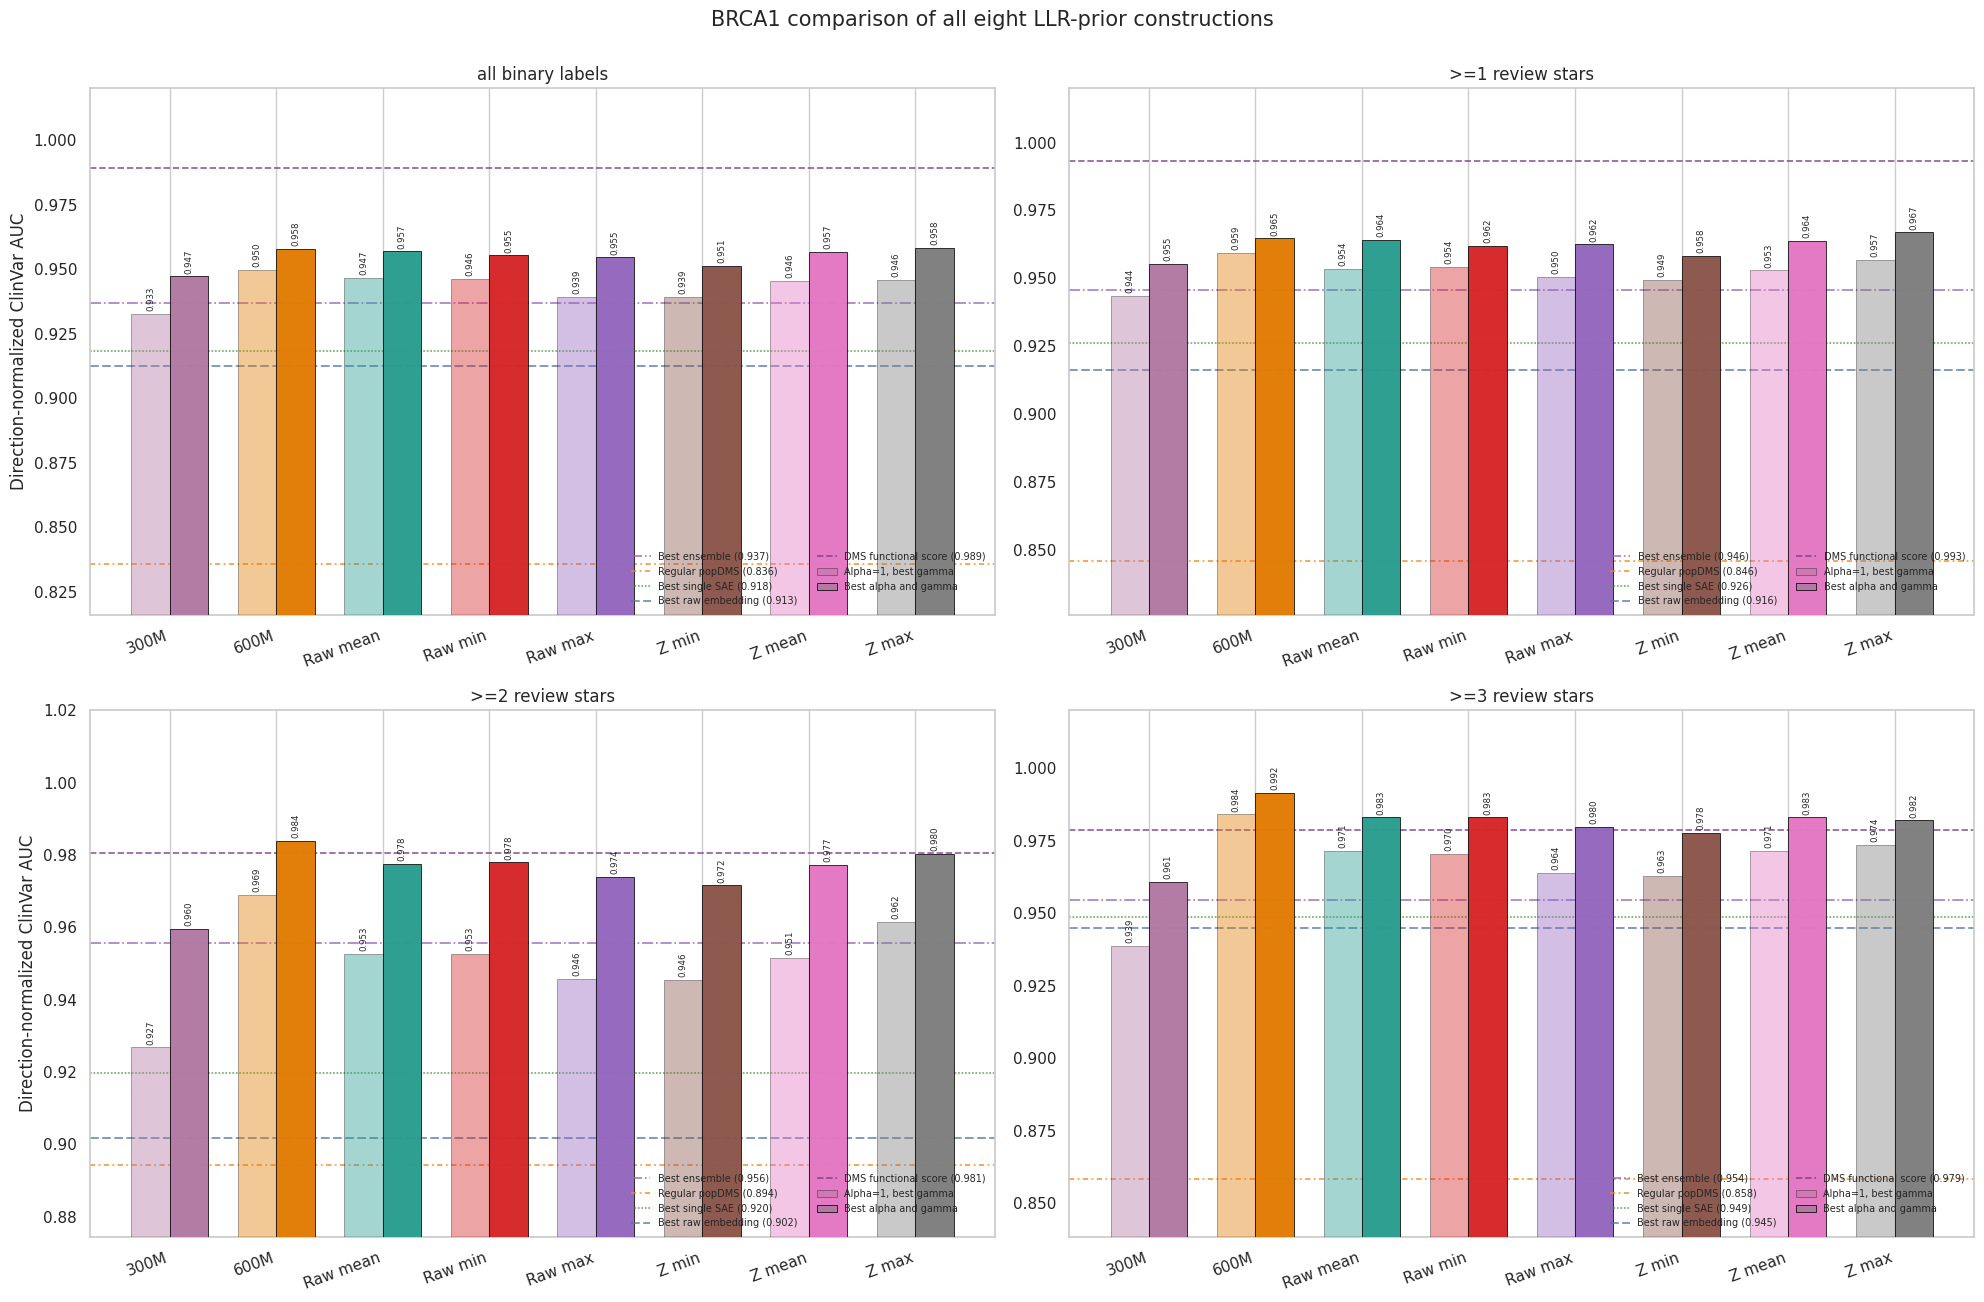

/net/dali/home/barton/dhw28/popDMS/esmDMS/data/clinprotgym_esmc_sae/datasets/MV_BRCA1_Findlay_2018/figures/brca1_sae_downstream/MV_BRCA1_Findlay_2018_all_eight_llr_priors_auc_comparison_pipeline.png


In [42]:
# Consolidated comparison of all eight LLR-prior constructions.
plt, sns = ensure_plotting()

ALL_EIGHT_PRIOR_ORDER = [
    "ESM-C 300M",
    "ESM-C 600M",
    MEAN_LLR_PRIOR_LABEL,
    "Raw min(300M, 600M)",
    "Raw max(300M, 600M)",
    "Z-score min(300M, 600M)",
    "Z-score mean(300M, 600M)",
    "Z-score max(300M, 600M)",
]
ALL_EIGHT_PRIOR_SHORT_LABELS = [
    "300M", "600M", "Raw mean", "Raw min", "Raw max",
    "Z min", "Z mean", "Z max",
]
all_eight_prior_auc_summary = pd.concat(
    [three_prior_auc_summary, engineered_prior_auc_summary], ignore_index=True
)
missing_priors = set(ALL_EIGHT_PRIOR_ORDER) - set(all_eight_prior_auc_summary["prior_model"])
if missing_priors:
    raise ValueError(f"Missing completed sweep summaries for: {sorted(missing_priors)}")

all_eight_colors = dict(zip(
    ALL_EIGHT_PRIOR_ORDER, sns.color_palette("tab10", len(ALL_EIGHT_PRIOR_ORDER))
))
all_eight_colors.update({
    "ESM-C 300M": "#B279A2",
    "ESM-C 600M": "#E17C05",
    MEAN_LLR_PRIOR_LABEL: "#2A9D8F",
})

fig, axes = plt.subplots(2, 2, figsize=(20.0, 13.0), sharey=False)
x = np.arange(len(ALL_EIGHT_PRIOR_ORDER))
width = 0.36
for ax, min_stars in zip(axes.ravel(), LLR_PRIOR_POPDMS_STAR_CUTOFFS):
    panel = (
        all_eight_prior_auc_summary[
            all_eight_prior_auc_summary["min_review_stars"].eq(min_stars)
        ].drop_duplicates("prior_model").set_index("prior_model").loc[ALL_EIGHT_PRIOR_ORDER]
    )
    colors = [all_eight_colors[name] for name in ALL_EIGHT_PRIOR_ORDER]
    raw_bars = ax.bar(
        x - width / 2, panel["raw_best_auc_discrimination"], width,
        color=colors, alpha=0.42, edgecolor="black", linewidth=0.55,
        label="Alpha=1, best gamma", zorder=3,
    )
    optimized_bars = ax.bar(
        x + width / 2, panel["optimized_auc_discrimination"], width,
        color=colors, alpha=0.98, edgecolor="black", linewidth=0.55,
        label="Best alpha and gamma", zorder=3,
    )
    plotted_values = (
        panel["raw_best_auc_discrimination"].to_list()
        + panel["optimized_auc_discrimination"].to_list()
    )
    for baseline in three_prior_auc_baselines(min_stars):
        ax.axhline(
            baseline["auc"], color=baseline["color"], linestyle=baseline["linestyle"],
            linewidth=1.25, alpha=0.82,
            label=f"{baseline['label']} ({baseline['auc']:.3f})", zorder=1,
        )
        plotted_values.append(baseline["auc"])
    ax.bar_label(raw_bars, fmt="%.3f", padding=2, fontsize=6.2, rotation=90)
    ax.bar_label(optimized_bars, fmt="%.3f", padding=2, fontsize=6.2, rotation=90)
    span = max(plotted_values) - min(plotted_values)
    padding = max(0.02, 0.10 * span)
    ax.set_ylim(
        max(0.45, min(plotted_values) - padding),
        min(1.02, max(plotted_values) + 2.2 * padding),
    )
    ax.set_xticks(x)
    ax.set_xticklabels(ALL_EIGHT_PRIOR_SHORT_LABELS, rotation=20, ha="right")
    cutoff_label = "all binary labels" if min_stars == 0 else f">={min_stars} review stars"
    ax.set_title(cutoff_label)
    ax.grid(False, axis="y")
    ax.legend(frameon=False, fontsize=7.0, ncol=2, loc="lower right")
for ax in axes[:, 0]:
    ax.set_ylabel("Direction-normalized ClinVar AUC")
fig.suptitle(
    "BRCA1 comparison of all eight LLR-prior constructions",
    y=1.0, fontsize=15,
)
fig.tight_layout()
all_eight_out = FIGURE_DIR / f"{DATASET}_all_eight_llr_priors_auc_comparison_{CLINICAL_LABEL_MODE}.png"
fig.savefig(all_eight_out, dpi=300, bbox_inches="tight")
plt.show()
print(all_eight_out)


Best ESM-C 600M model at stars>=0: alpha=0.00305395, gamma=0.0666085, AUC*=0.9577
/net/dali/home/barton/dhw28/popDMS/esmDMS/data/clinprotgym_esmc_sae/datasets/MV_BRCA1_Findlay_2018/tables/MV_BRCA1_Findlay_2018_best_auc_600M_llr_prior_popdms_fitness.csv


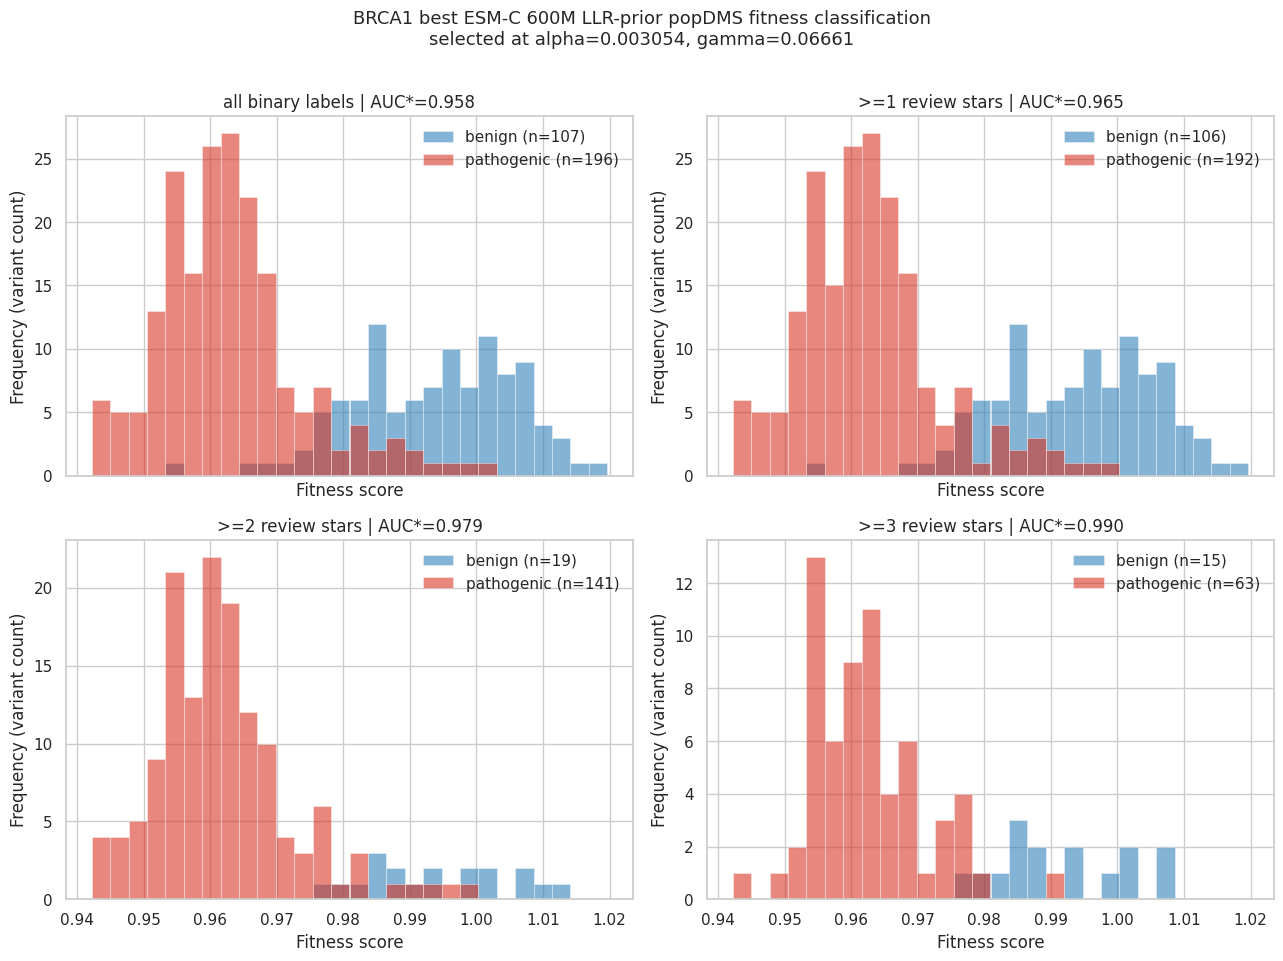

/net/dali/home/barton/dhw28/popDMS/esmDMS/data/clinprotgym_esmc_sae/datasets/MV_BRCA1_Findlay_2018/figures/brca1_sae_downstream/MV_BRCA1_Findlay_2018_best_600M_llr_prior_popdms_fitness_classification_pipeline.png


In [43]:
# Fitness-score classification distributions for the best ESM-C 600M alpha/gamma model.
plt, sns = ensure_plotting()
LLR_600M_CLASSIFICATION_SELECTION_STAR_CUTOFF = 0
LLR_600M_CLASSIFICATION_STAR_CUTOFFS = [0, 1, 2, 3]

selection_auc_column = (
    f"auc_discrimination_stars_{LLR_600M_CLASSIFICATION_SELECTION_STAR_CUTOFF}"
)
llr_600m_sweep = llr_alpha_gamma_sweep[
    llr_alpha_gamma_sweep["prior_model"].eq("ESM-C 600M")
].copy()
llr_600m_sweep[selection_auc_column] = safe_numeric(llr_600m_sweep[selection_auc_column])
best_600m_row = llr_600m_sweep.sort_values(
    [selection_auc_column, "alpha", "gamma"], ascending=[False, True, True]
).iloc[0]
best_600m_alpha = float(best_600m_row["alpha"])
best_600m_gamma = float(best_600m_row["gamma"])
print(
    f"Best ESM-C 600M model at stars>={LLR_600M_CLASSIFICATION_SELECTION_STAR_CUTOFF}: "
    f"alpha={best_600m_alpha:.6g}, gamma={best_600m_gamma:.6g}, "
    f"AUC*={best_600m_row[selection_auc_column]:.4f}"
)

# Reconstruct the joint-fit fitness vector using the same convention as the alpha/gamma sweep.
classification_state = load_dataset_state()
classification_sequences = classification_state["sequence_dataframe"].copy()
classification_metadata = classification_state["sequence_metadata"].copy()
classification_seq_to_feature, classification_feature_table = llr_prior_popdms_feature_index(
    classification_metadata
)
classification_payloads = [
    llr_prior_popdms_replicate_payload(
        replicate_df, classification_seq_to_feature, len(classification_feature_table)
    )
    for _, replicate_df in classification_sequences.groupby("Replicate")
    if replicate_df["Generation"].nunique() >= 2
]
if not classification_payloads:
    raise ValueError("No usable replicate trajectories are available for the 600M reconstruction.")
classification_joint_payload = {
    "diag": np.sum([payload["diag"] for payload in classification_payloads], axis=0),
    "weighted_means": [
        item for payload in classification_payloads for item in payload["weighted_means"]
    ],
    "dx": np.sum([payload["dx"] for payload in classification_payloads], axis=0),
}
classification_llr = pd.read_csv(
    LLR_PRIOR_POPDMS_MODELS["ESM-C 600M"], usecols=["SequenceIndex", "fitness"]
)
classification_llr["SequenceIndex"] = classification_llr["SequenceIndex"].astype(str)
classification_raw_prior = (
    classification_feature_table[["SequenceIndex"]]
    .merge(classification_llr, on="SequenceIndex", how="left")["fitness"]
    .to_numpy(dtype=float)
)
if not np.isfinite(classification_raw_prior).all():
    raise ValueError("The ESM-C 600M LLR prior is incomplete for the assayed mutation set.")
classification_selection = solve_llr_prior_popdms(
    classification_joint_payload,
    best_600m_gamma * len(classification_payloads),
    best_600m_alpha * classification_raw_prior,
)
best_600m_fitness = llr_prior_popdms_fitness(
    classification_feature_table, classification_selection
)
best_600m_fitness_path = TABLE_DIR / (
    f"{DATASET}_best_auc_600M_llr_prior_popdms_fitness.csv"
)
best_600m_fitness.to_csv(best_600m_fitness_path, index=False)
print(best_600m_fitness_path)

classification_panels = []
for min_stars in LLR_600M_CLASSIFICATION_STAR_CUTOFFS:
    panel = fitness_with_active_labels(best_600m_fitness_path, min_stars=min_stars)
    panel = normalize_label_columns(panel)
    panel["fitness"] = safe_numeric(panel["fitness"])
    panel = panel[
        panel["annotation"].isin(PATHOGENICITY_LABELS)
        & np.isfinite(panel["fitness"])
    ].copy()
    if panel.empty:
        continue
    classification_panels.append((min_stars, panel, auc_from_labeled_fitness(panel)))

if not classification_panels:
    print("No labeled variants overlap the best ESM-C 600M fitness table.")
else:
    all_classification_fitness = pd.concat(
        [panel for _, panel, _ in classification_panels], ignore_index=True
    )["fitness"].to_numpy(dtype=float)
    n_bins = min(30, max(8, int(np.sqrt(len(all_classification_fitness)))))
    classification_bins = np.histogram_bin_edges(all_classification_fitness, bins=n_bins)
    fig, axes = plt.subplots(2, 2, figsize=(13.0, 9.5), sharex=True, sharey=False)
    classification_palette = {"benign": "#2C7FB8", "pathogenic": "#D7301F"}
    for ax, (min_stars, panel, stats) in zip(axes.ravel(), classification_panels):
        for annotation in ["benign", "pathogenic"]:
            values = panel.loc[panel["annotation"].eq(annotation), "fitness"].to_numpy(dtype=float)
            ax.hist(
                values, bins=classification_bins, alpha=0.58,
                color=classification_palette[annotation], edgecolor="white", linewidth=0.45,
                label=f"{annotation} (n={len(values)})",
            )
        cutoff_label = "all binary labels" if min_stars == 0 else f">={min_stars} review stars"
        ax.set_title(f"{cutoff_label} | AUC*={stats['auc_discrimination']:.3f}")
        ax.set_xlabel("Fitness score")
        ax.set_ylabel("Frequency (variant count)")
        ax.legend(frameon=False)
    for ax in axes.ravel()[len(classification_panels):]:
        ax.axis("off")
    fig.suptitle(
        "BRCA1 best ESM-C 600M LLR-prior popDMS fitness classification\n"
        f"selected at alpha={best_600m_alpha:.4g}, gamma={best_600m_gamma:.4g}",
        y=1.01, fontsize=13,
    )
    fig.tight_layout()
    classification_out = FIGURE_DIR / (
        f"{DATASET}_best_600M_llr_prior_popdms_fitness_classification_{CLINICAL_LABEL_MODE}.png"
    )
    fig.savefig(classification_out, dpi=300, bbox_inches="tight")
    plt.show()
    print(classification_out)


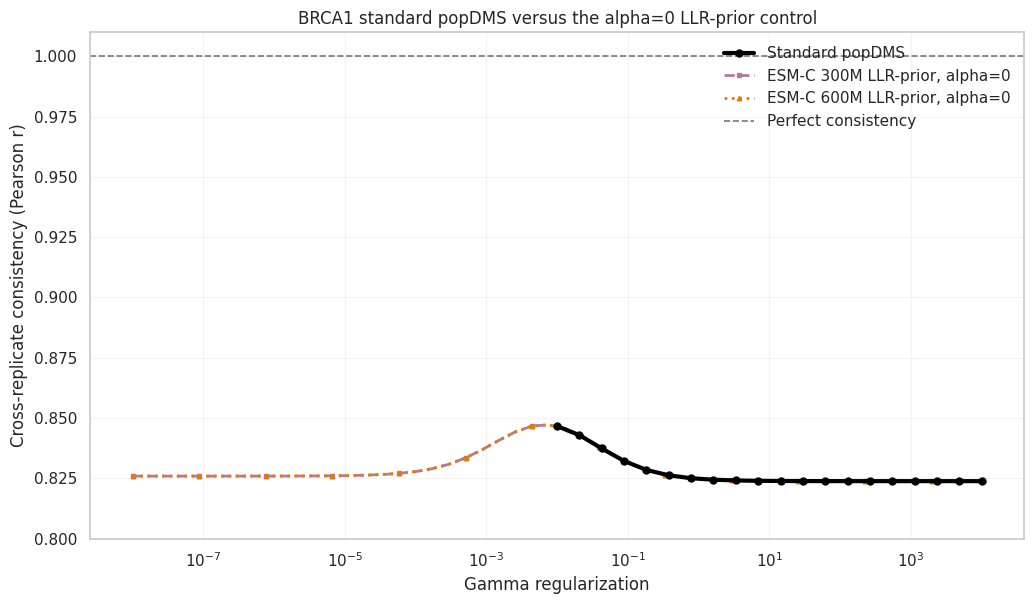

Standard diagnostics: /net/dali/home/barton/dhw28/popDMS/esmDMS/data/clinprotgym_esmc_sae/datasets/MV_BRCA1_Findlay_2018/jobs/benchmark_row_analysis/fitness/00002_MV_BRCA1_Findlay_2018_Regular_popDMS_substitution_selection_gamma_diagnostics.csv
/net/dali/home/barton/dhw28/popDMS/esmDMS/data/clinprotgym_esmc_sae/datasets/MV_BRCA1_Findlay_2018/figures/brca1_sae_downstream/MV_BRCA1_Findlay_2018_normal_popdms_vs_alpha0_llr_prior_consistency.png


,gamma,standard_popdms_consistency,alpha0_300M_consistency,alpha0_300M_minus_standard,alpha0_600M_consistency,alpha0_600M_minus_standard
0,0.010000,0.846628,0.846379,-2.490263e-04,0.846379,-2.490263e-04
1,0.020691,0.842885,0.842804,-8.074193e-05,0.842804,-8.074193e-05
2,0.042813,0.837365,0.837394,2.857963e-05,0.837394,2.857963e-05
3,0.088587,0.832174,0.832282,1.081912e-04,0.832282,1.081912e-04
4,0.183298,0.828461,0.828511,5.011056e-05,0.828511,5.011056e-05
5,0.379269,0.826233,0.826276,4.356379e-05,0.826276,4.356379e-05
6,0.784760,0.825027,0.825067,4.020477e-05,0.825067,4.020477e-05
7,1.623777,0.824410,0.824419,8.989946e-06,0.824419,8.989946e-06
8,3.359818,0.824103,0.824110,6.923528e-06,0.824110,6.923528e-06
9,6.951928,0.823953,0.823958,5.148941e-06,0.823958,5.148941e-06


In [44]:
# Compare the standard popDMS consistency sweep with the alpha=0 LLR-prior control.
plt, sns = ensure_plotting()

if "llr_alpha_gamma_sweep" not in globals():
    alpha_sweep_path = TABLE_DIR / f"{DATASET}_llr_prior_popdms_alpha_gamma_sweep.csv"
    llr_alpha_gamma_sweep = pd.read_csv(alpha_sweep_path)

regular_diagnostic_paths = sorted(
    (JOB_DIR / "benchmark_row_analysis" / "fitness").glob(
        "*Regular_popDMS*selection_gamma_diagnostics.csv"
    )
)
if not regular_diagnostic_paths:
    raise FileNotFoundError(
        "No standard popDMS gamma-diagnostics table was found. "
        "Run and collect the regular popDMS benchmark first."
    )
regular_diagnostics_path = regular_diagnostic_paths[-1]
regular_consistency = pd.read_csv(regular_diagnostics_path)
regular_consistency["gamma"] = safe_numeric(regular_consistency["gamma"])
regular_consistency["mean_pairwise_pearson_r"] = safe_numeric(
    regular_consistency["mean_pairwise_pearson_r"]
)

alpha_zero = llr_alpha_gamma_sweep[
    np.isclose(llr_alpha_gamma_sweep["alpha"], 0.0, rtol=0.0, atol=1e-15)
].copy()
if alpha_zero.empty:
    raise ValueError("The alpha/gamma sweep does not contain an alpha=0 control.")

fig, ax = plt.subplots(figsize=(10.5, 6.2))
ax.plot(
    regular_consistency["gamma"],
    regular_consistency["mean_pairwise_pearson_r"],
    color="black", linewidth=3.0, marker="o", markersize=5.0,
    label="Standard popDMS", zorder=5,
)
alpha_zero_styles = {
    "ESM-C 300M": ("#B279A2", "--", "s"),
    "ESM-C 600M": ("#E17C05", ":", "^"),
}
for prior_model, (color, linestyle, marker) in alpha_zero_styles.items():
    profile = alpha_zero[alpha_zero["prior_model"].eq(prior_model)].sort_values("gamma")
    ax.plot(
        profile["gamma"], profile["cross_replicate_consistency"],
        color=color, linestyle=linestyle, linewidth=2.0, marker=marker,
        markersize=3.2, markevery=4, label=f"{prior_model} LLR-prior, alpha=0",
        zorder=4,
    )

ax.axhline(1.0, color="#777777", linestyle="--", linewidth=1.2, label="Perfect consistency")
ax.set_xscale("log")
ax.set_ylim(0.80, 1.01)
ax.set_xlabel("Gamma regularization")
ax.set_ylabel("Cross-replicate consistency (Pearson r)")
ax.set_title("BRCA1 standard popDMS versus the alpha=0 LLR-prior control")
ax.grid(True, which="both", alpha=0.2)
ax.legend(frameon=False, loc="upper right")
fig.tight_layout()
normal_popdms_comparison_out = FIGURE_DIR / (
    f"{DATASET}_normal_popdms_vs_alpha0_llr_prior_consistency.png"
)
fig.savefig(normal_popdms_comparison_out, dpi=300, bbox_inches="tight")
plt.show()
print(f"Standard diagnostics: {regular_diagnostics_path}")
print(normal_popdms_comparison_out)

# Compare at the standard sweep's gamma values by log-gamma interpolation.
comparison = regular_consistency[["gamma", "mean_pairwise_pearson_r"]].rename(
    columns={"mean_pairwise_pearson_r": "standard_popdms_consistency"}
)
for prior_model in alpha_zero_styles:
    profile = alpha_zero[alpha_zero["prior_model"].eq(prior_model)].sort_values("gamma")
    interpolated = np.interp(
        np.log10(comparison["gamma"]), np.log10(profile["gamma"]),
        profile["cross_replicate_consistency"],
    )
    short_name = prior_model.replace("ESM-C ", "").replace(" ", "_")
    comparison[f"alpha0_{short_name}_consistency"] = interpolated
    comparison[f"alpha0_{short_name}_minus_standard"] = (
        interpolated - comparison["standard_popdms_consistency"]
    )
display(comparison)


## Selection-Coefficient Distributions And Mutational-Site Heatmaps

This comparison uses the standard popDMS coefficients at its consistency-selected gamma and the globally best singular ESM-C 300M/600M LLR-prior result selected by direction-normalized ClinVar AUC across the complete alpha-by-gamma sweep. Heatmaps use a shared, zero-centered color scale. Untested amino-acid/site combinations are pale cream, visually separate from both ends of the coefficient scale. The two discontinuous assayed coding regions (residues 1–101 and 1631–1855) are drawn separately.


Best singular LLR prior: ESM-C 600M, alpha=0.00305395, gamma=0.0666085, AUC*=0.9577
/net/dali/home/barton/dhw28/popDMS/esmDMS/data/clinprotgym_esmc_sae/datasets/MV_BRCA1_Findlay_2018/tables/MV_BRCA1_Findlay_2018_normal_vs_best_llr_prior_selection_coefficients.csv


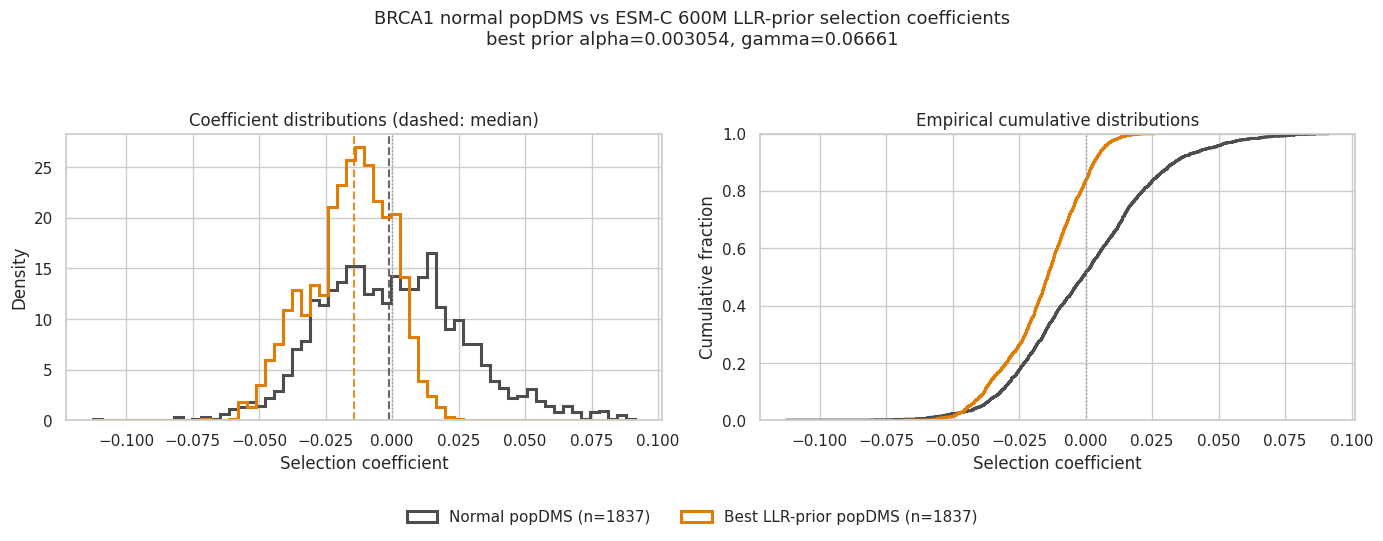

/net/dali/home/barton/dhw28/popDMS/esmDMS/data/clinprotgym_esmc_sae/datasets/MV_BRCA1_Findlay_2018/figures/brca1_sae_downstream/MV_BRCA1_Findlay_2018_normal_vs_best_llr_prior_selection_distributions.png


,method,n,mean,std,q05,median,q95,min,max
0,Normal popDMS,1837,4.834940e-19,0.026681,-0.038936,-0.001109,0.046526,-0.112400,0.091239
1,Best LLR-prior popDMS,1837,-1.580708e-02,0.015501,-0.043854,-0.014291,0.006785,-0.068331,0.026043


Assayed coding regions: [(np.int64(1), np.int64(101)), (np.int64(1631), np.int64(1855))]


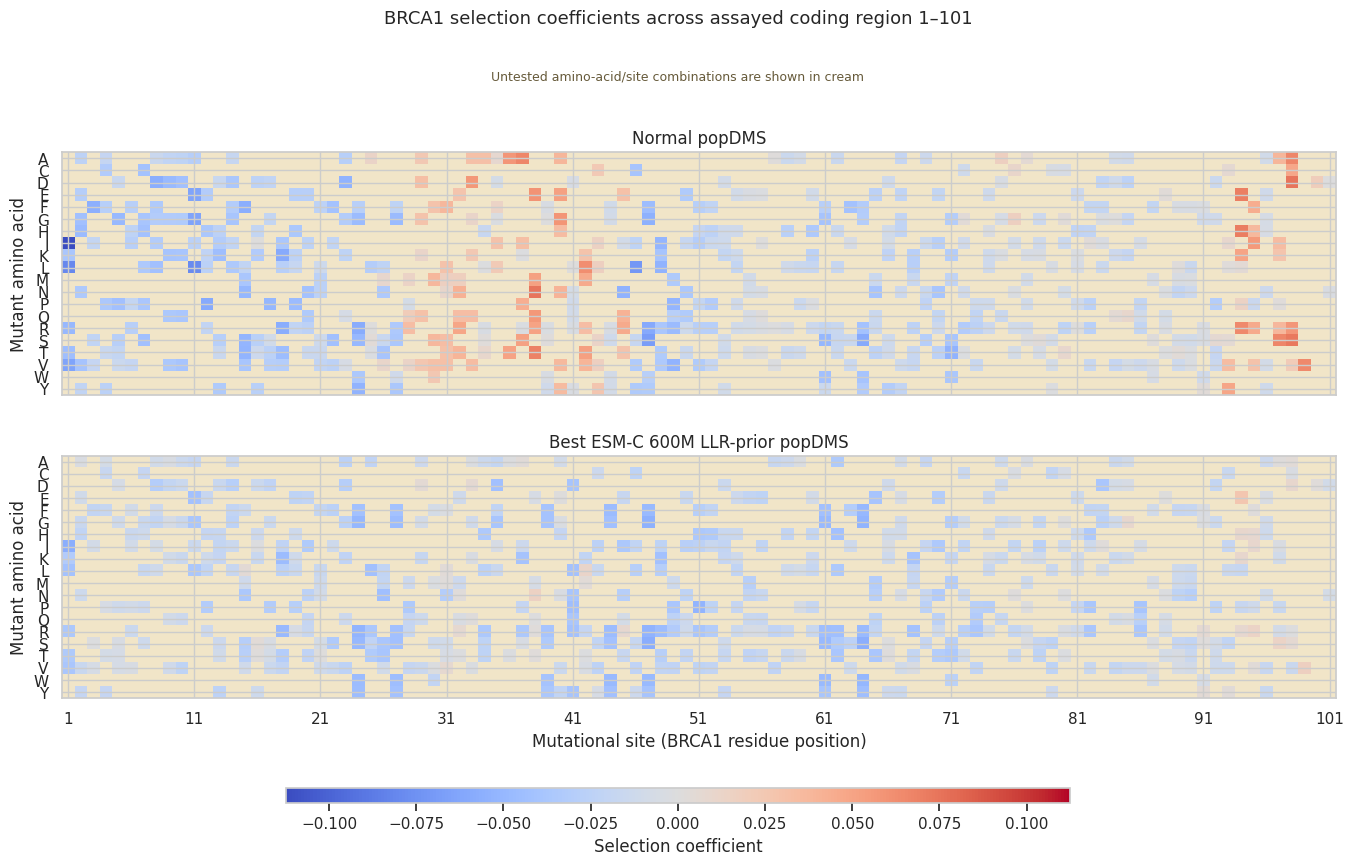

/net/dali/home/barton/dhw28/popDMS/esmDMS/data/clinprotgym_esmc_sae/datasets/MV_BRCA1_Findlay_2018/figures/brca1_sae_downstream/MV_BRCA1_Findlay_2018_normal_vs_best_llr_prior_selection_heatmap_1_101.png


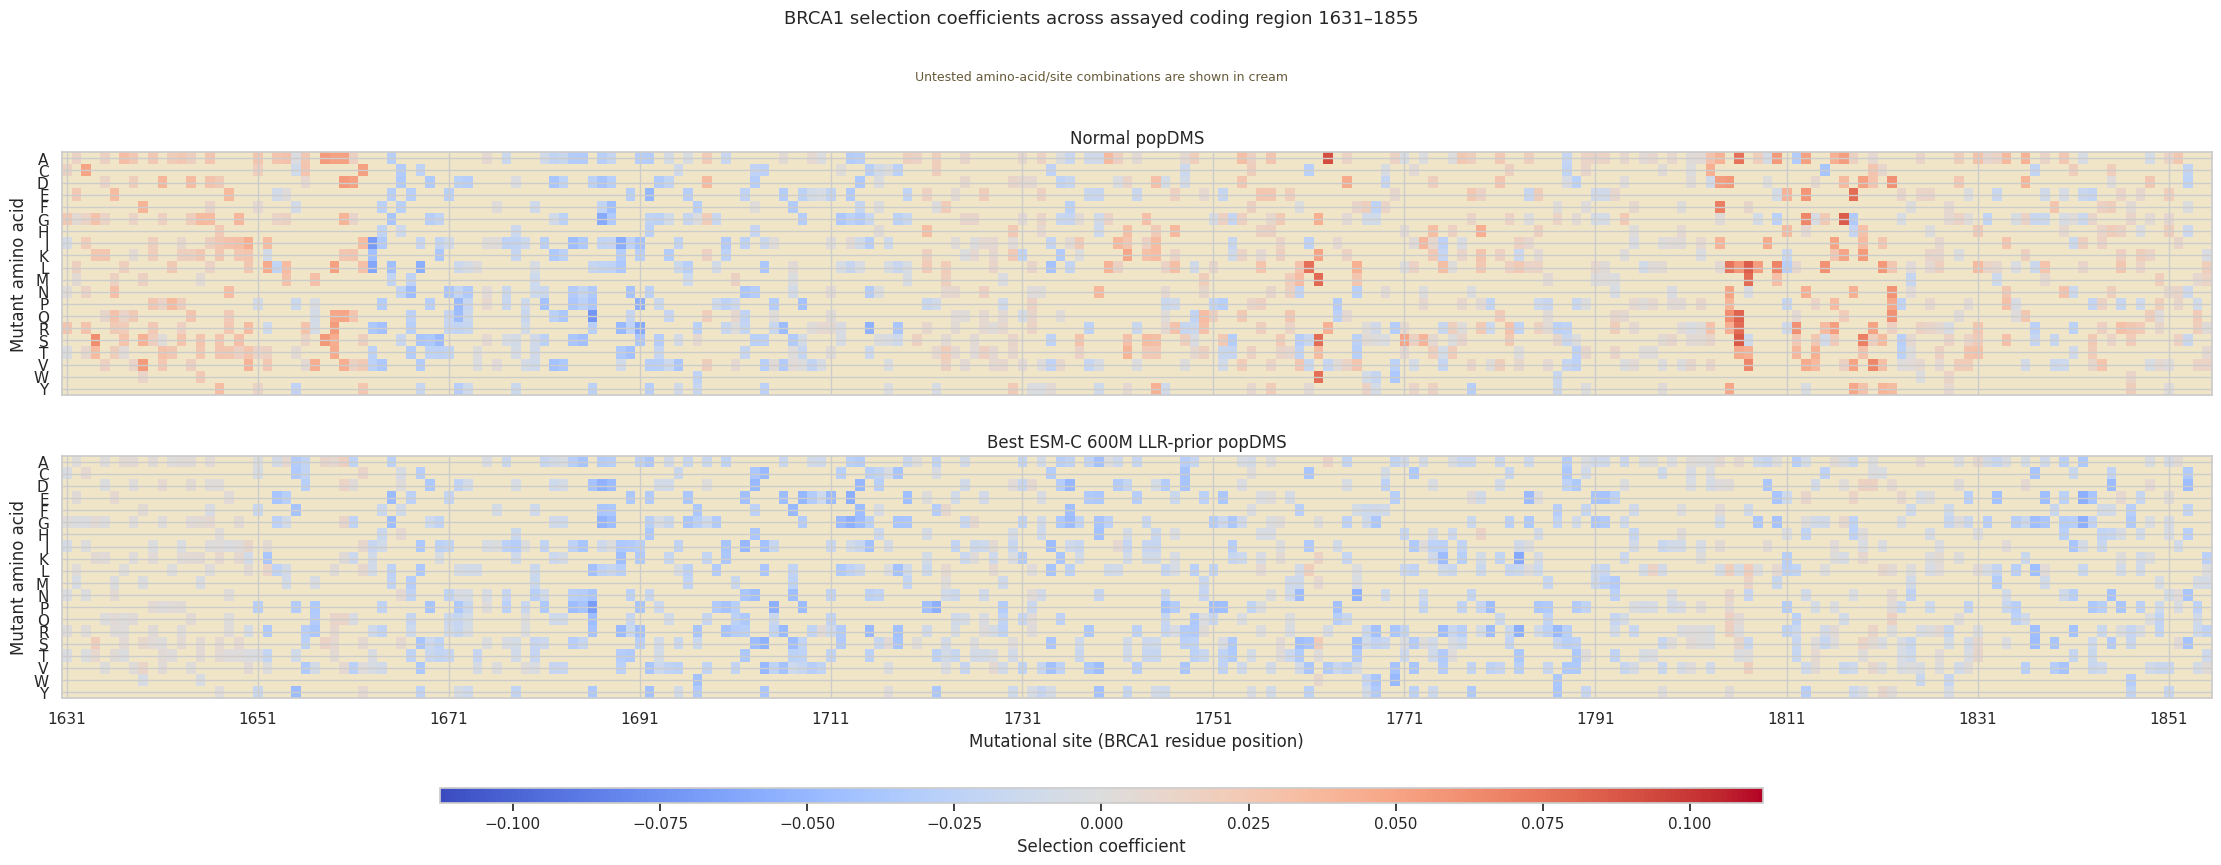

/net/dali/home/barton/dhw28/popDMS/esmDMS/data/clinprotgym_esmc_sae/datasets/MV_BRCA1_Findlay_2018/figures/brca1_sae_downstream/MV_BRCA1_Findlay_2018_normal_vs_best_llr_prior_selection_heatmap_1631_1855.png


In [48]:
# Compare normal popDMS with the best singular-model LLR-prior posterior.
plt, sns = ensure_plotting()
from matplotlib.colors import TwoSlopeNorm

SELECTION_COMPARISON_STAR_CUTOFF = 0
selection_auc_column = f"auc_discrimination_stars_{SELECTION_COMPARISON_STAR_CUTOFF}"
if "llr_alpha_gamma_sweep" not in globals():
    alpha_sweep_path = TABLE_DIR / f"{DATASET}_llr_prior_popdms_alpha_gamma_sweep.csv"
    llr_alpha_gamma_sweep = pd.read_csv(alpha_sweep_path)

best_llr_row = (
    llr_alpha_gamma_sweep.assign(
        **{selection_auc_column: safe_numeric(llr_alpha_gamma_sweep[selection_auc_column])}
    )
    .sort_values(
        [selection_auc_column, "alpha", "gamma"],
        ascending=[False, True, True],
    )
    .iloc[0]
)
best_llr_model = str(best_llr_row["prior_model"])
best_llr_alpha = float(best_llr_row["alpha"])
best_llr_gamma = float(best_llr_row["gamma"])
best_llr_auc = float(best_llr_row[selection_auc_column])
print(
    f"Best singular LLR prior: {best_llr_model}, alpha={best_llr_alpha:.6g}, "
    f"gamma={best_llr_gamma:.6g}, AUC*={best_llr_auc:.4f}"
)

# Reconstruct the best LLR-prior joint selection vector using the sweep convention.
selection_state = load_dataset_state()
selection_sequences = selection_state["sequence_dataframe"].copy()
selection_metadata = selection_state["sequence_metadata"].copy()
selection_seq_to_feature, selection_feature_table = llr_prior_popdms_feature_index(
    selection_metadata
)
selection_payloads = [
    llr_prior_popdms_replicate_payload(
        replicate_df, selection_seq_to_feature, len(selection_feature_table)
    )
    for _, replicate_df in selection_sequences.groupby("Replicate")
    if replicate_df["Generation"].nunique() >= 2
]
selection_joint_payload = {
    "diag": np.sum([payload["diag"] for payload in selection_payloads], axis=0),
    "weighted_means": [
        item for payload in selection_payloads for item in payload["weighted_means"]
    ],
    "dx": np.sum([payload["dx"] for payload in selection_payloads], axis=0),
}
best_llr_path = LLR_PRIOR_POPDMS_MODELS[best_llr_model]
best_llr_raw_prior = pd.read_csv(
    best_llr_path, usecols=["SequenceIndex", "fitness"]
)
best_llr_raw_prior["SequenceIndex"] = best_llr_raw_prior["SequenceIndex"].astype(str)
best_llr_prior_vector = (
    selection_feature_table[["SequenceIndex"]]
    .merge(best_llr_raw_prior, on="SequenceIndex", how="left")["fitness"]
    .to_numpy(dtype=float)
)
if not np.isfinite(best_llr_prior_vector).all():
    raise ValueError(f"{best_llr_model} has incomplete LLR coverage.")
best_llr_selection_vector = solve_llr_prior_popdms(
    selection_joint_payload,
    best_llr_gamma * len(selection_payloads),
    best_llr_alpha * best_llr_prior_vector,
)
best_llr_selection = selection_feature_table.copy()
best_llr_selection["llr_prior_selection_coefficient"] = best_llr_selection_vector

# Load the standard popDMS selection coefficients written by its benchmark task.
normal_selection_paths = sorted(
    (JOB_DIR / "benchmark_row_analysis" / "fitness").glob(
        "*Regular_popDMS*selection.csv"
    )
)
if not normal_selection_paths:
    raise FileNotFoundError("No standard popDMS selection-coefficient table was found.")
normal_selection_path = normal_selection_paths[-1]
normal_selection = pd.read_csv(normal_selection_path)
normal_parsed = normal_selection["feature"].astype(str).str.extract(
    r"^(?P<position>\d+):(?P<mutant_aa>[A-Z])$"
)
normal_selection = pd.concat([normal_selection, normal_parsed], axis=1)
normal_selection["position"] = safe_numeric(normal_selection["position"]).astype("Int64")
normal_selection["normal_popdms_selection_coefficient"] = safe_numeric(
    normal_selection["selection_coefficient"]
)

best_parsed = best_llr_selection["feature"].astype(str).str.extract(
    r"^(?P<position>\d+):(?P<mutant_aa>[A-Z])$"
)
best_llr_selection = pd.concat([best_llr_selection, best_parsed], axis=1)
best_llr_selection["position"] = safe_numeric(best_llr_selection["position"]).astype("Int64")

selection_comparison = normal_selection[[
    "position", "mutant_aa", "normal_popdms_selection_coefficient"
]].merge(
    best_llr_selection[[
        "position", "mutant_aa", "llr_prior_selection_coefficient"
    ]],
    on=["position", "mutant_aa"], how="outer", validate="one_to_one",
)
selection_comparison_path = TABLE_DIR / (
    f"{DATASET}_normal_vs_best_llr_prior_selection_coefficients.csv"
)
selection_comparison.to_csv(selection_comparison_path, index=False)
print(selection_comparison_path)

# Distribution comparison: density histogram and ECDF on shared coefficient values.
normal_values = selection_comparison["normal_popdms_selection_coefficient"].dropna().to_numpy(float)
llr_values = selection_comparison["llr_prior_selection_coefficient"].dropna().to_numpy(float)
combined_values = np.concatenate([normal_values, llr_values])
distribution_bins = np.histogram_bin_edges(combined_values, bins=60)
selection_colors = {"Normal popDMS": "#4D4D4D", "Best LLR-prior popDMS": "#E17C05"}
fig, axes = plt.subplots(1, 2, figsize=(14.0, 5.4))
for label, values in [("Normal popDMS", normal_values), ("Best LLR-prior popDMS", llr_values)]:
    axes[0].hist(
        values, bins=distribution_bins, density=True, histtype="step", linewidth=2.2,
        color=selection_colors[label], label=f"{label} (n={len(values)})",
    )
    axes[0].axvline(np.median(values), color=selection_colors[label], linestyle="--", alpha=0.85)
    sns.ecdfplot(x=values, ax=axes[1], color=selection_colors[label], linewidth=2.2, label=label)
axes[0].set_xlabel("Selection coefficient")
axes[0].set_ylabel("Density")
axes[0].set_title("Coefficient distributions (dashed: median)")
axes[1].set_xlabel("Selection coefficient")
axes[1].set_ylabel("Cumulative fraction")
axes[1].set_title("Empirical cumulative distributions")
for ax in axes:
    ax.axvline(0.0, color="#999999", linewidth=1.0, linestyle=":")
fig.suptitle(
    f"BRCA1 normal popDMS vs {best_llr_model} LLR-prior selection coefficients\n"
    f"best prior alpha={best_llr_alpha:.4g}, gamma={best_llr_gamma:.4g}",
    y=0.99, fontsize=13,
)
distribution_handles, distribution_labels = axes[0].get_legend_handles_labels()
fig.legend(
    distribution_handles, distribution_labels, frameon=False, ncol=2,
    loc="lower center", bbox_to_anchor=(0.5, 0.01),
)
fig.tight_layout(rect=(0.0, 0.10, 1.0, 0.94))
selection_distribution_out = FIGURE_DIR / (
    f"{DATASET}_normal_vs_best_llr_prior_selection_distributions.png"
)
fig.savefig(selection_distribution_out, dpi=300, bbox_inches="tight")
plt.show()
print(selection_distribution_out)

selection_distribution_summary = pd.DataFrame([
    {"method": label, "n": len(values), "mean": np.mean(values), "std": np.std(values, ddof=1),
     "q05": np.quantile(values, 0.05), "median": np.median(values), "q95": np.quantile(values, 0.95),
     "min": np.min(values), "max": np.max(values)}
    for label, values in [("Normal popDMS", normal_values), ("Best LLR-prior popDMS", llr_values)]
])
display(selection_distribution_summary)

# Detect contiguous assayed coding regions and draw each one separately.
tested_positions = sorted(selection_comparison["position"].dropna().astype(int).unique())
assayed_regions = []
region_start = region_end = tested_positions[0]
for position in tested_positions[1:]:
    if position != region_end + 1:
        assayed_regions.append((region_start, region_end))
        region_start = position
    region_end = position
assayed_regions.append((region_start, region_end))
print(f"Assayed coding regions: {assayed_regions}")

amino_acids = list("ACDEFGHIKLMNPQRSTVWY")
finite_coefficients = np.concatenate([
    normal_values[np.isfinite(normal_values)], llr_values[np.isfinite(llr_values)]
])
coefficient_limit = float(np.max(np.abs(finite_coefficients)))
coefficient_norm = TwoSlopeNorm(vmin=-coefficient_limit, vcenter=0.0, vmax=coefficient_limit)
coefficient_cmap = plt.get_cmap("coolwarm").copy()
untested_color = "#F1E5C8"
coefficient_cmap.set_bad(untested_color)
heatmap_specs = [
    ("normal_popdms_selection_coefficient", "Normal popDMS"),
    ("llr_prior_selection_coefficient", f"Best {best_llr_model} LLR-prior popDMS"),
]
selection_heatmap_paths = []
for region_start, region_end in assayed_regions:
    positions = list(range(region_start, region_end + 1))
    fig, axes = plt.subplots(2, 1, figsize=(max(14.0, len(positions) * 0.105), 8.4), sharex=True)
    image = None
    for ax, (coefficient_column, method_label) in zip(axes, heatmap_specs):
        region = selection_comparison[selection_comparison["position"].between(region_start, region_end)].copy()
        matrix = (
            region.pivot(index="mutant_aa", columns="position", values=coefficient_column)
            .reindex(index=amino_acids, columns=positions)
            .to_numpy(dtype=float)
        )
        image = ax.imshow(
            np.ma.masked_invalid(matrix), aspect="auto", interpolation="none",
            cmap=coefficient_cmap, norm=coefficient_norm, origin="upper",
        )
        ax.set_yticks(np.arange(len(amino_acids)), amino_acids)
        ax.set_ylabel("Mutant amino acid")
        ax.set_title(method_label)
    tick_step = 10 if len(positions) <= 120 else 20
    tick_indices = np.arange(0, len(positions), tick_step)
    axes[-1].set_xticks(tick_indices, [positions[index] for index in tick_indices], rotation=0)
    axes[-1].set_xlabel("Mutational site (BRCA1 residue position)")
    colorbar_axis = fig.add_axes([0.22, 0.045, 0.56, 0.018])
    colorbar = fig.colorbar(image, cax=colorbar_axis, orientation="horizontal")
    colorbar.set_label("Selection coefficient")
    fig.text(
        0.5, 0.91, "Untested amino-acid/site combinations are shown in cream",
        ha="center", va="center", fontsize=9, color="#665A3A",
    )
    fig.suptitle(
        f"BRCA1 selection coefficients across assayed coding region {region_start}–{region_end}",
        y=0.99, fontsize=13,
    )
    fig.subplots_adjust(left=0.06, right=0.97, bottom=0.17, top=0.82, hspace=0.25)
    heatmap_out = FIGURE_DIR / (
        f"{DATASET}_normal_vs_best_llr_prior_selection_heatmap_{region_start}_{region_end}.png"
    )
    fig.savefig(heatmap_out, dpi=300, bbox_inches="tight")
    plt.show()
    selection_heatmap_paths.append(heatmap_out)
    print(heatmap_out)


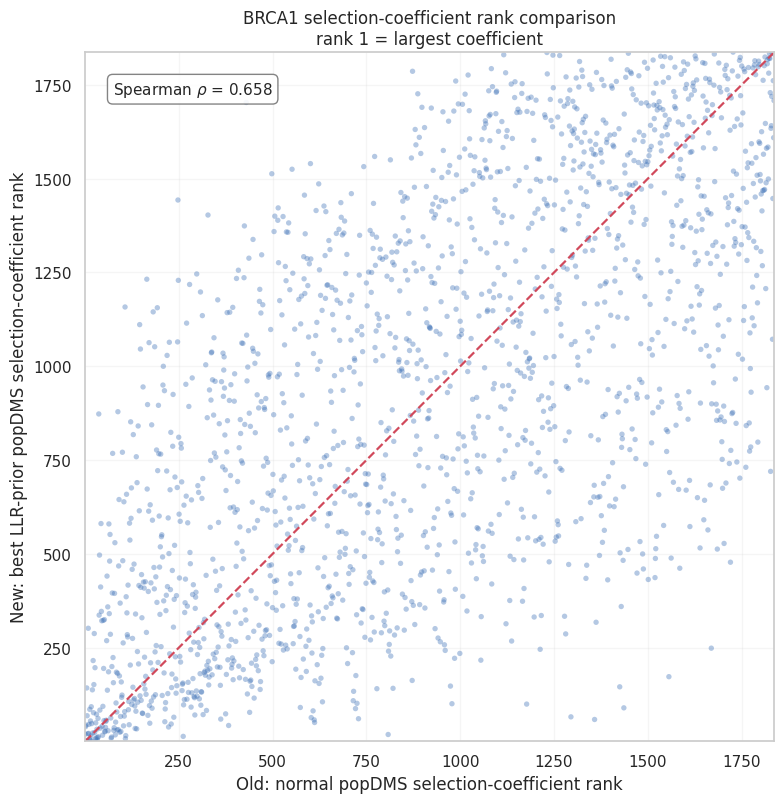

/net/dali/home/barton/dhw28/popDMS/esmDMS/data/clinprotgym_esmc_sae/datasets/MV_BRCA1_Findlay_2018/figures/brca1_sae_downstream/MV_BRCA1_Findlay_2018_normal_vs_best_llr_prior_selection_rank_comparison.png
/net/dali/home/barton/dhw28/popDMS/esmDMS/data/clinprotgym_esmc_sae/datasets/MV_BRCA1_Findlay_2018/tables/MV_BRCA1_Findlay_2018_normal_vs_best_llr_prior_selection_ranks.csv


In [50]:
# Rank-only comparison: old normal popDMS on x, new best LLR-prior popDMS on y.
plt, sns = ensure_plotting()

if "selection_comparison" not in globals():
    selection_comparison_path = TABLE_DIR / (
        f"{DATASET}_normal_vs_best_llr_prior_selection_coefficients.csv"
    )
    if not selection_comparison_path.is_file():
        raise FileNotFoundError(
            "Run the preceding selection-coefficient comparison cell first."
        )
    selection_comparison = pd.read_csv(selection_comparison_path)

selection_ranks = selection_comparison[[
    "position", "mutant_aa",
    "normal_popdms_selection_coefficient",
    "llr_prior_selection_coefficient",
]].dropna().copy()
# Rank 1 is the largest selection coefficient; average ranks handle any exact ties.
selection_ranks["normal_popdms_rank"] = selection_ranks[
    "normal_popdms_selection_coefficient"
].rank(method="average", ascending=False)
selection_ranks["llr_prior_rank"] = selection_ranks[
    "llr_prior_selection_coefficient"
].rank(method="average", ascending=False)
rank_spearman_rho = float(spearmanr(
    selection_ranks["normal_popdms_rank"],
    selection_ranks["llr_prior_rank"],
).statistic)

rank_count = len(selection_ranks)
fig, ax = plt.subplots(figsize=(8.2, 8.2))
ax.scatter(
    selection_ranks["normal_popdms_rank"],
    selection_ranks["llr_prior_rank"],
    s=15, alpha=0.38, color="#3B6FB6", edgecolor="none", rasterized=True,
)
ax.plot([1, rank_count], [1, rank_count], color="#D1495B", linestyle="--", linewidth=1.6)
ax.set_xlim(1, rank_count)
ax.set_ylim(1, rank_count)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("Old: normal popDMS selection-coefficient rank")
ax.set_ylabel("New: best LLR-prior popDMS selection-coefficient rank")
ax.set_title("BRCA1 selection-coefficient rank comparison\nrank 1 = largest coefficient")
ax.text(
    0.04, 0.96, rf"Spearman $\rho$ = {rank_spearman_rho:.3f}",
    transform=ax.transAxes, ha="left", va="top", fontsize=11,
    bbox={"boxstyle": "round,pad=0.35", "facecolor": "white", "edgecolor": "#777777", "alpha": 0.9},
)
ax.grid(True, alpha=0.18)
fig.tight_layout()
selection_rank_out = FIGURE_DIR / (
    f"{DATASET}_normal_vs_best_llr_prior_selection_rank_comparison.png"
)
fig.savefig(selection_rank_out, dpi=300, bbox_inches="tight")
plt.show()
print(selection_rank_out)

selection_rank_table_path = TABLE_DIR / (
    f"{DATASET}_normal_vs_best_llr_prior_selection_ranks.csv"
)
selection_ranks[[
    "position", "mutant_aa", "normal_popdms_rank", "llr_prior_rank"
]].to_csv(selection_rank_table_path, index=False)
print(selection_rank_table_path)
